In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline  


In [2]:
df = pd.read_csv('NCD_RisC_Lancet_2016_BP_age_standardised_countries.csv')

In [3]:
df.head(15)

,Country/Region/World,ISO,Sex,Year,Mean systolic blood pressure (mmHg),Mean systolic blood pressure lower 95% uncertainty interval (mmHg),Mean systolic blood pressure upper 95% uncertainty interval (mmHg),Mean diastolic blood pressure (mmHg),Mean diastolic blood pressure lower 95% uncertainty interval (mmHg),Mean diastolic blood pressure upper 95% uncertainty interval (mmHg),Prevalence of raised blood pressure,Prevalence of raised blood pressure lower 95% uncertainty interval,Prevalence of raised blood pressure upper 95% uncertainty interval
0,Afghanistan,AFG,Men,1975,121.078635,110.560019,131.280612,76.217903,69.432058,82.910254,0.251041,0.139465,0.389490
1,Afghanistan,AFG,Men,1976,121.213135,111.237480,130.972393,76.302382,69.841522,82.712827,0.252482,0.145232,0.385497
2,Afghanistan,AFG,Men,1977,121.352221,111.913929,130.796611,76.389730,70.243390,82.518096,0.254044,0.150297,0.380740
3,Afghanistan,AFG,Men,1978,121.493430,112.391051,130.595529,76.479429,70.680791,82.339212,0.255709,0.155271,0.376442
4,Afghanistan,AFG,Men,1979,121.636602,112.922056,130.367636,76.570570,70.991105,82.190582,0.257459,0.160139,0.372394
5,Afghanistan,AFG,Men,1980,121.779978,113.210227,130.192427,76.662263,71.161397,82.116525,0.259259,0.165976,0.370139
6,Afghanistan,AFG,Men,1981,121.924842,113.644684,130.108549,76.753616,71.390596,82.029064,0.261067,0.170775,0.367569
7,Afghanistan,AFG,Men,1982,122.073346,113.918442,130.066324,76.846447,71.554908,81.950016,0.262912,0.174699,0.364517
8,Afghanistan,AFG,Men,1983,122.224822,114.322121,130.152197,76.939638,71.770334,81.920172,0.264802,0.178516,0.363599
9,Afghanistan,AFG,Men,1984,122.376956,114.549692,130.312049,77.032372,71.954991,81.872425,0.266719,0.181058,0.362819


In [4]:
df.isna().sum()

Country/Region/World                                                   0
ISO                                                                    0
Sex                                                                    0
Year                                                                   0
Mean systolic blood pressure (mmHg)                                    0
Mean systolic blood pressure lower 95% uncertainty interval (mmHg)     0
Mean systolic blood pressure upper 95% uncertainty interval (mmHg)     0
Mean diastolic blood pressure (mmHg)                                   0
Mean diastolic blood pressure lower 95% uncertainty interval (mmHg)    0
Mean diastolic blood pressure upper 95% uncertainty interval (mmHg)    0
Prevalence of raised blood pressure                                    0
Prevalence of raised blood pressure lower 95% uncertainty interval     0
Prevalence of raised blood pressure upper 95% uncertainty interval     0
dtype: int64

In [5]:
columns_to_drop = ['ISO', 'Mean systolic blood pressure lower 95% uncertainty interval (mmHg)',
                   'Mean systolic blood pressure upper 95% uncertainty interval (mmHg)',
                   'Mean diastolic blood pressure lower 95% uncertainty interval (mmHg)',
                   'Mean diastolic blood pressure upper 95% uncertainty interval (mmHg)',
                   'Prevalence of raised blood pressure lower 95% uncertainty interval',
                   'Prevalence of raised blood pressure upper 95% uncertainty interval'
    
]

In [7]:
df.drop(columns=columns_to_drop, inplace=True)

In [8]:
df.head(20)

,Country/Region/World,Sex,Year,Mean systolic blood pressure (mmHg),Mean diastolic blood pressure (mmHg),Prevalence of raised blood pressure
0,Afghanistan,Men,1975,121.078635,76.217903,0.251041
1,Afghanistan,Men,1976,121.213135,76.302382,0.252482
2,Afghanistan,Men,1977,121.352221,76.389730,0.254044
3,Afghanistan,Men,1978,121.493430,76.479429,0.255709
4,Afghanistan,Men,1979,121.636602,76.570570,0.257459
5,Afghanistan,Men,1980,121.779978,76.662263,0.259259
6,Afghanistan,Men,1981,121.924842,76.753616,0.261067
7,Afghanistan,Men,1982,122.073346,76.846447,0.262912
8,Afghanistan,Men,1983,122.224822,76.939638,0.264802
9,Afghanistan,Men,1984,122.376956,77.032372,0.266719


In [12]:
df = df.rename(columns={'Mean systolic blood pressure (mmHg)': 'systolic', 'Mean diastolic blood pressure (mmHg)': 'diastolic'})

In [14]:
df.head()

,Country/Region/World,Sex,Year,systolic,diastolic,Prevalence of raised blood pressure
0,Afghanistan,Men,1975,121.078635,76.217903,0.251041
1,Afghanistan,Men,1976,121.213135,76.302382,0.252482
2,Afghanistan,Men,1977,121.352221,76.389730,0.254044
3,Afghanistan,Men,1978,121.493430,76.479429,0.255709
4,Afghanistan,Men,1979,121.636602,76.570570,0.257459


In [27]:
numeric_countries = df.select_dtypes(include='number').columns
country_averages = df.groupby('Country/Region/World')[numeric_countries].mean()

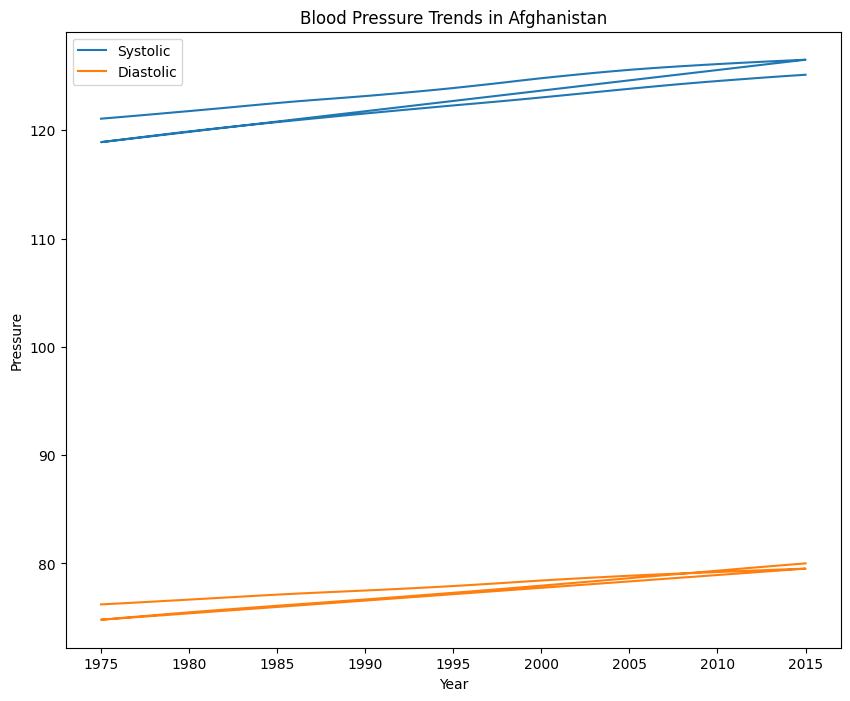

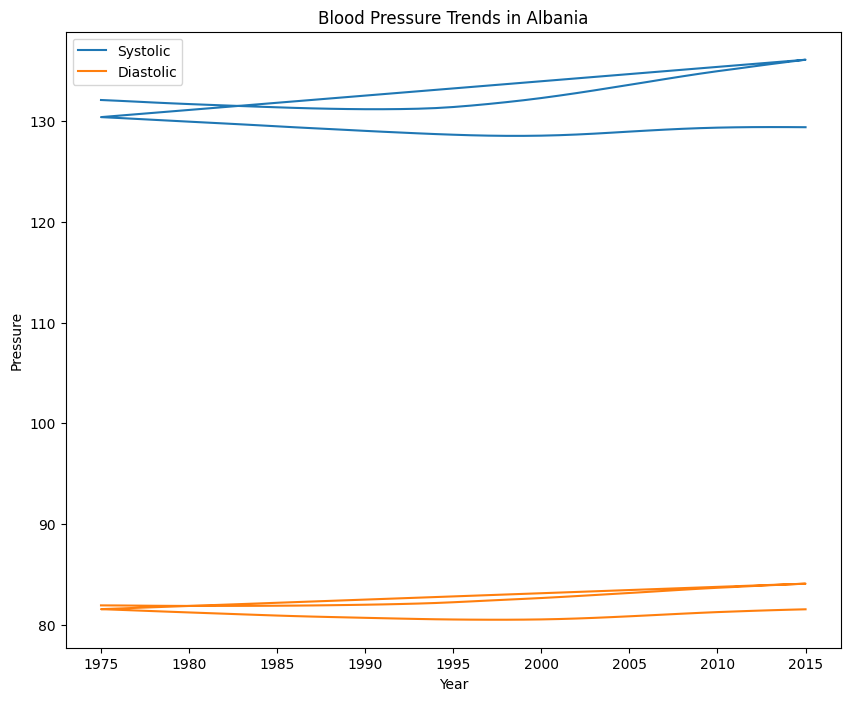

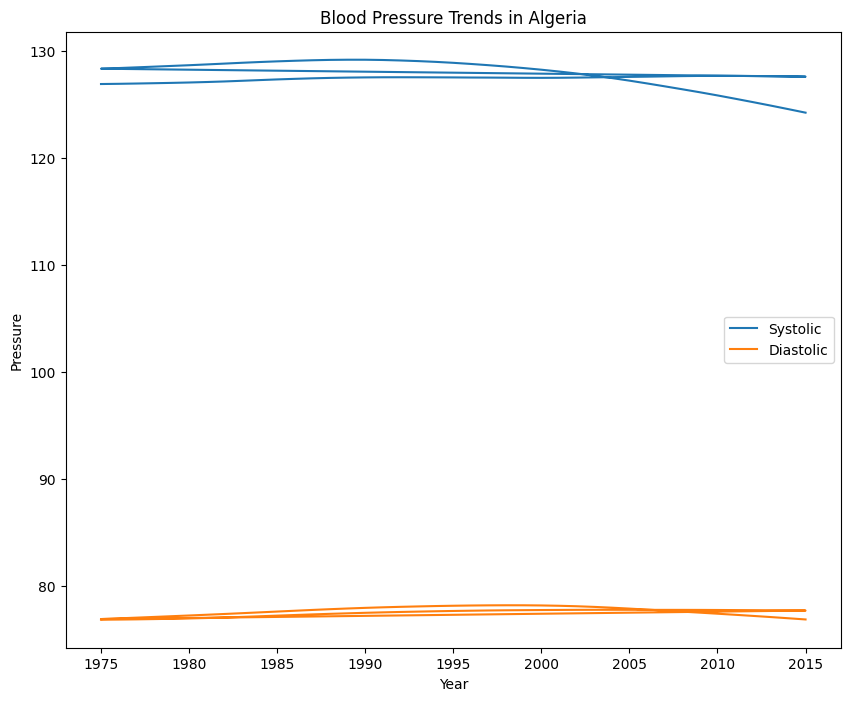

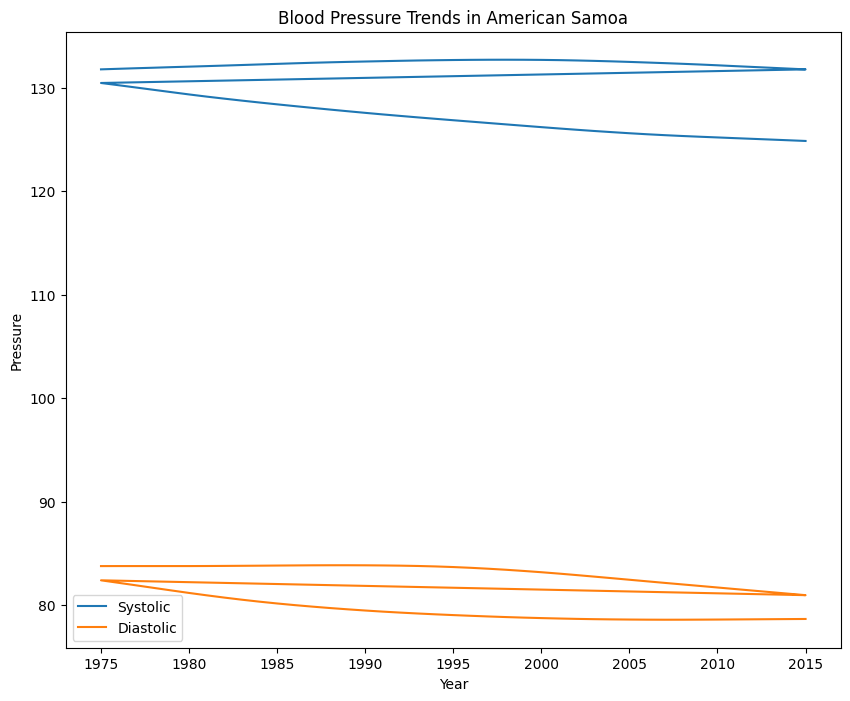

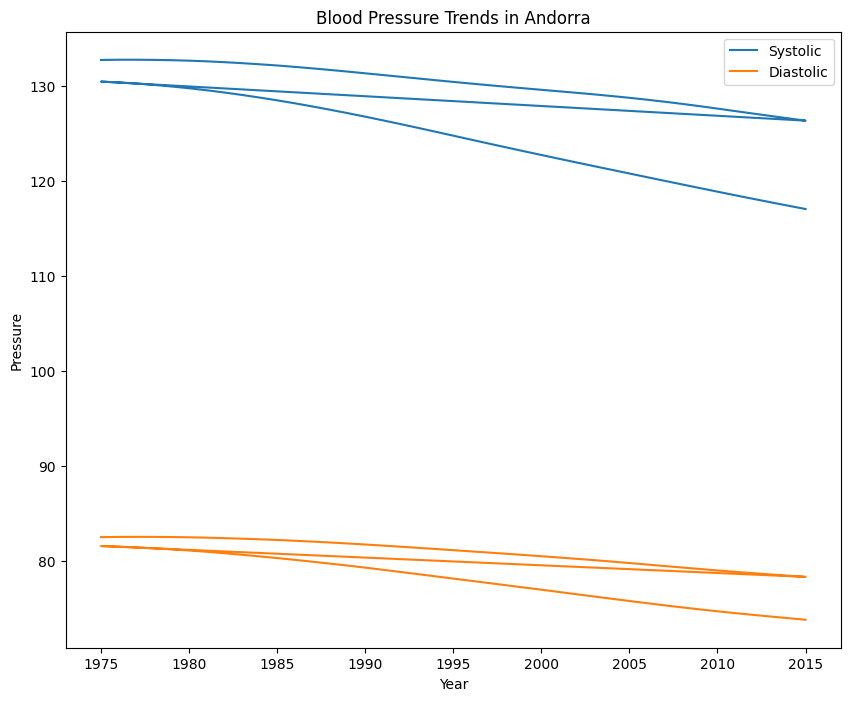

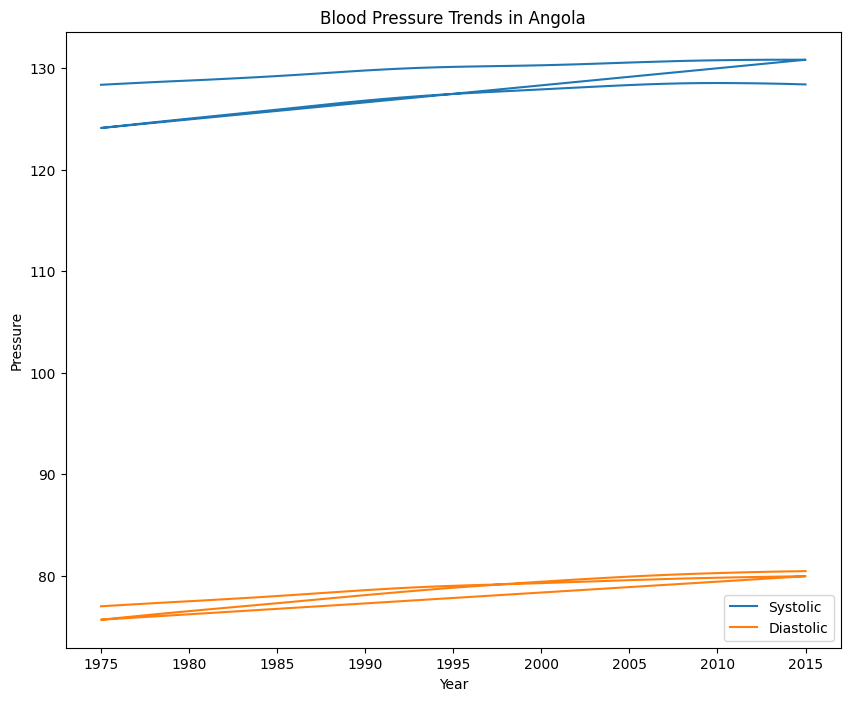

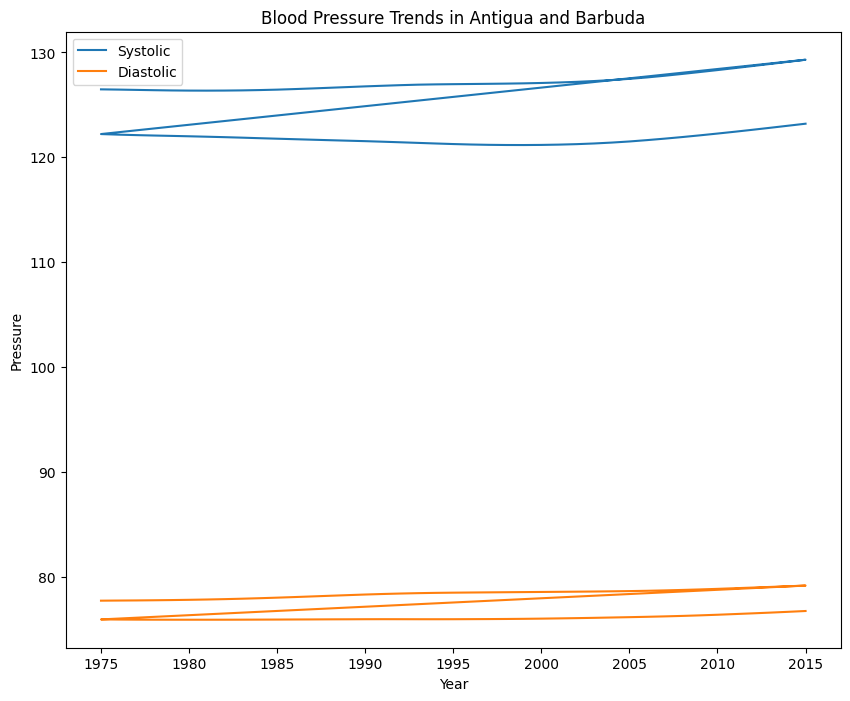

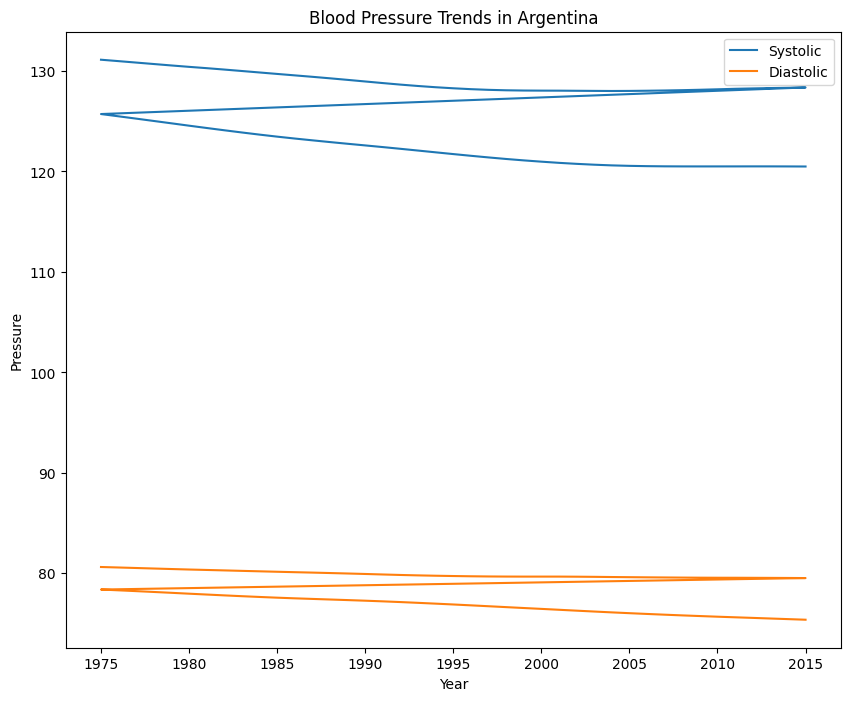

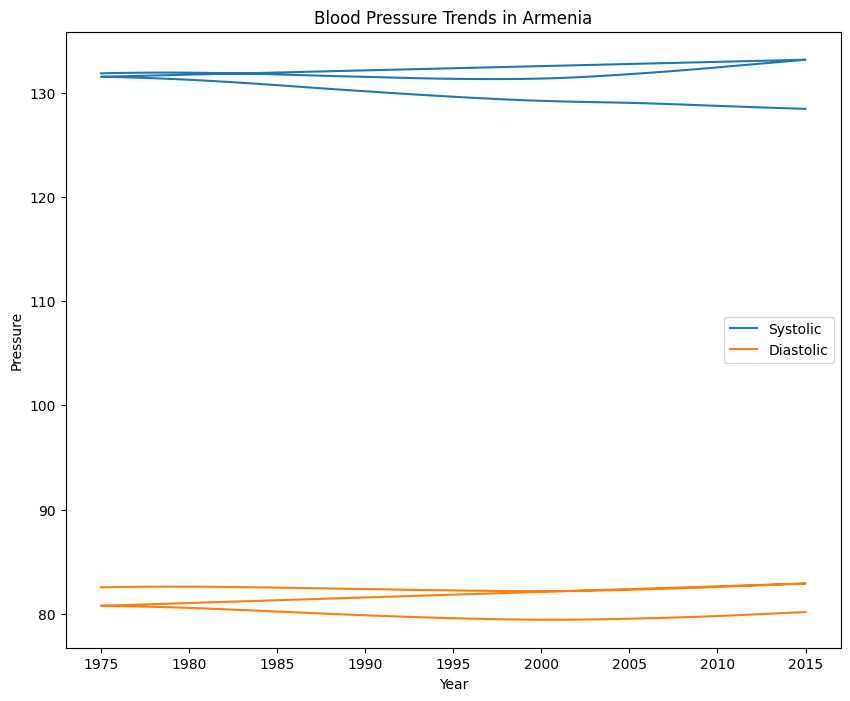

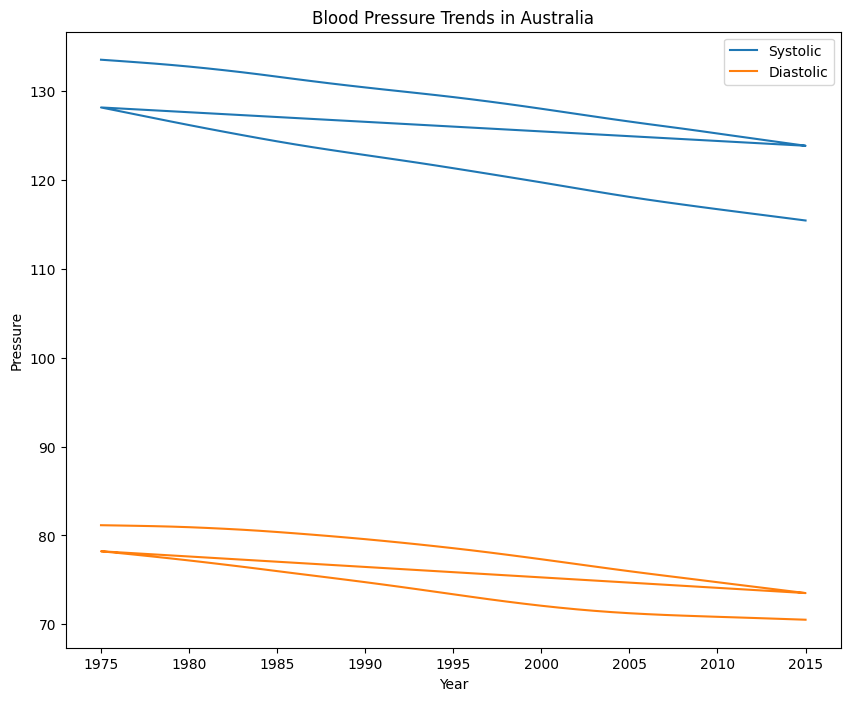

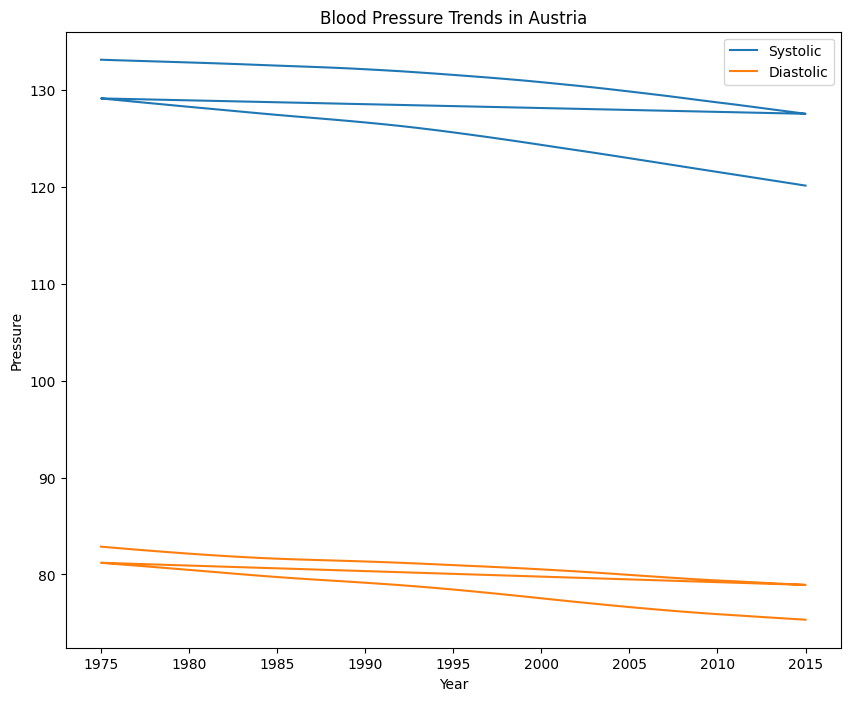

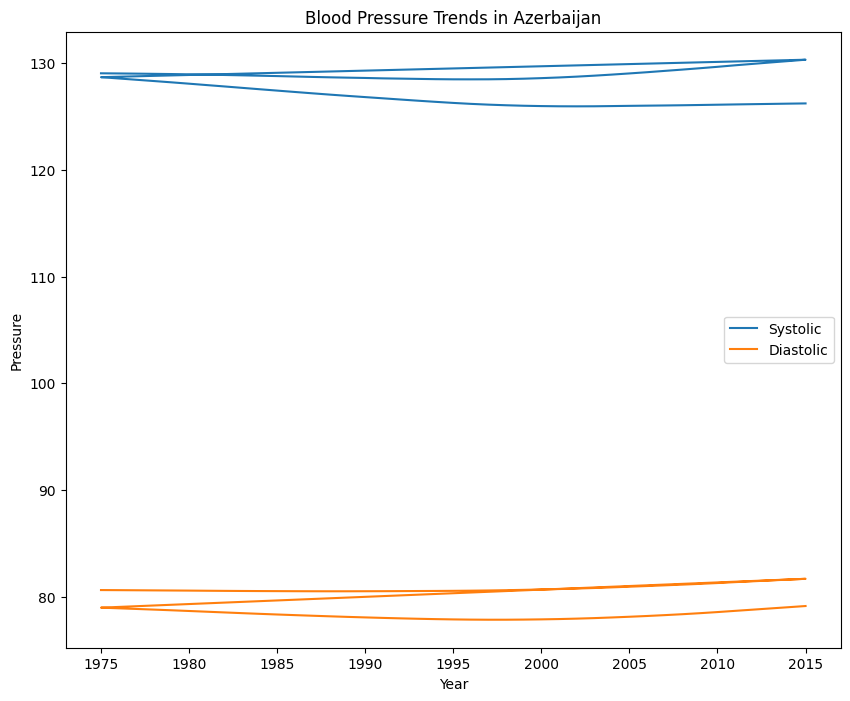

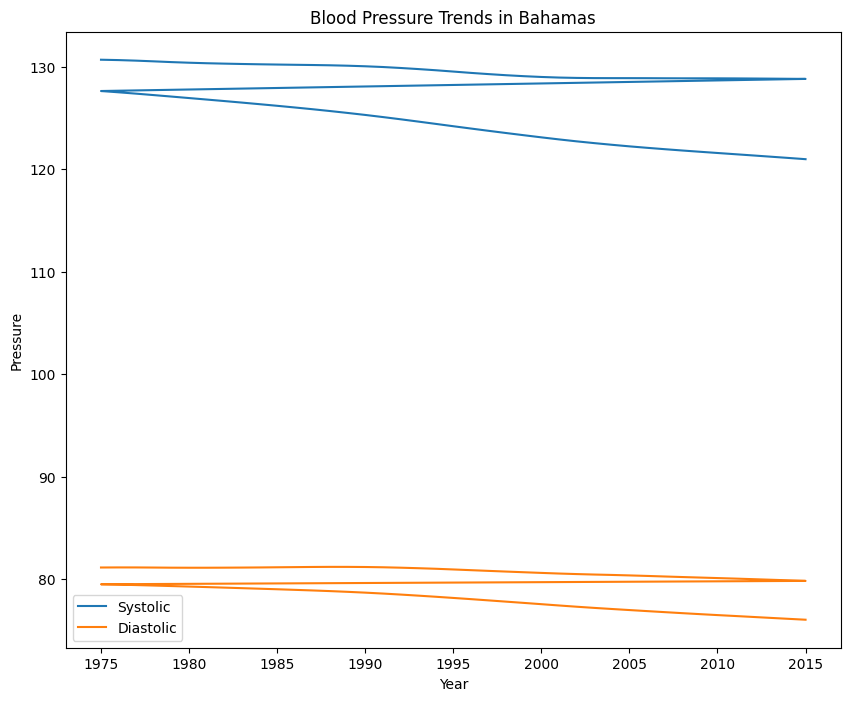

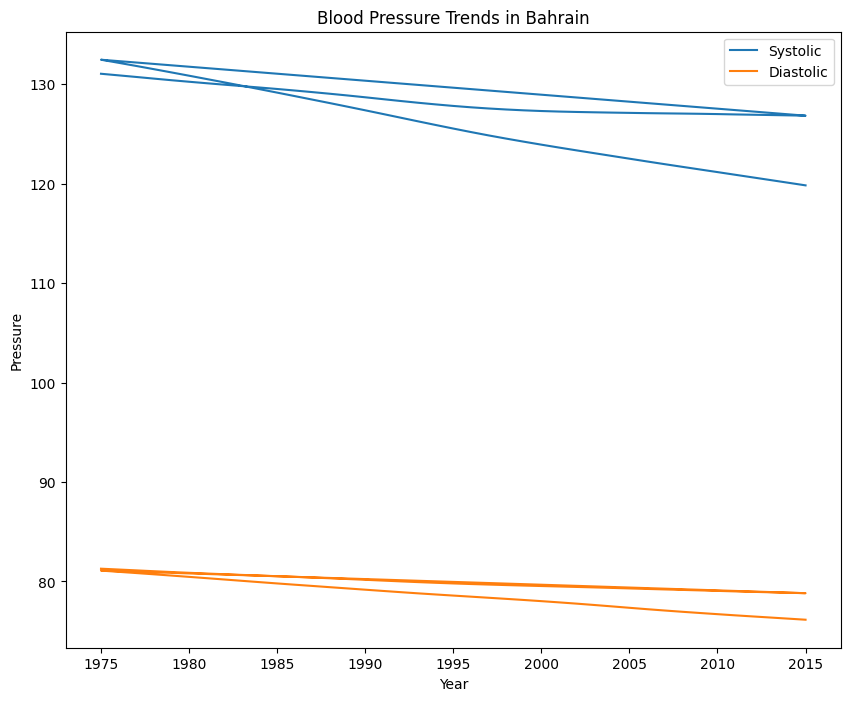

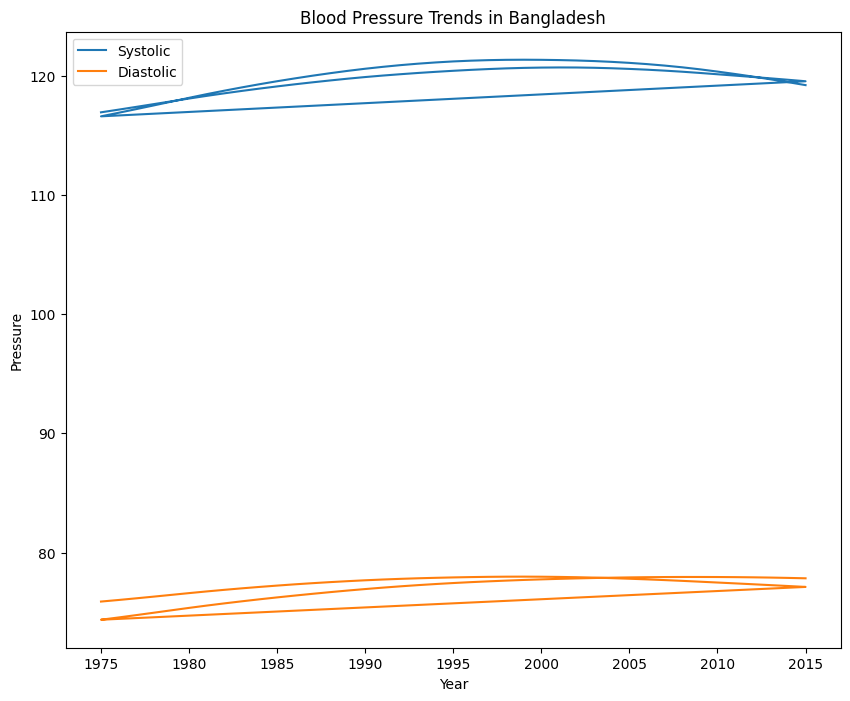

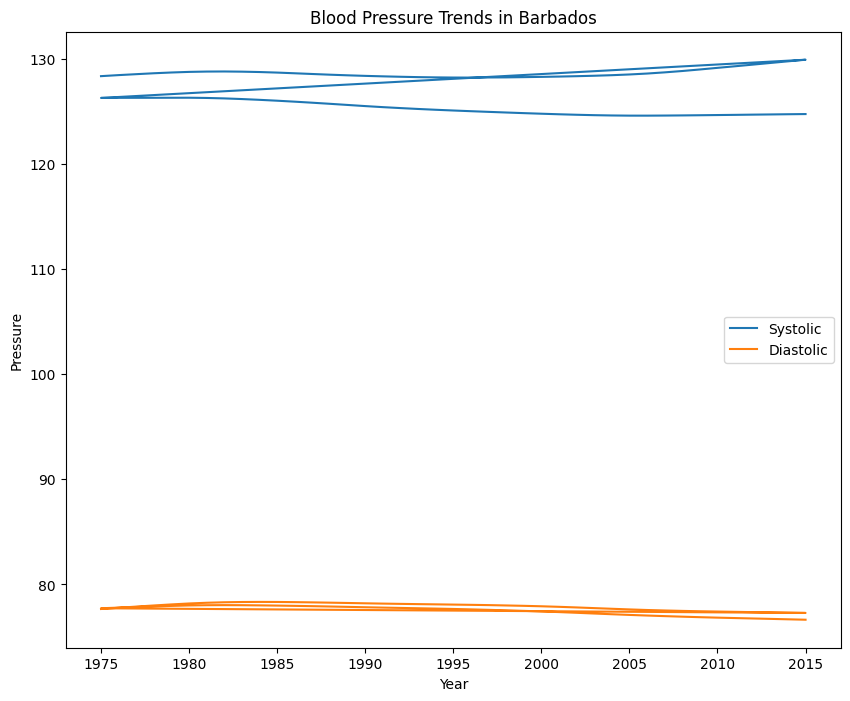

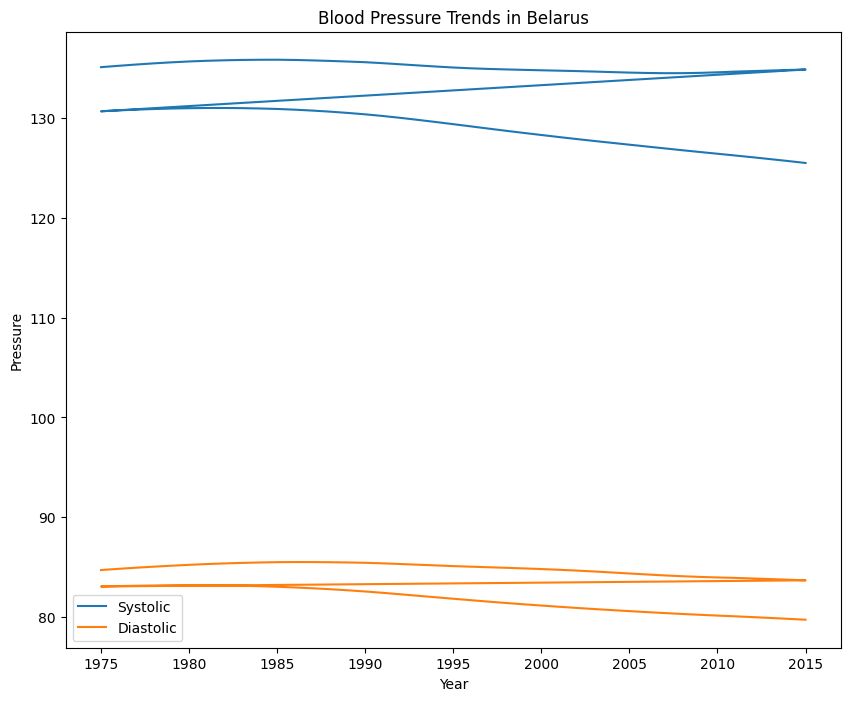

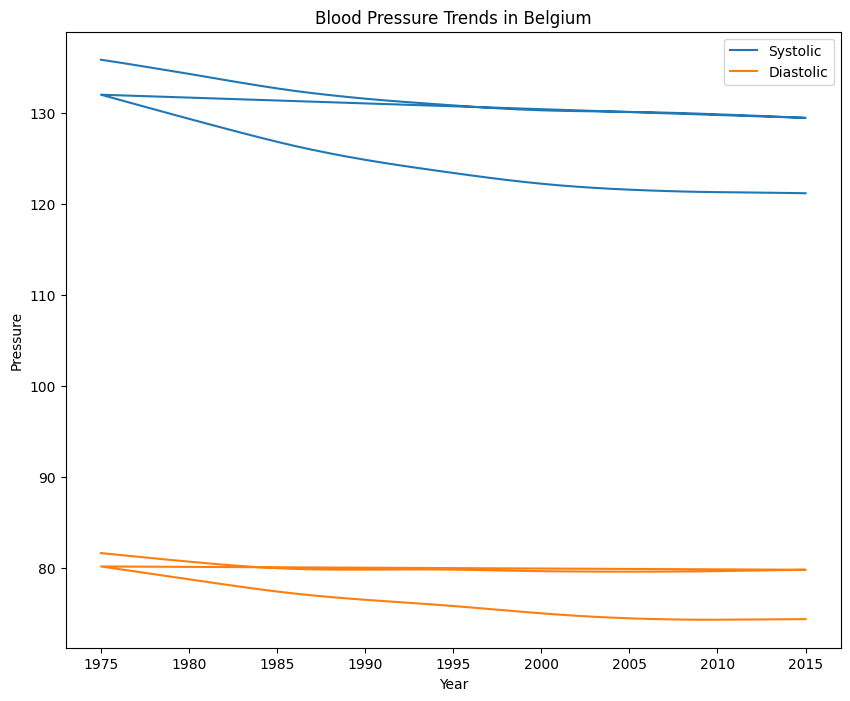

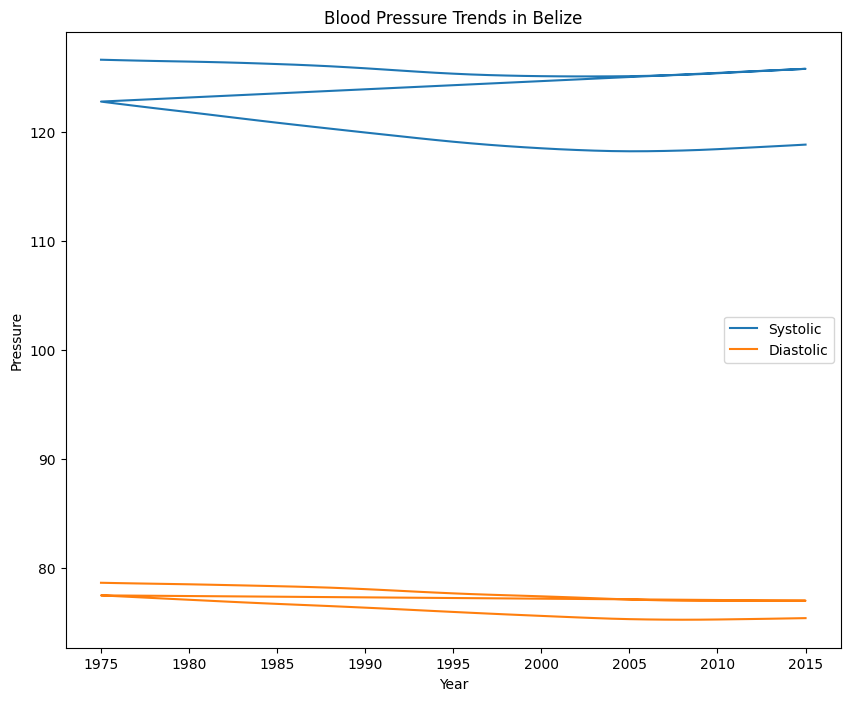

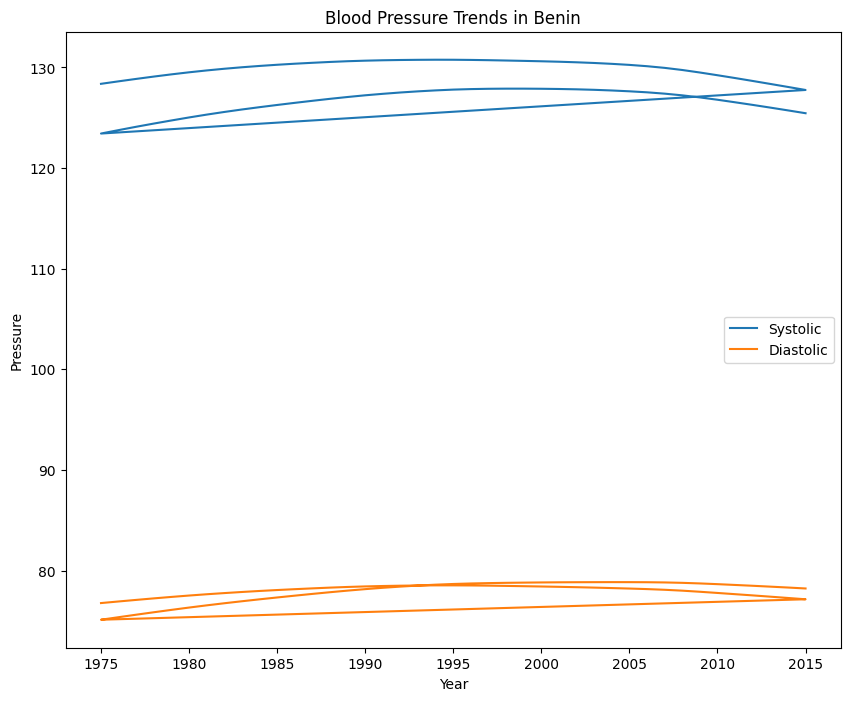

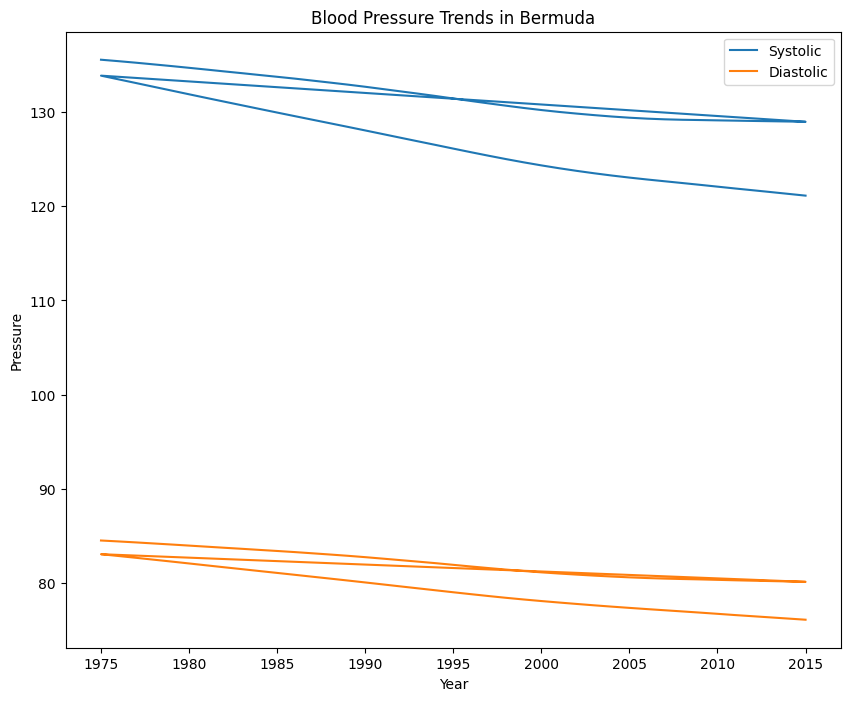

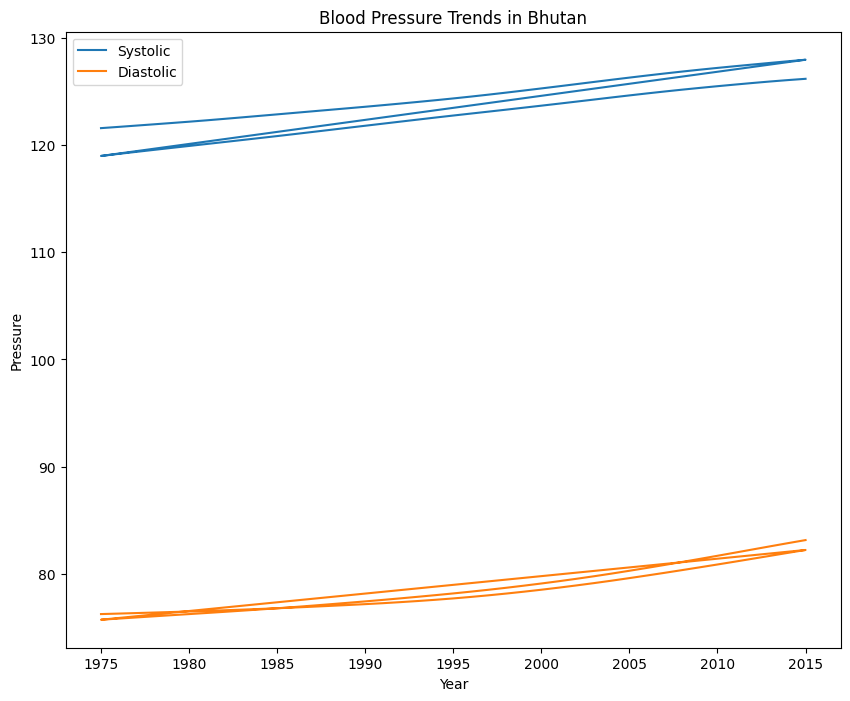

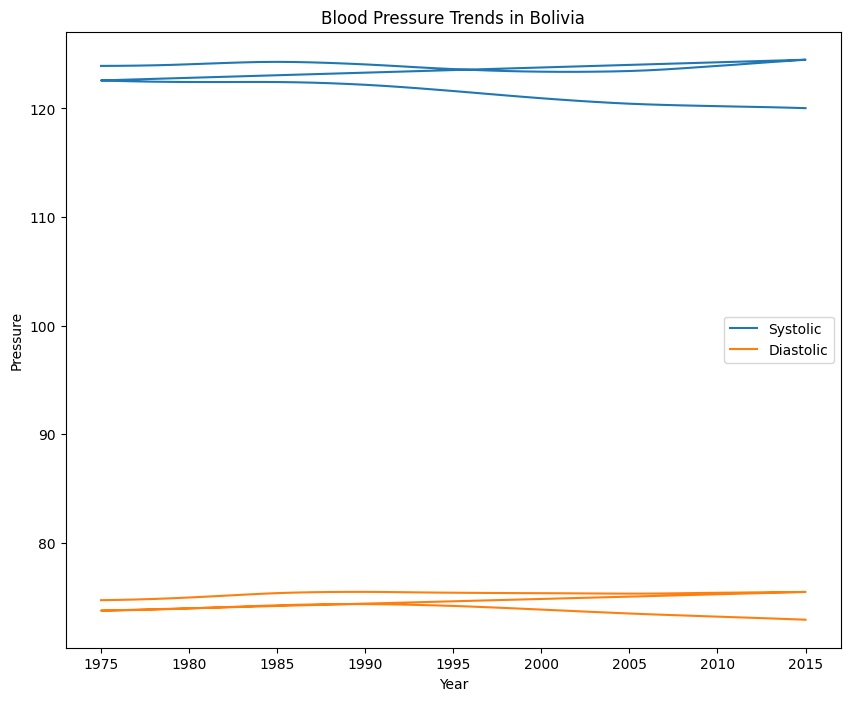

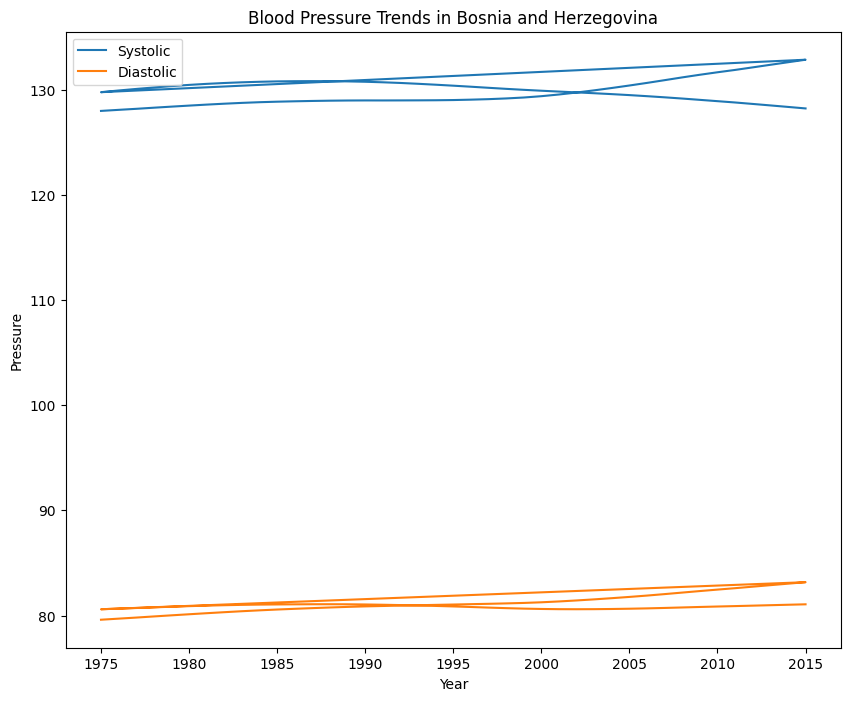

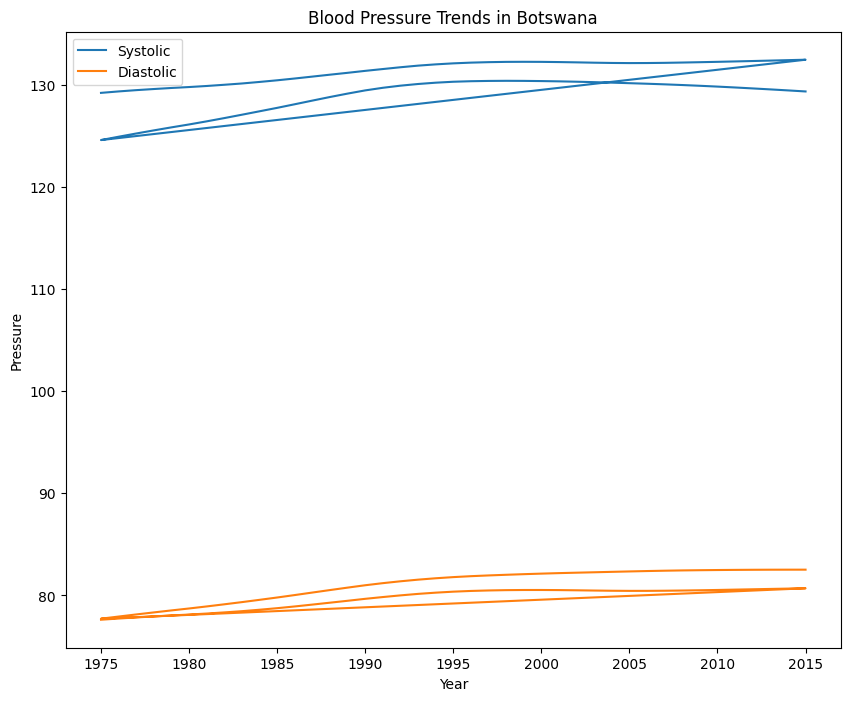

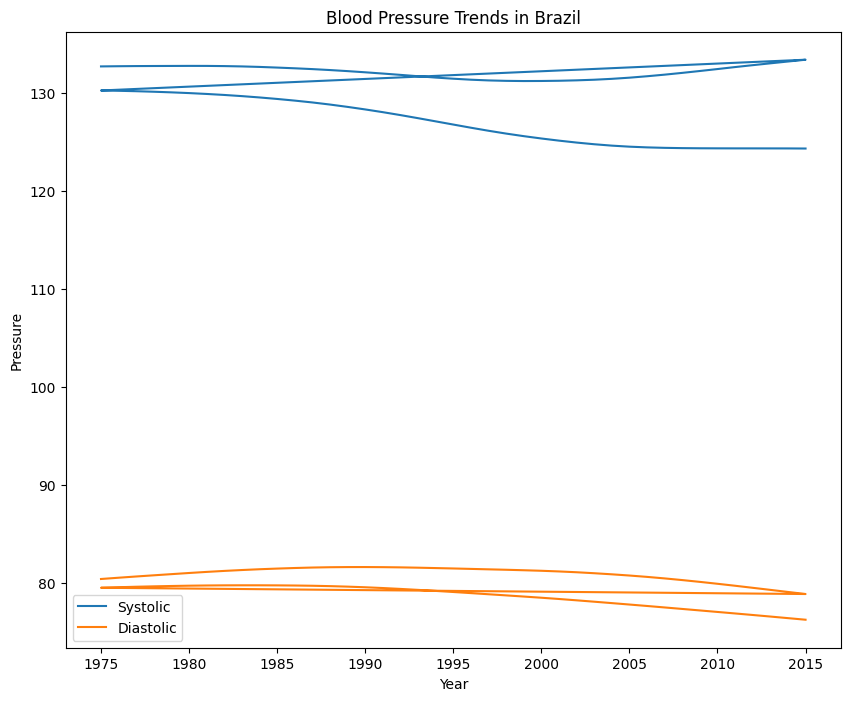

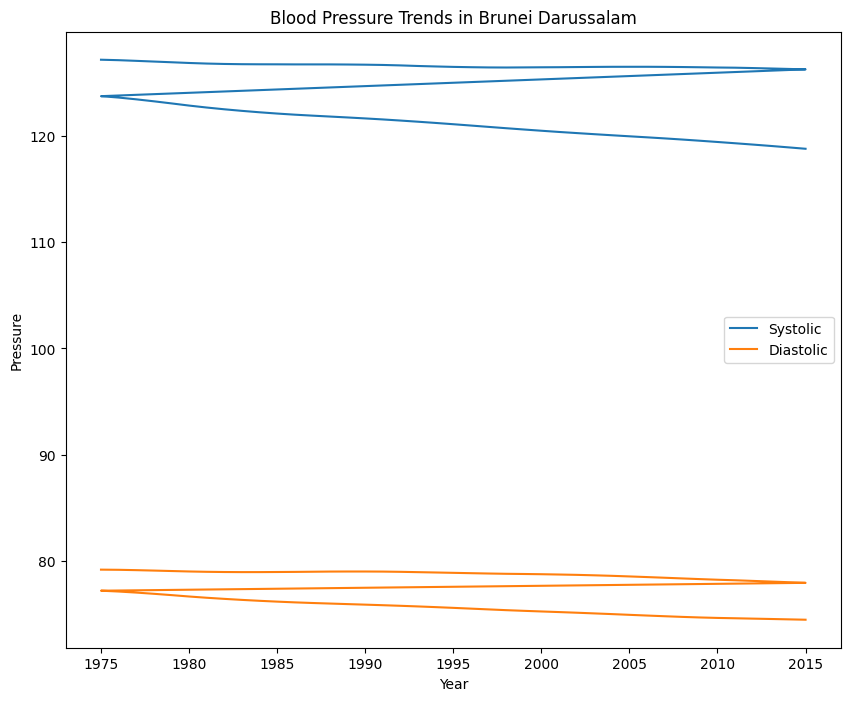

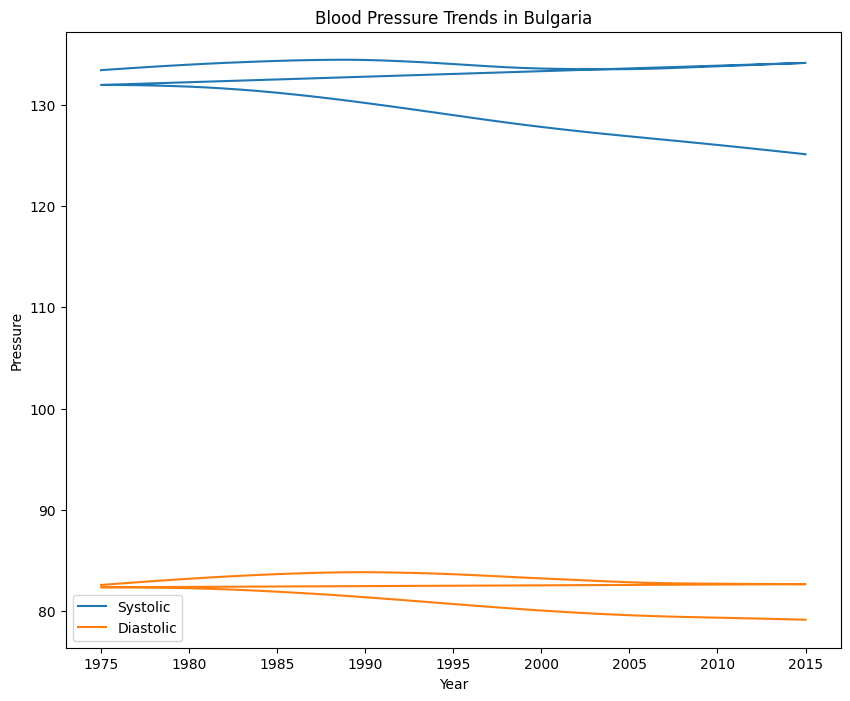

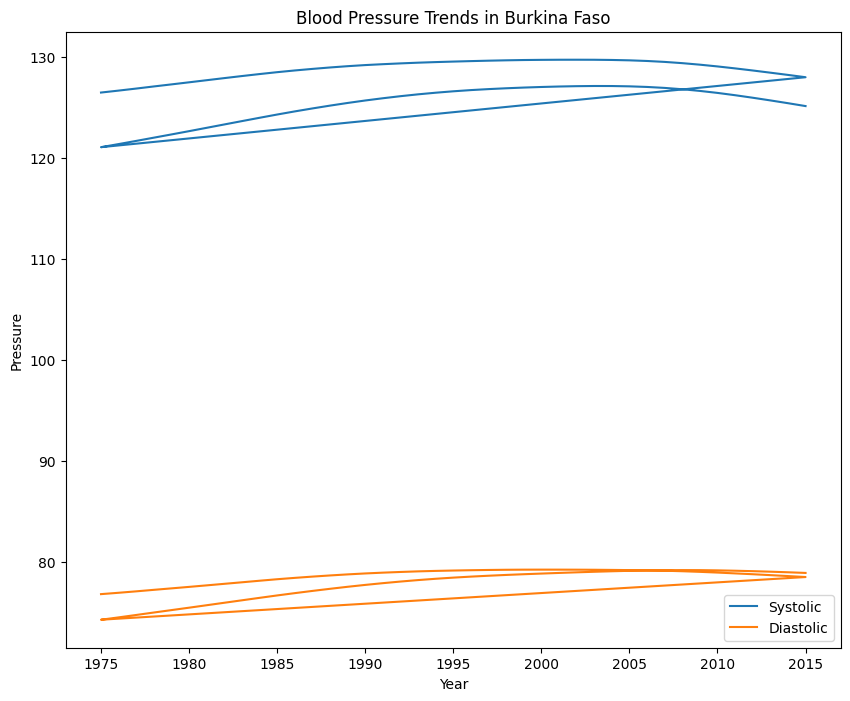

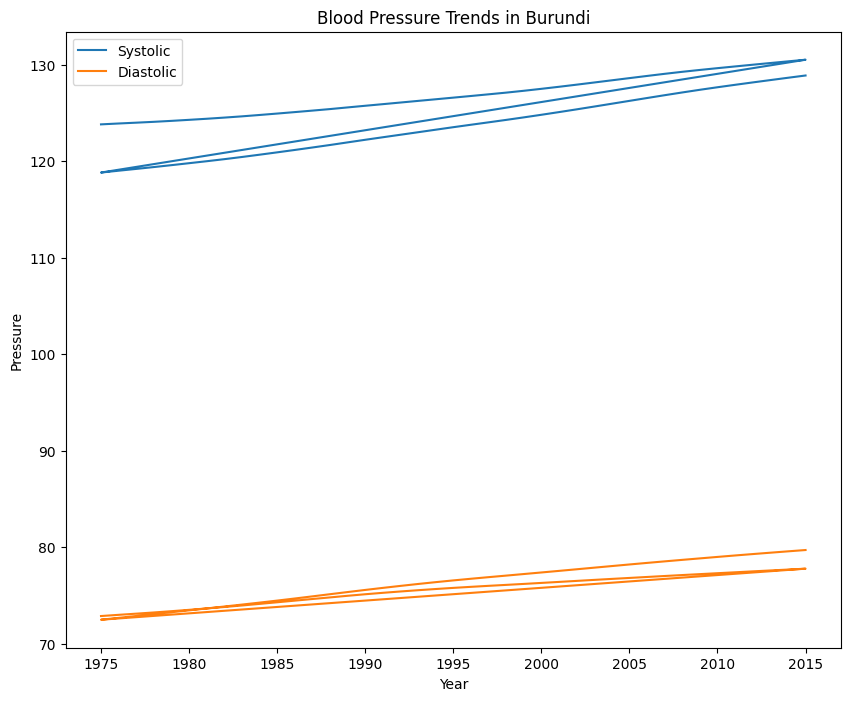

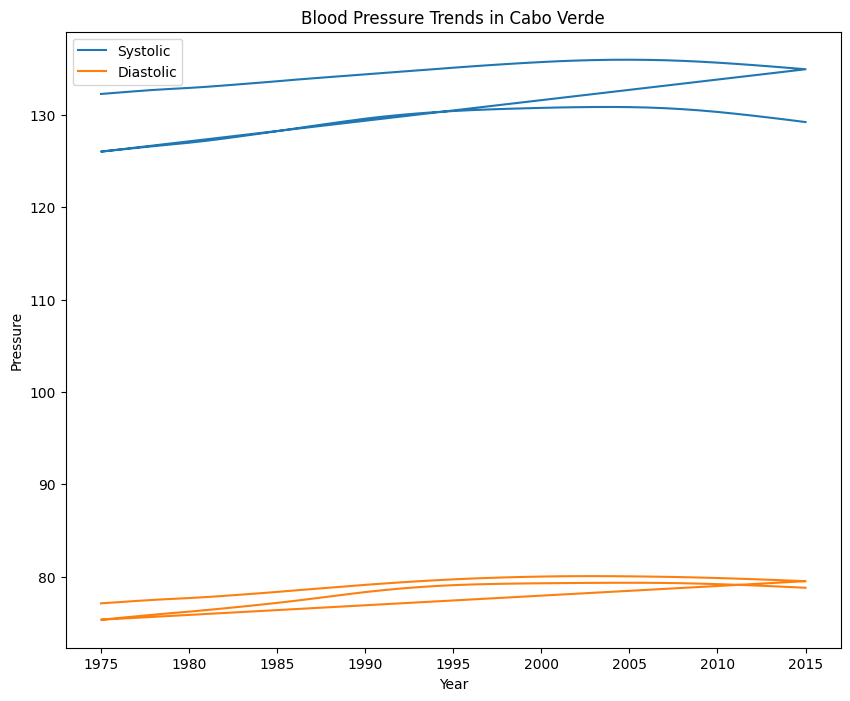

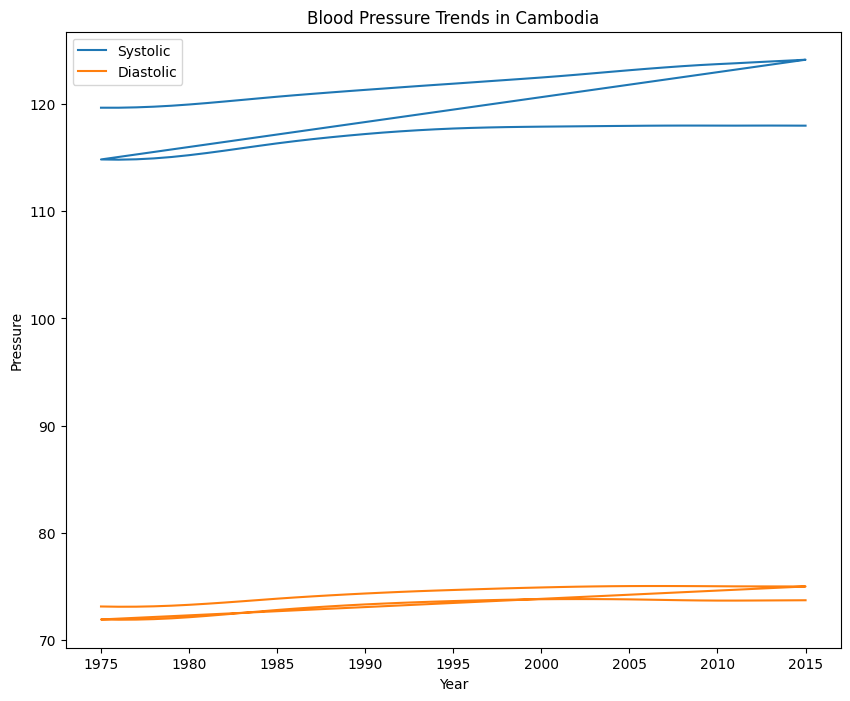

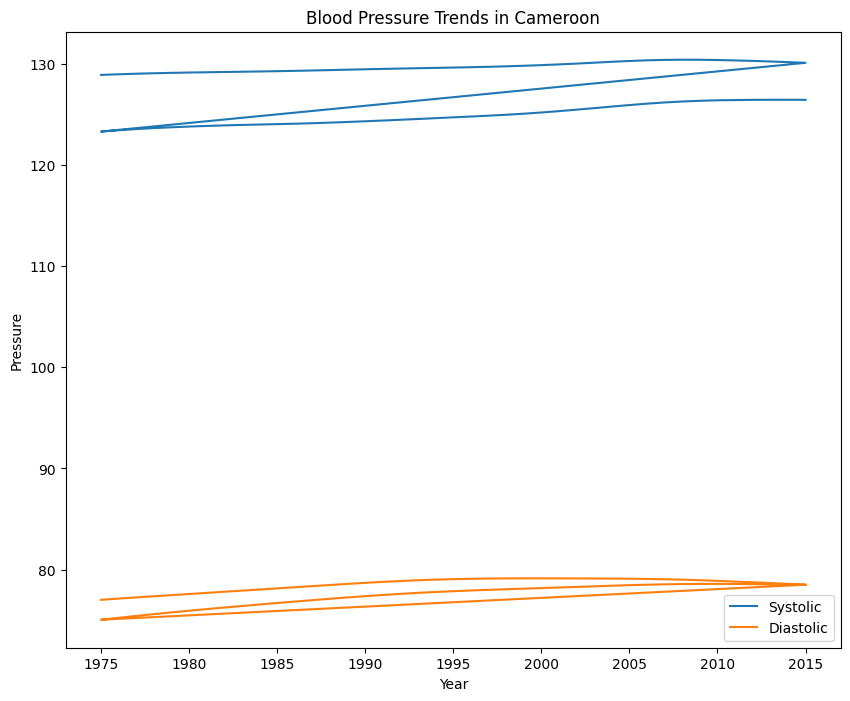

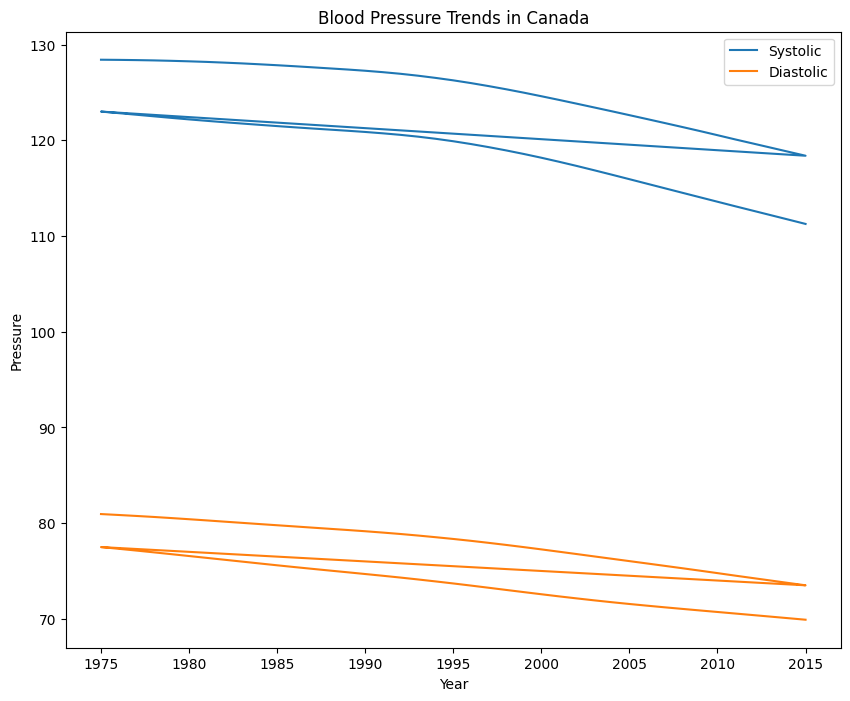

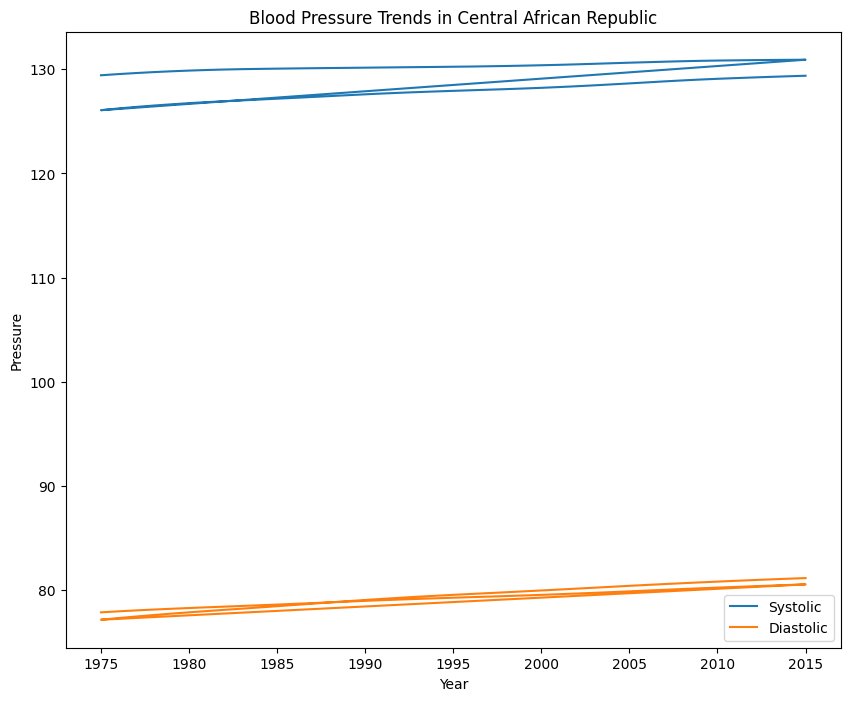

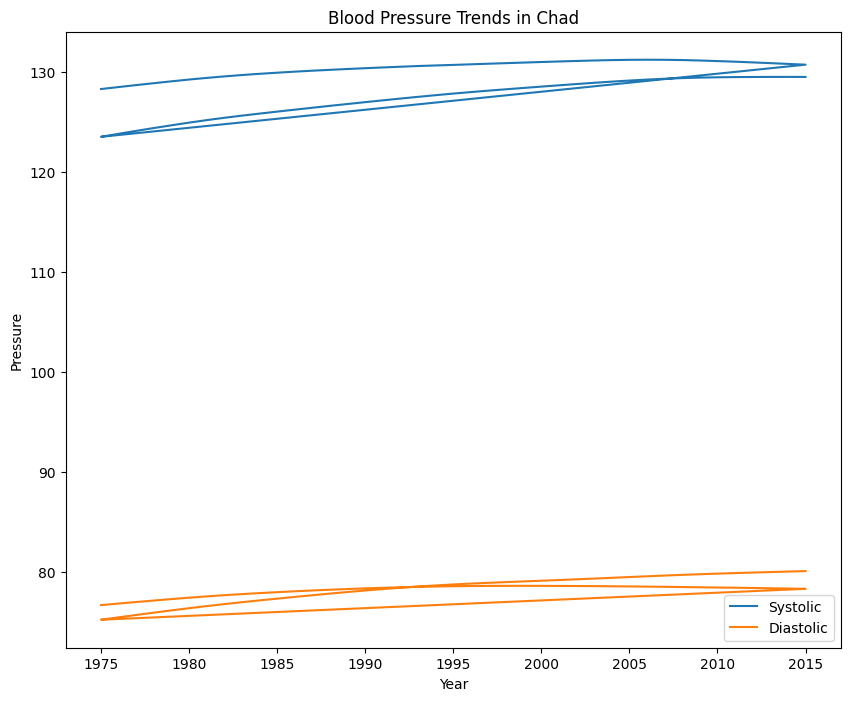

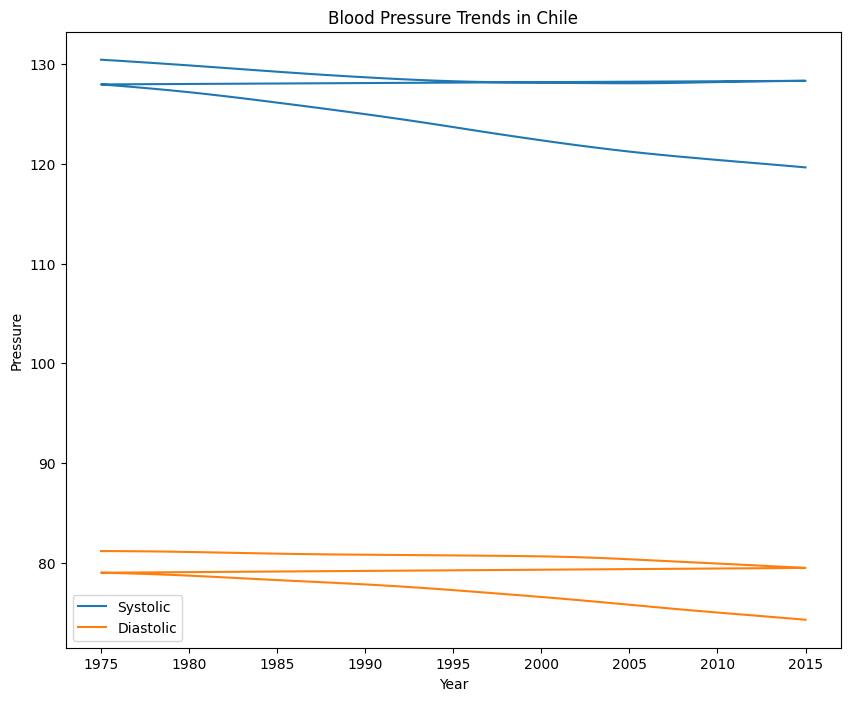

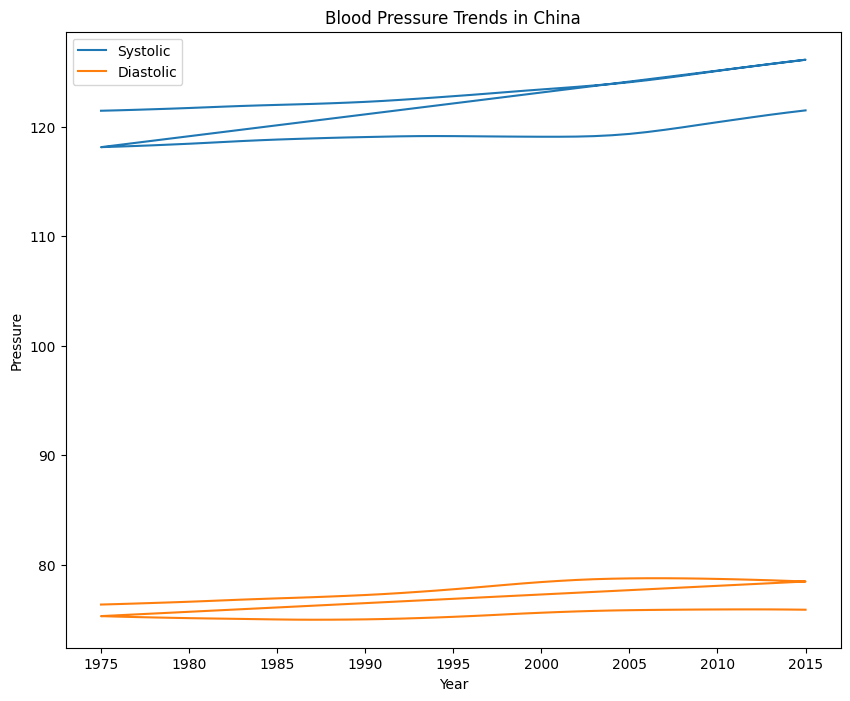

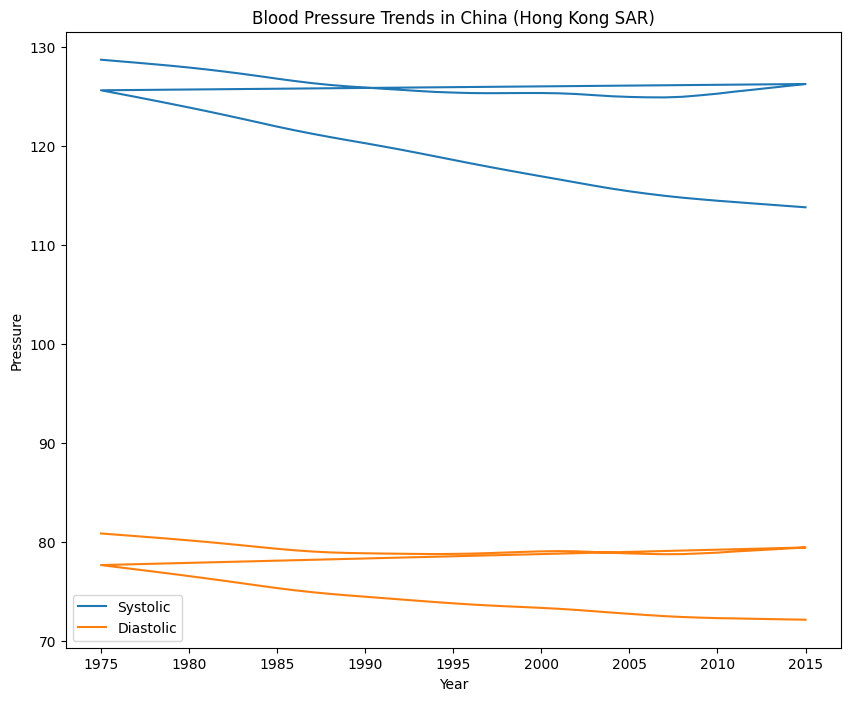

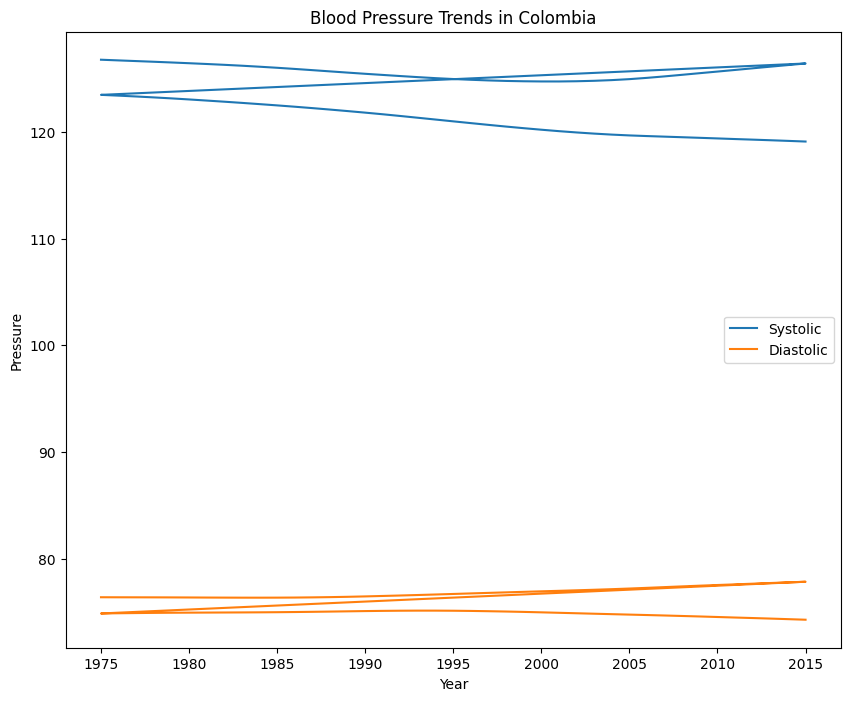

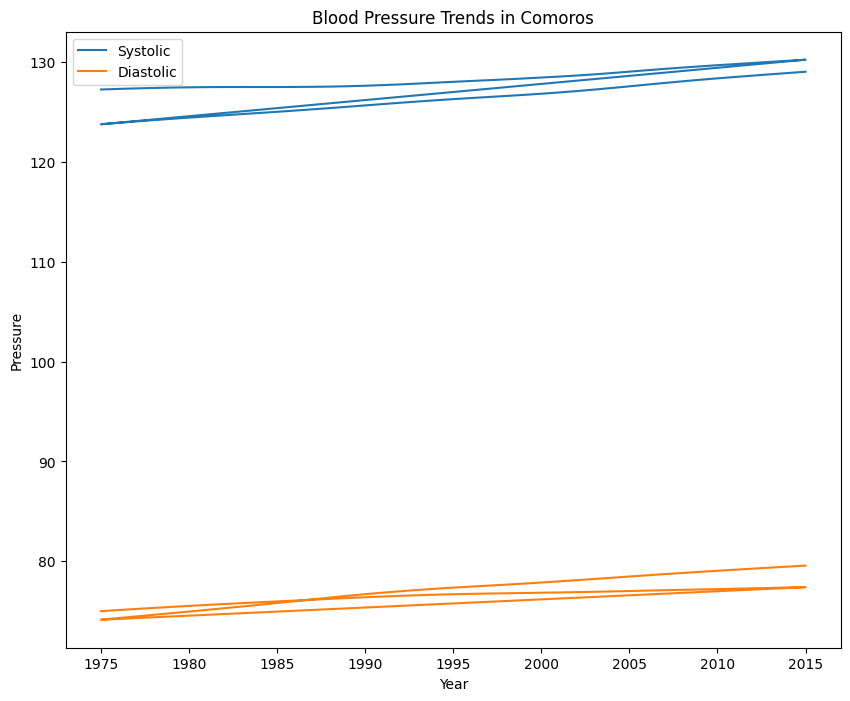

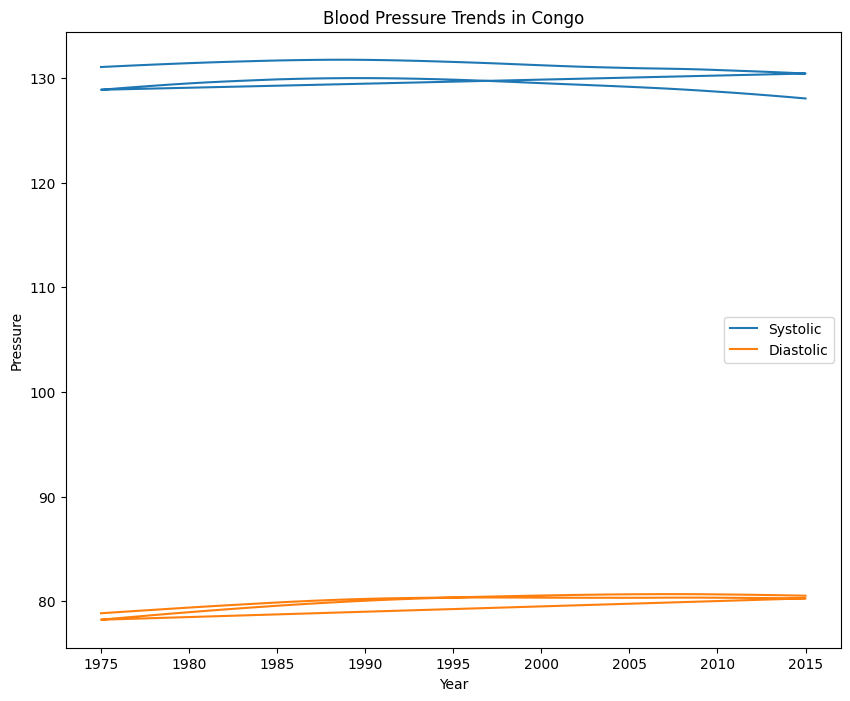

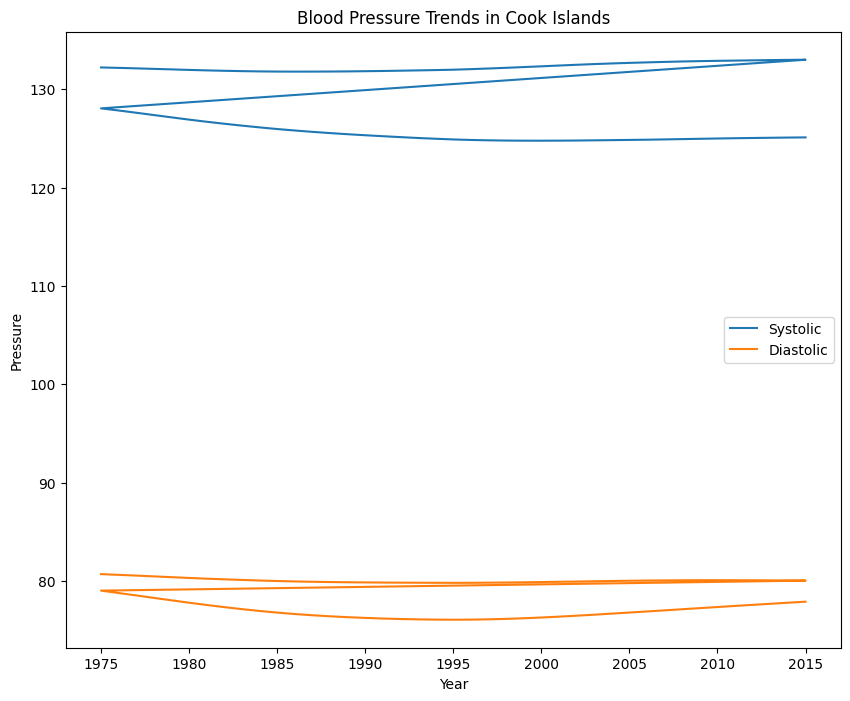

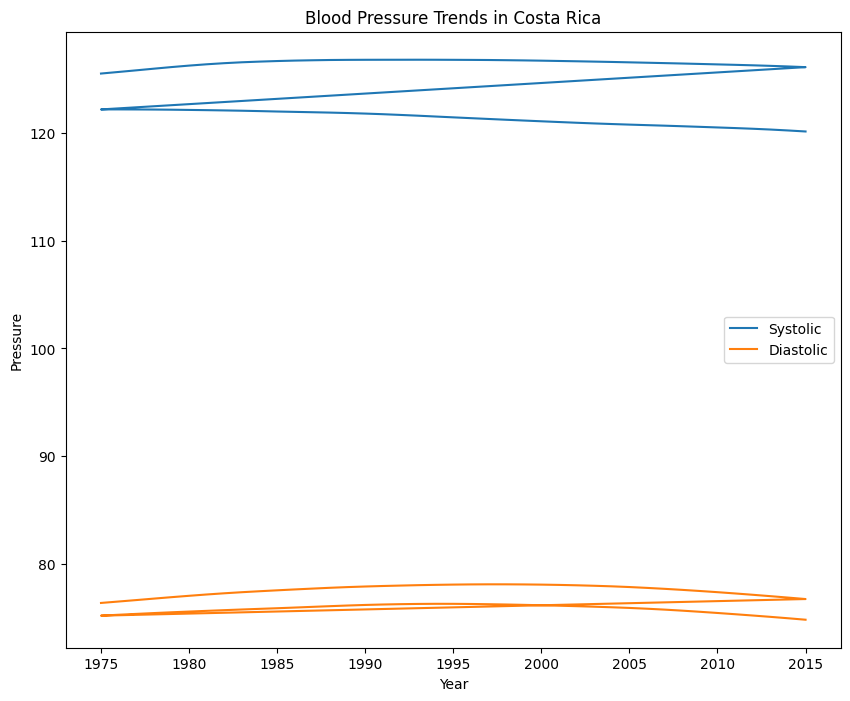

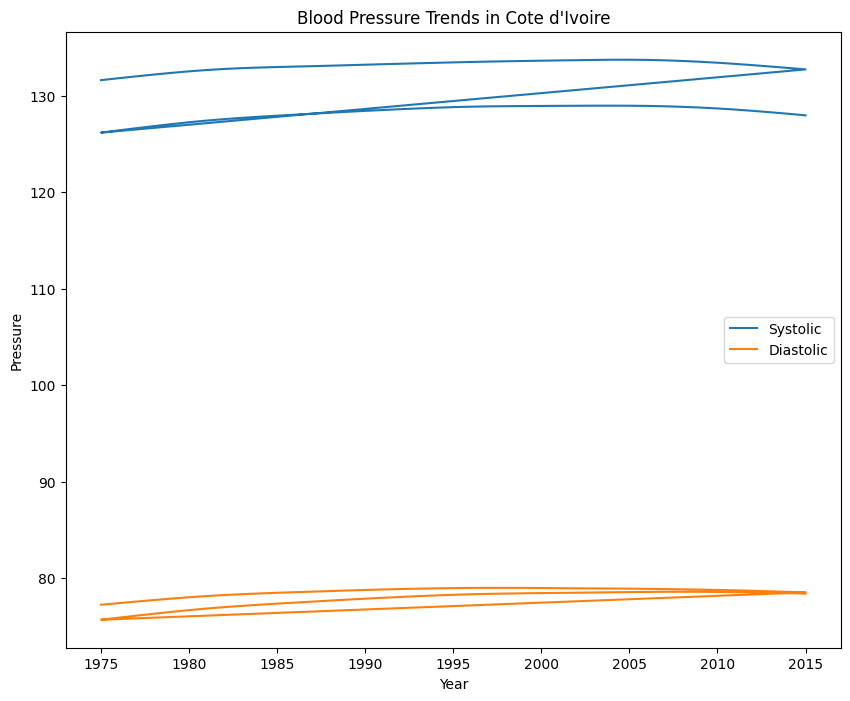

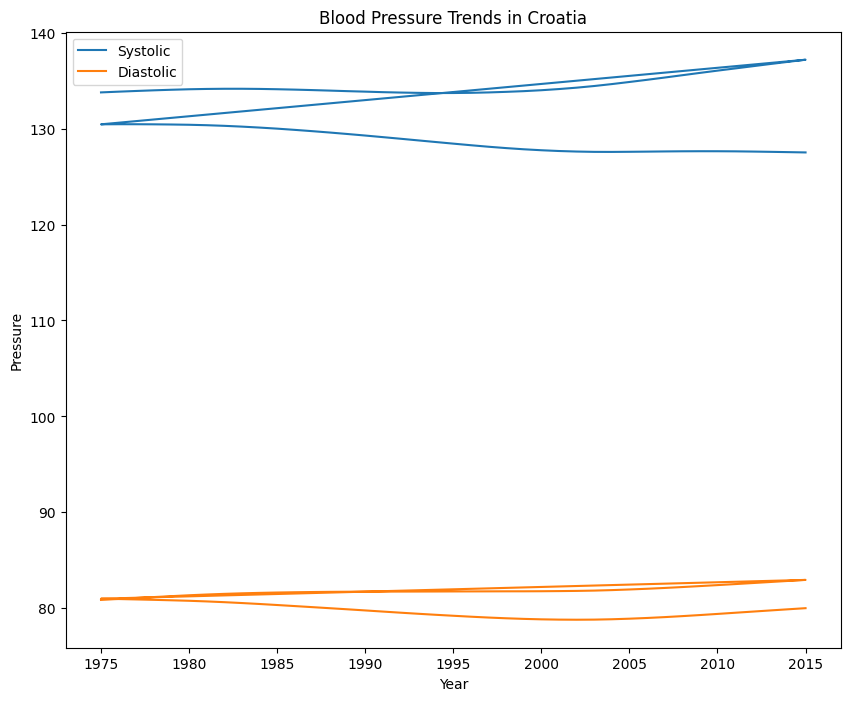

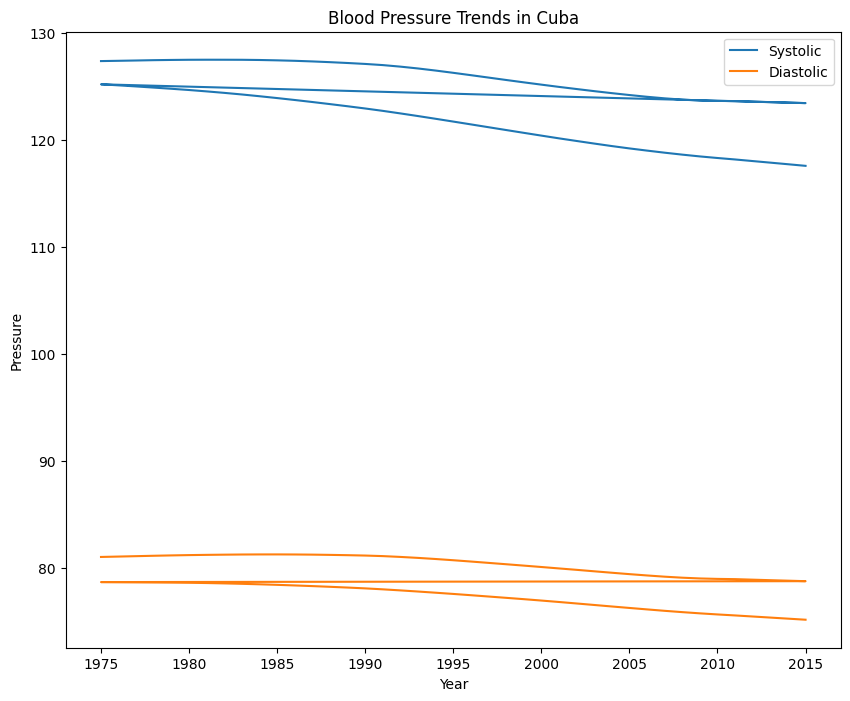

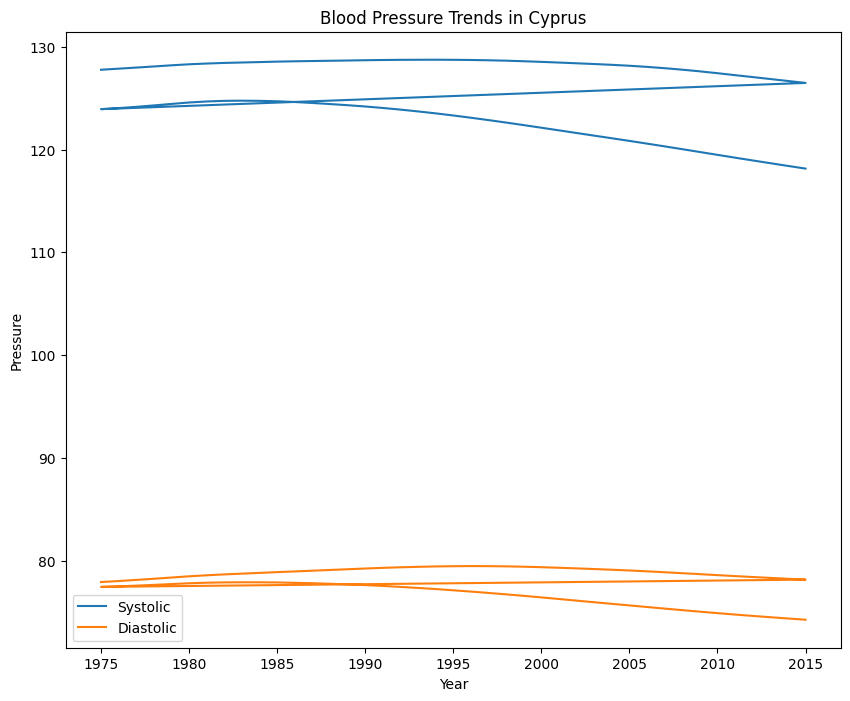

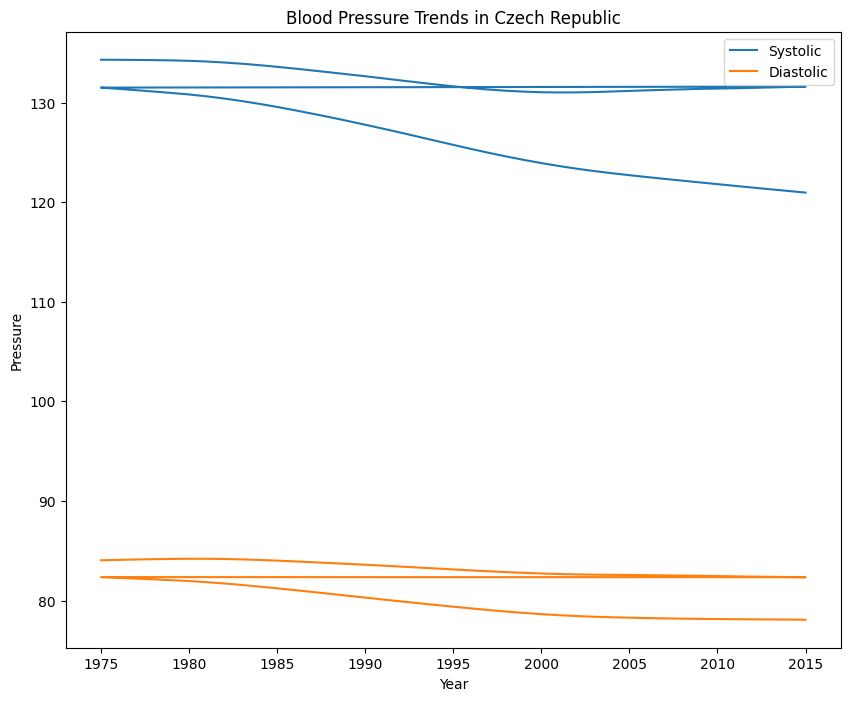

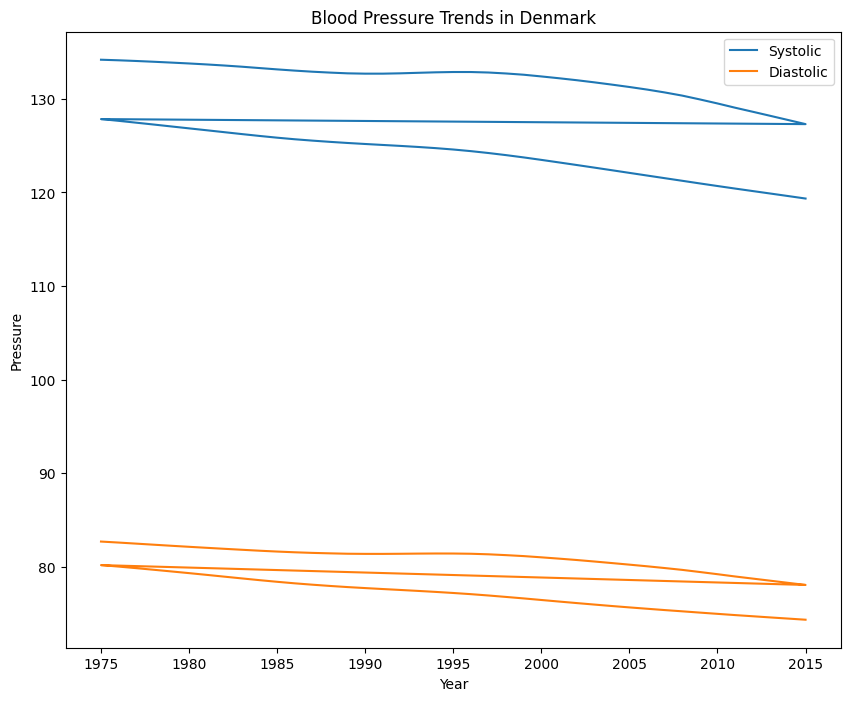

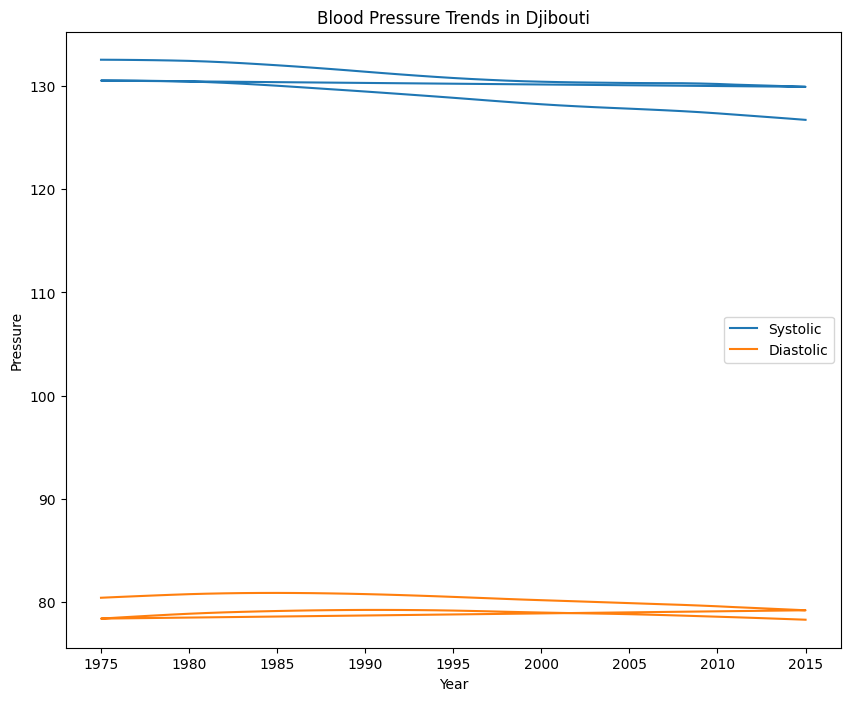

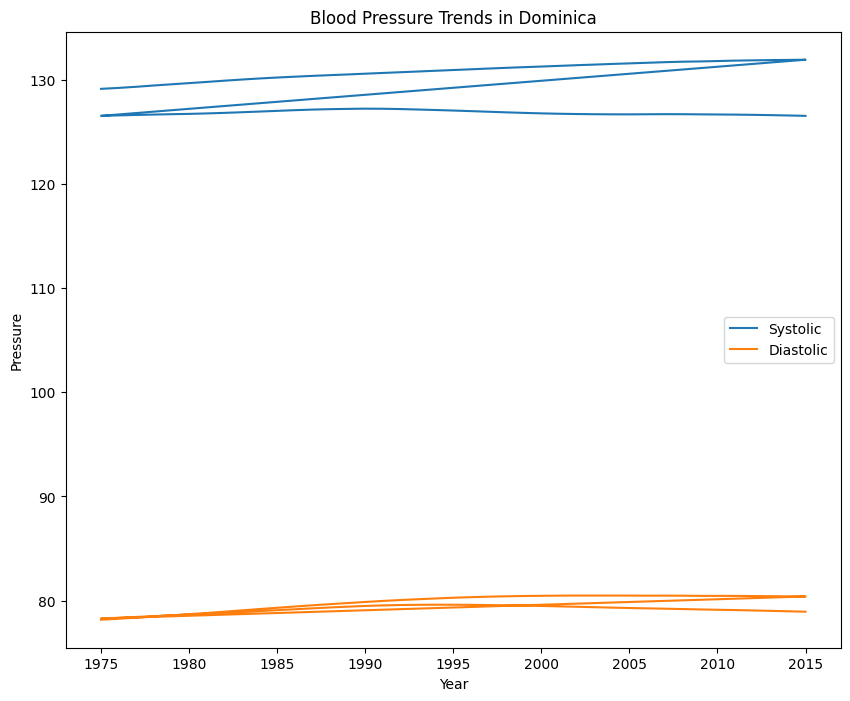

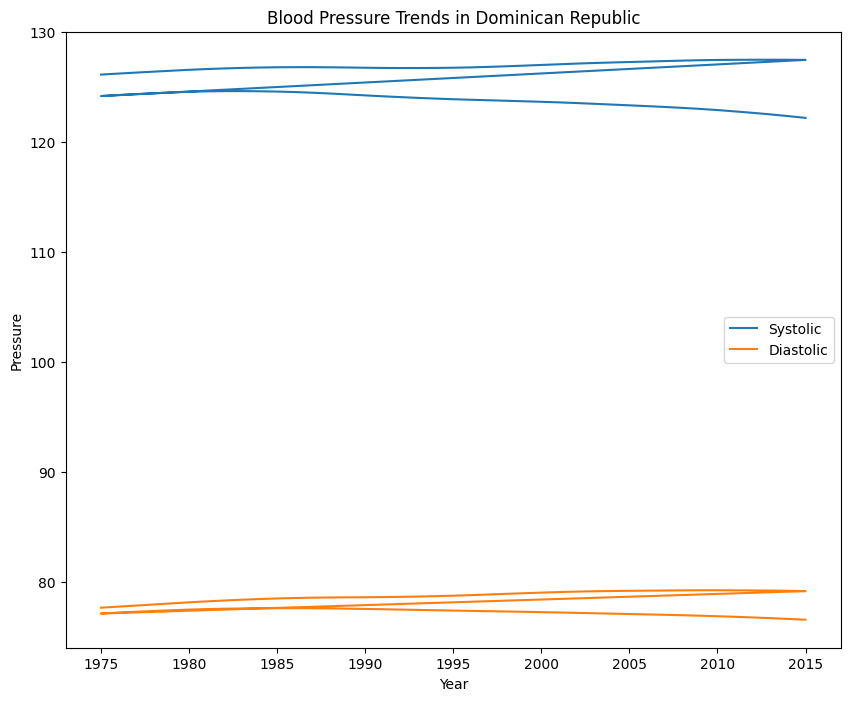

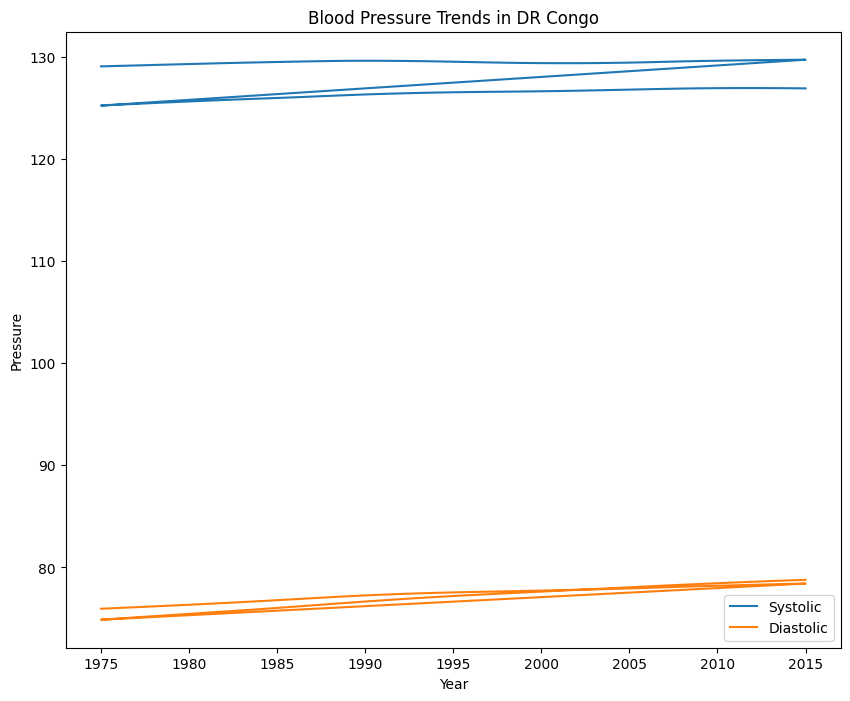

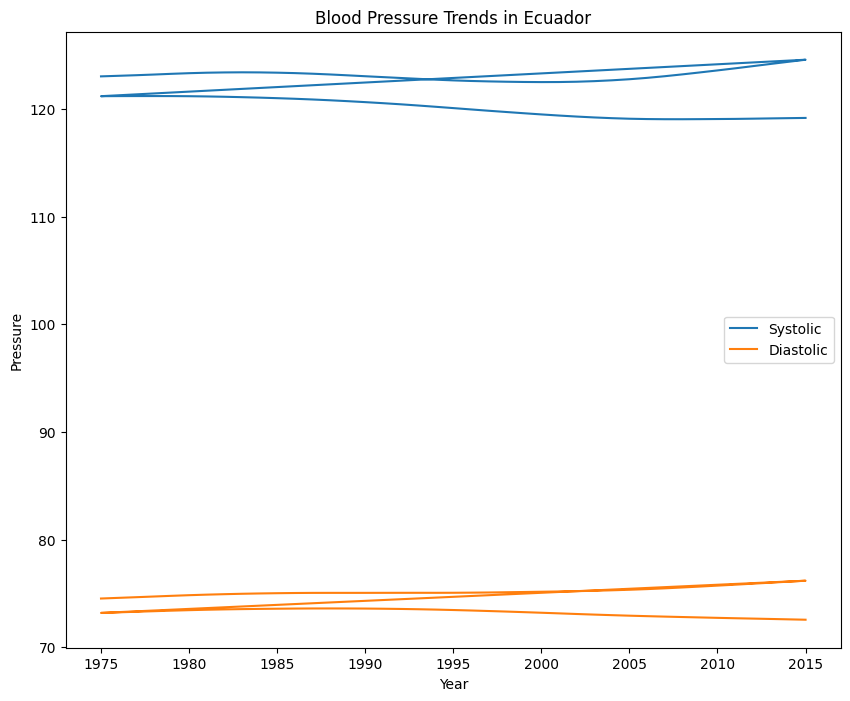

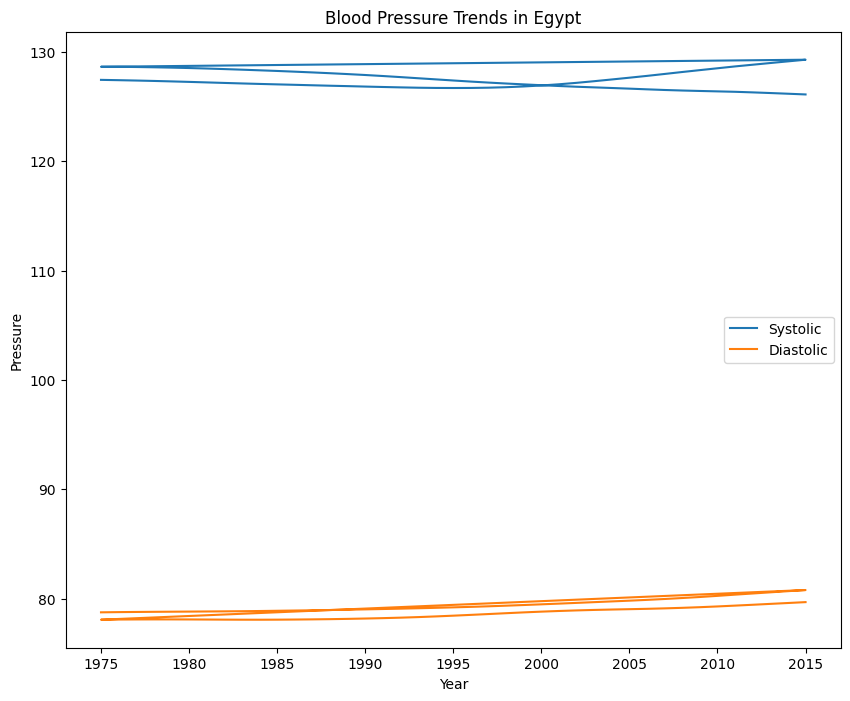

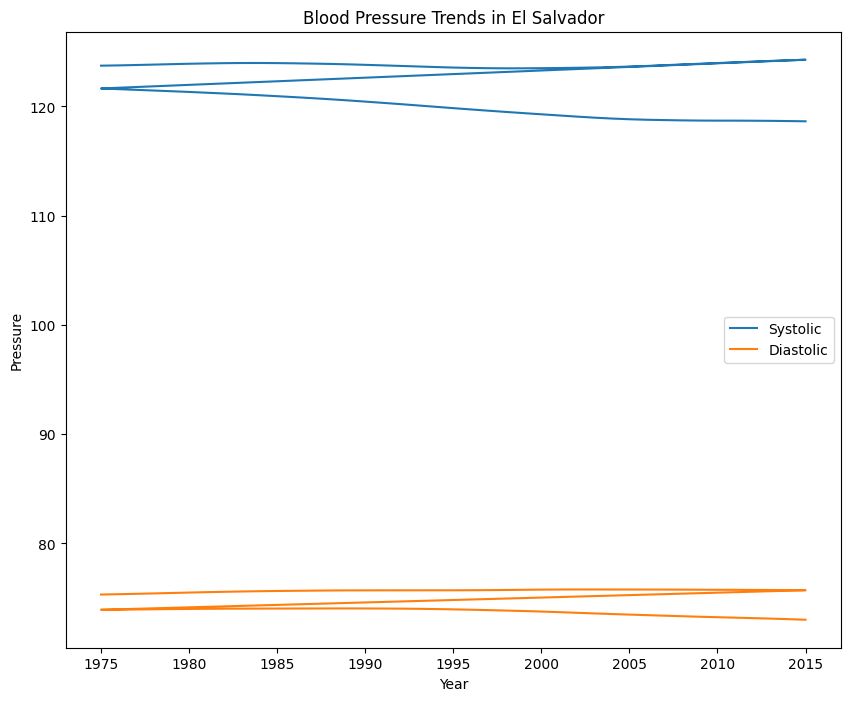

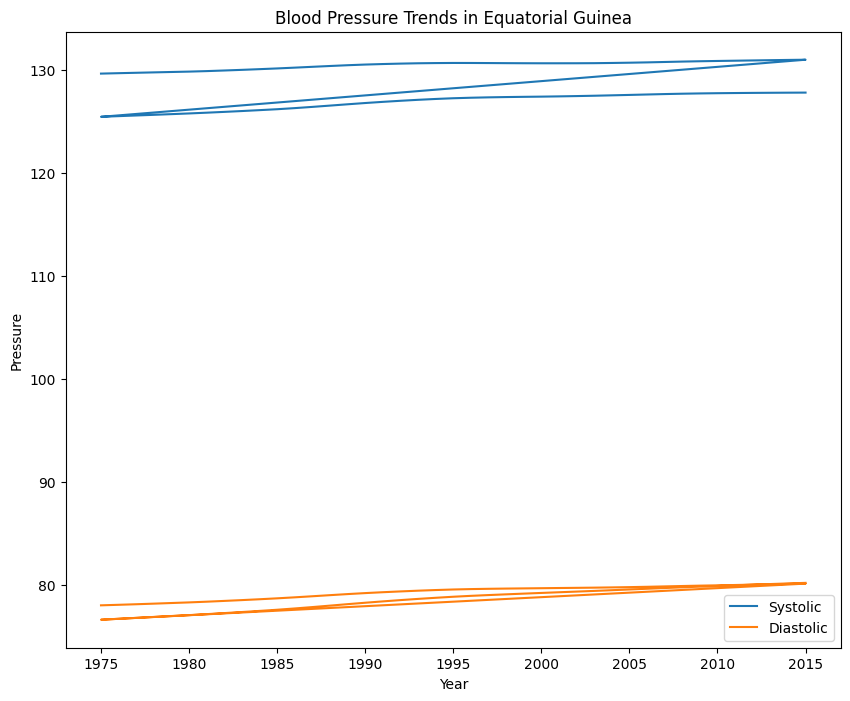

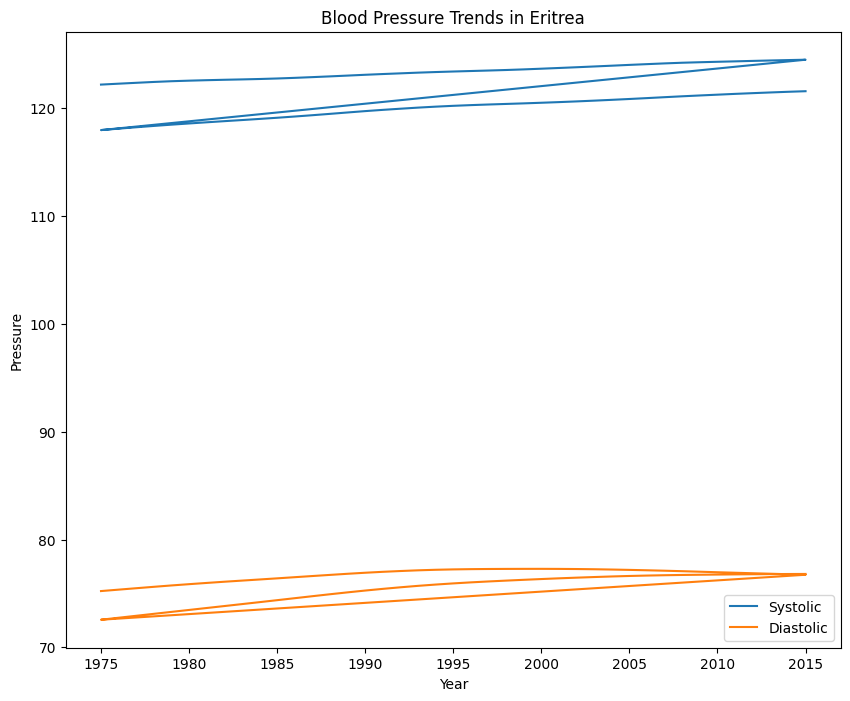

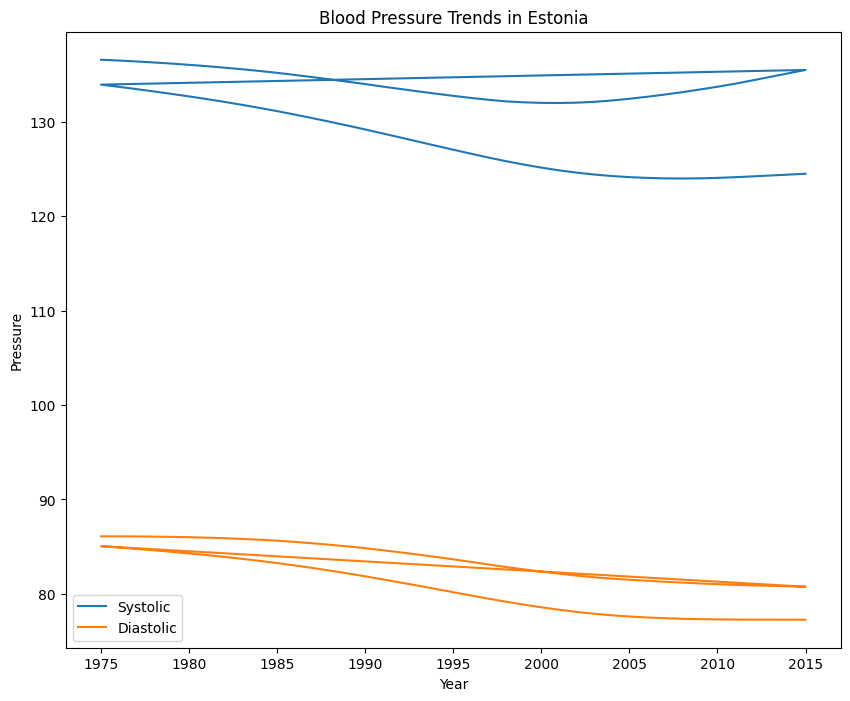

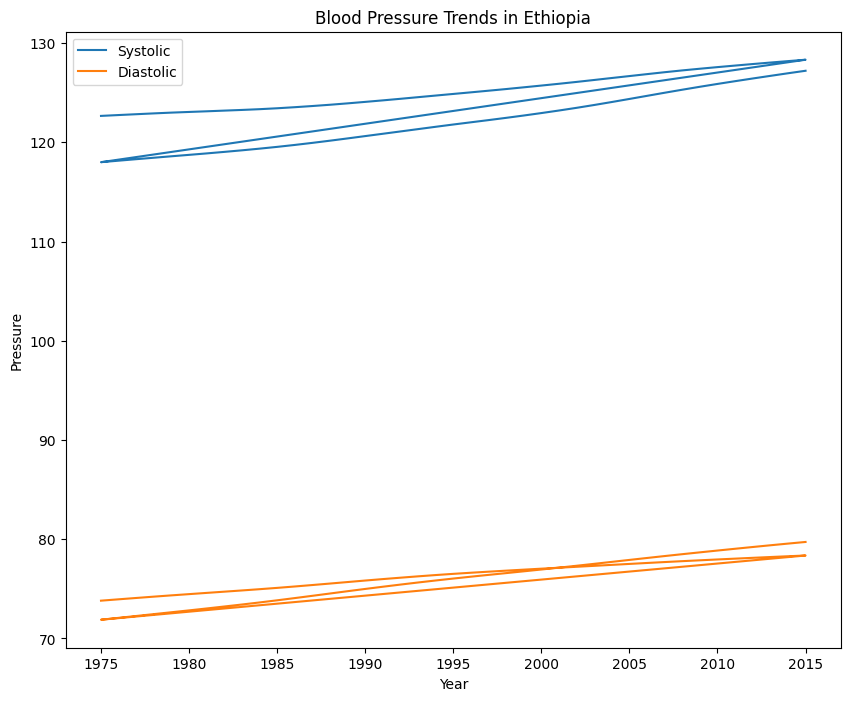

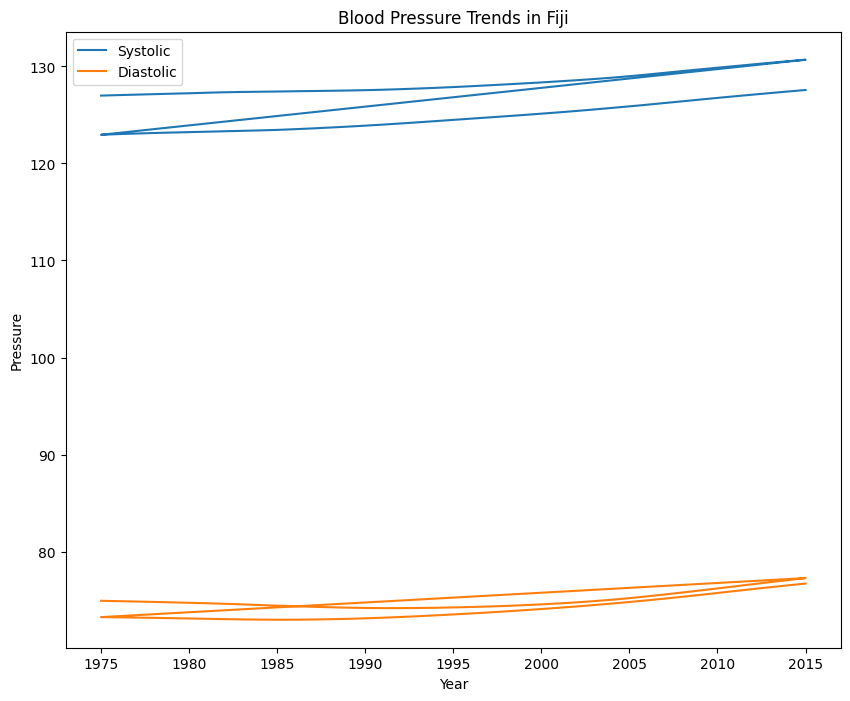

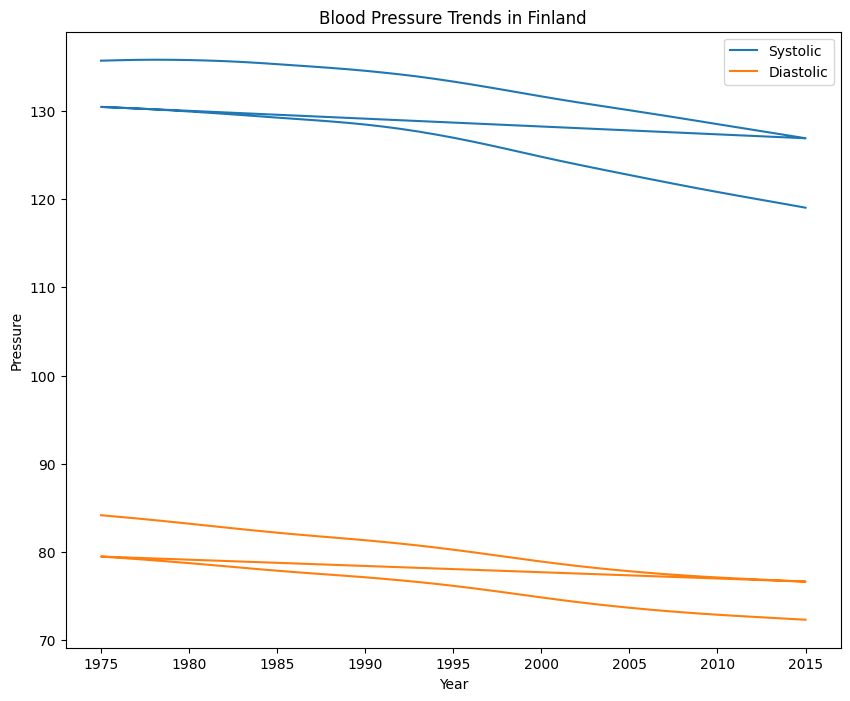

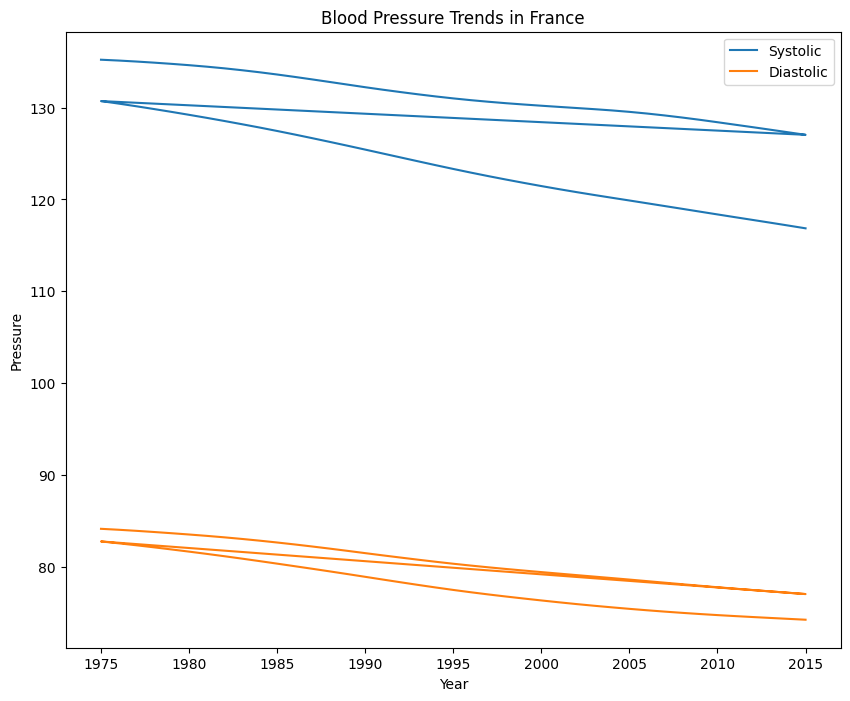

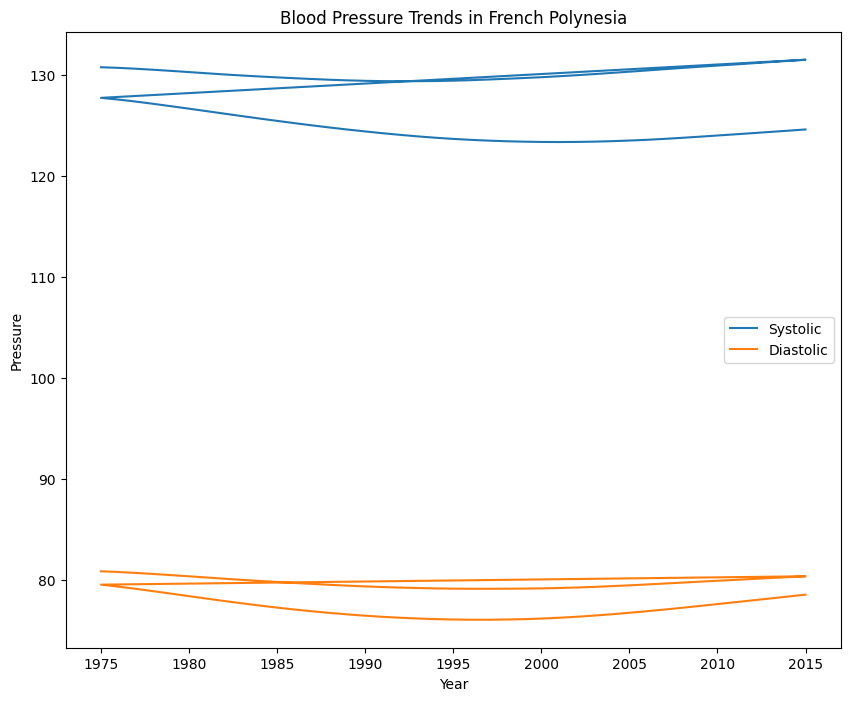

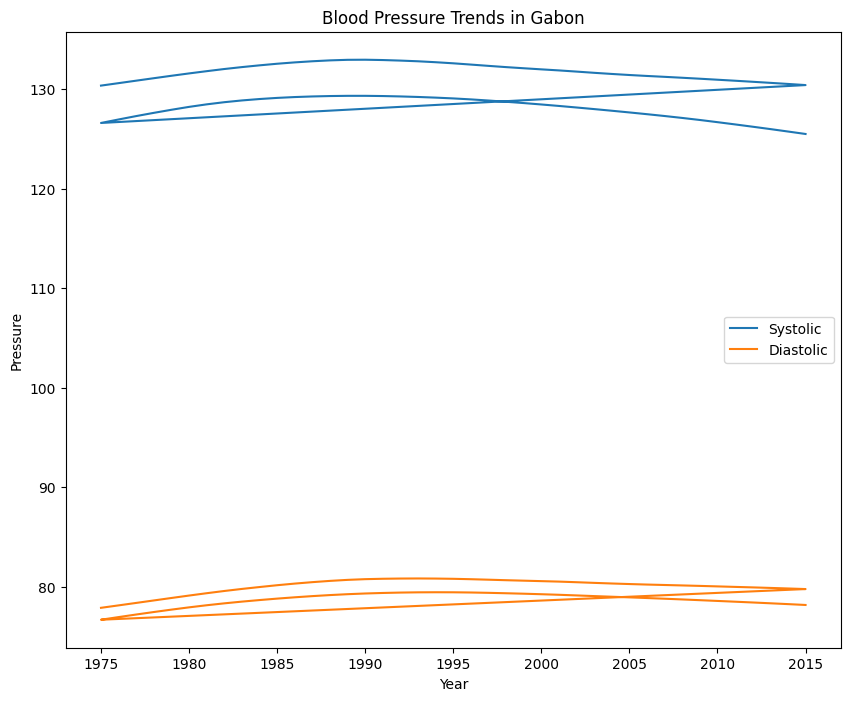

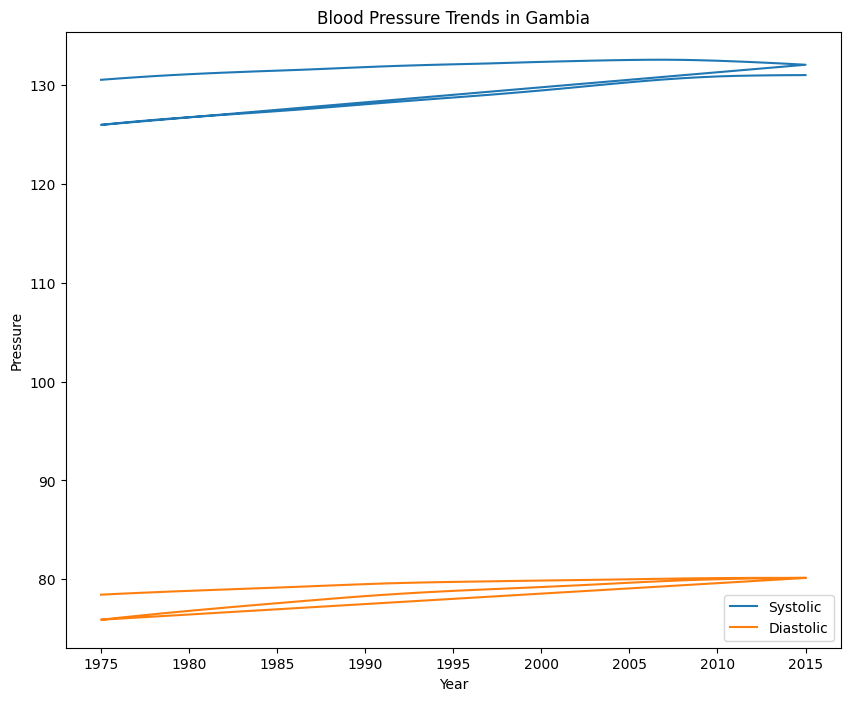

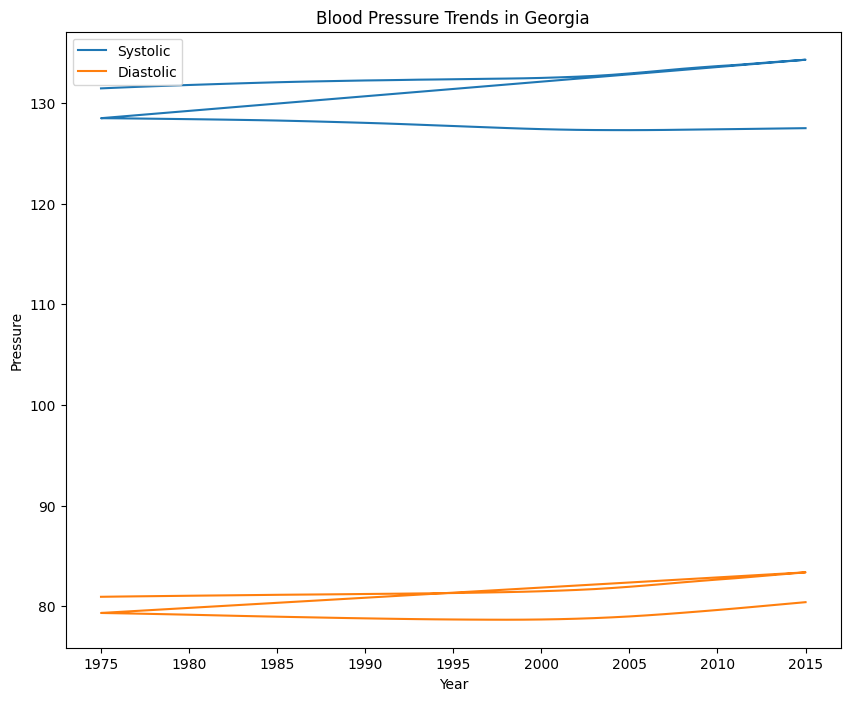

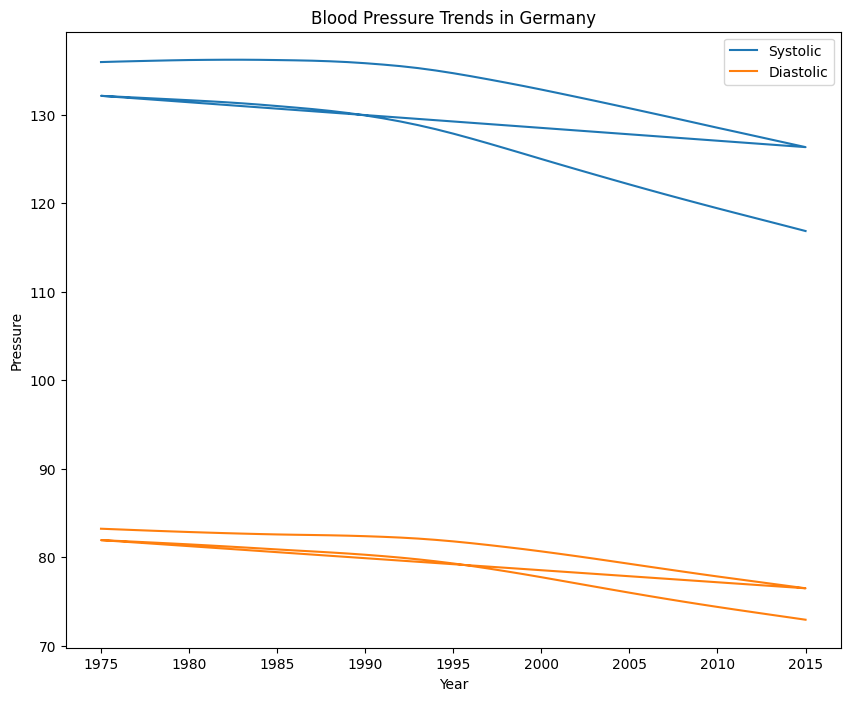

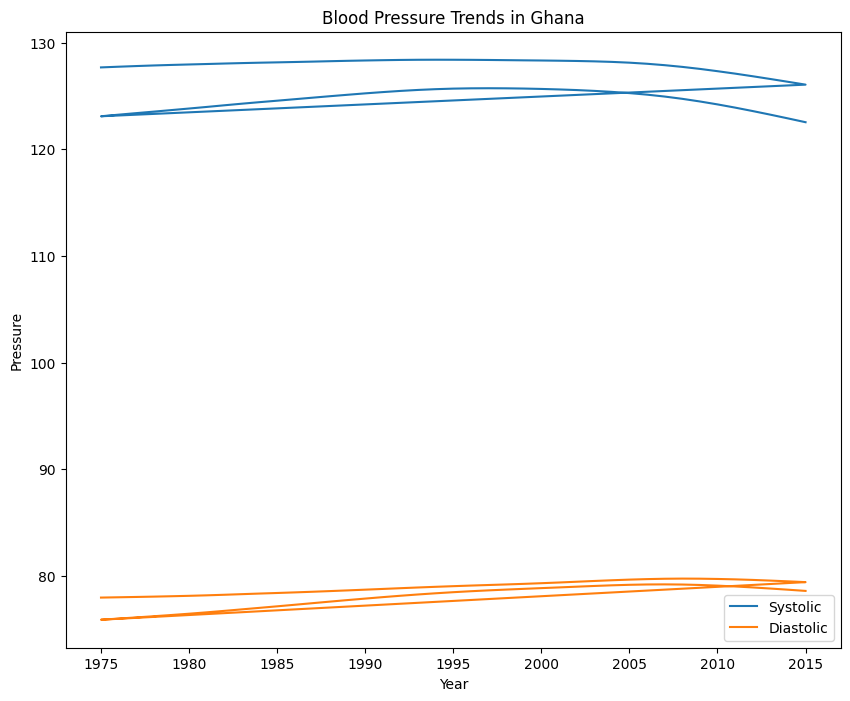

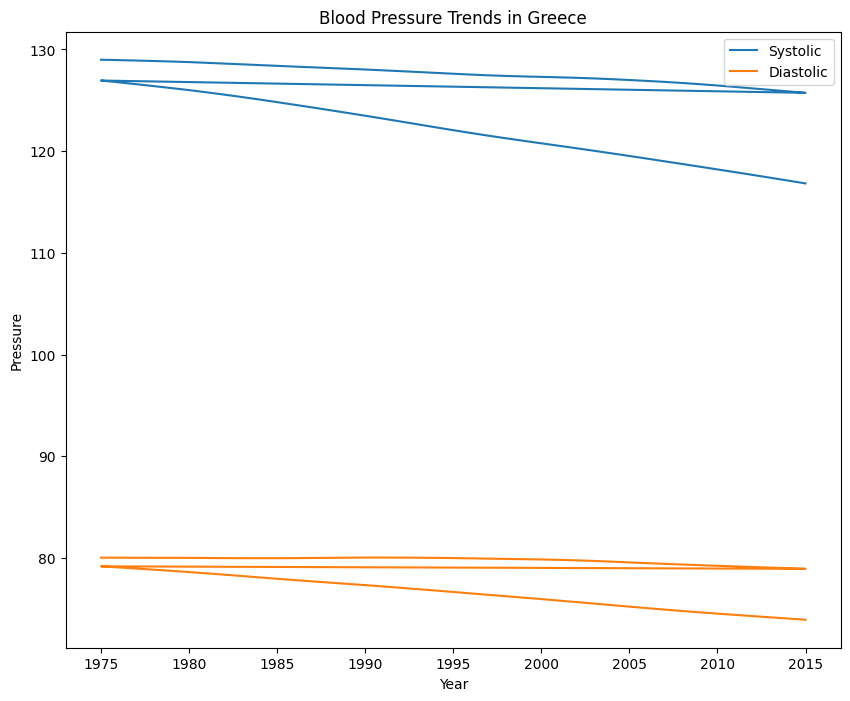

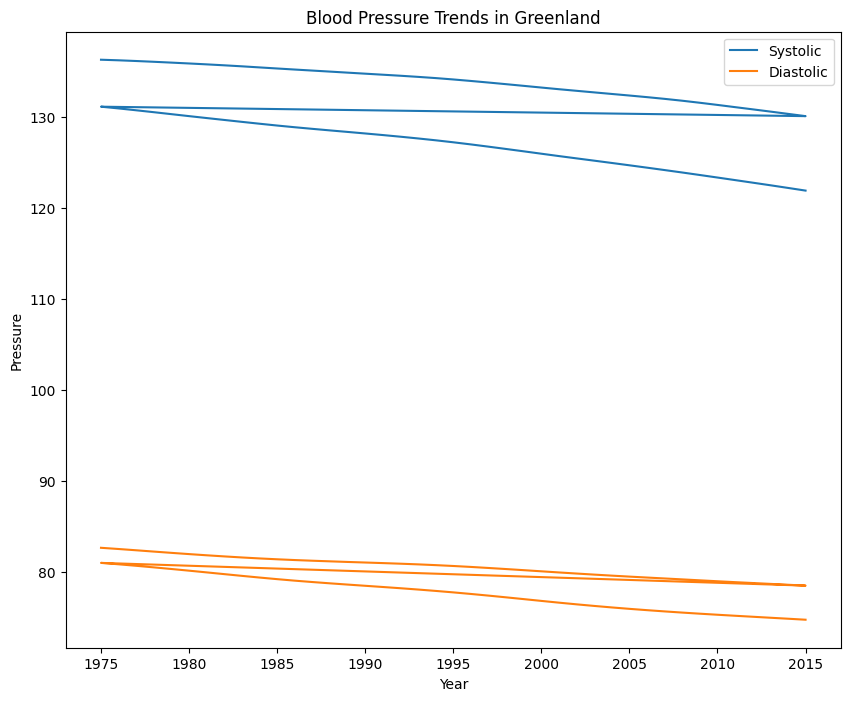

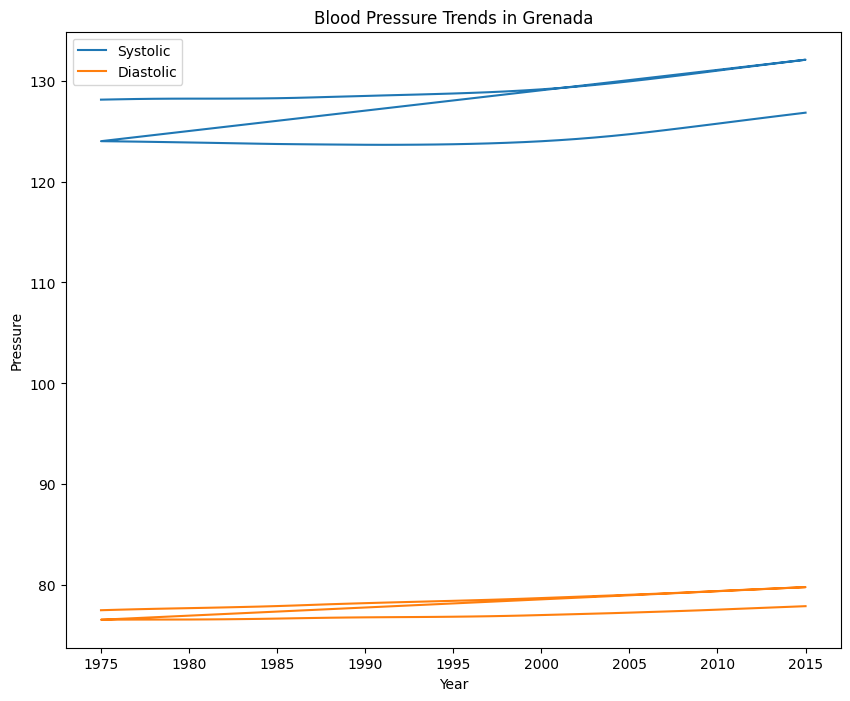

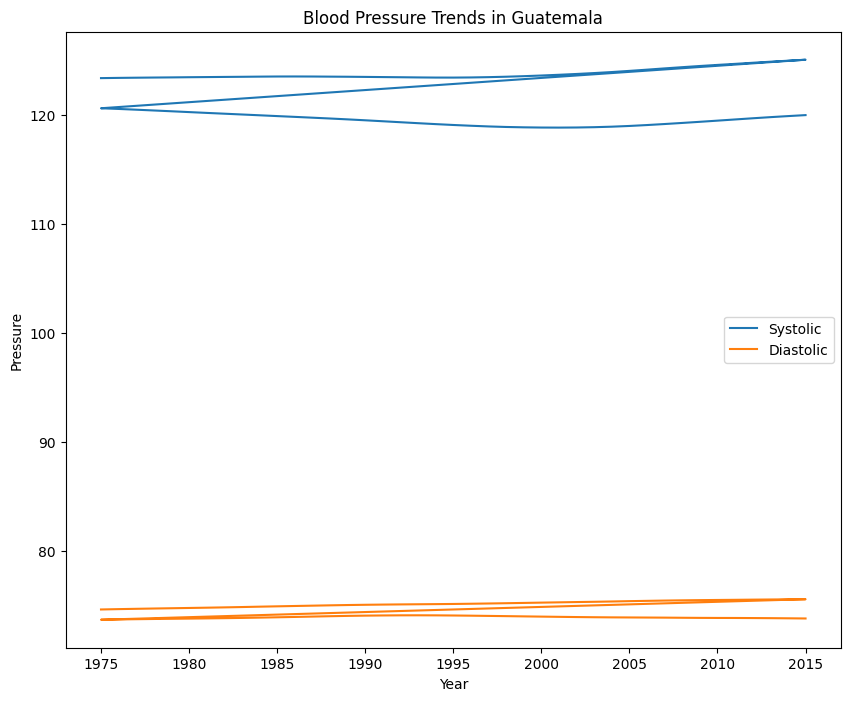

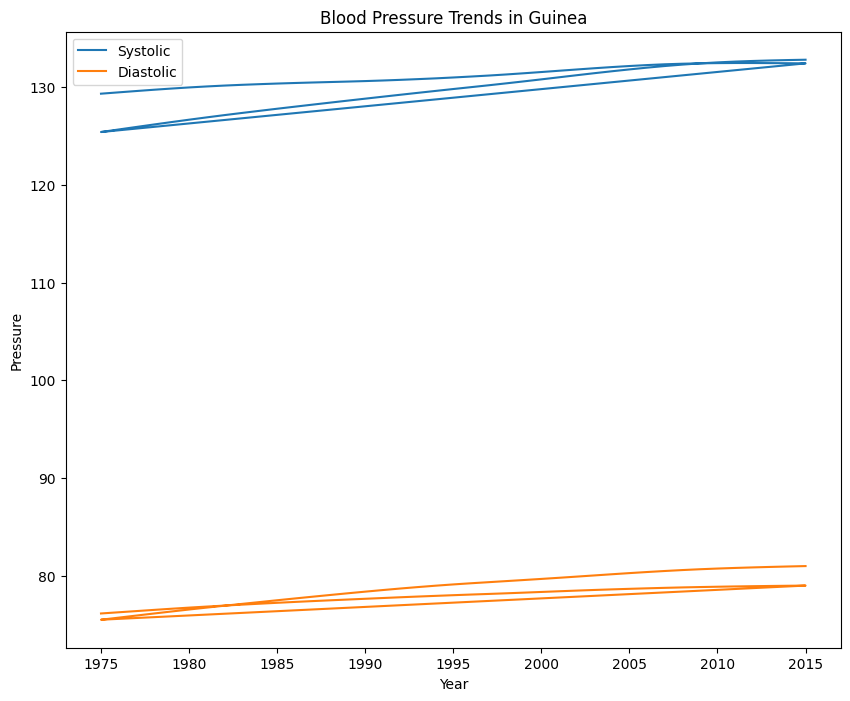

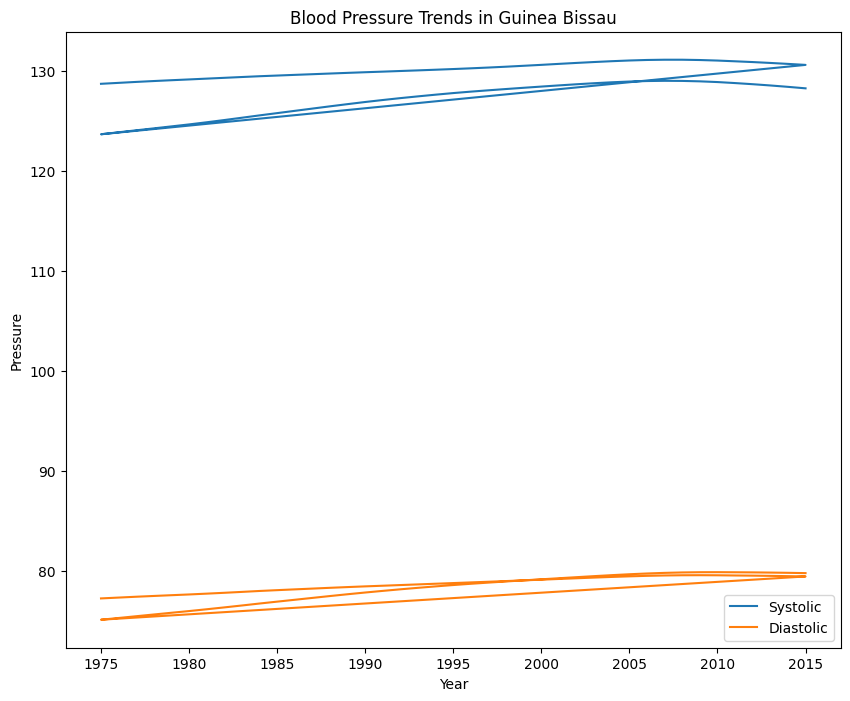

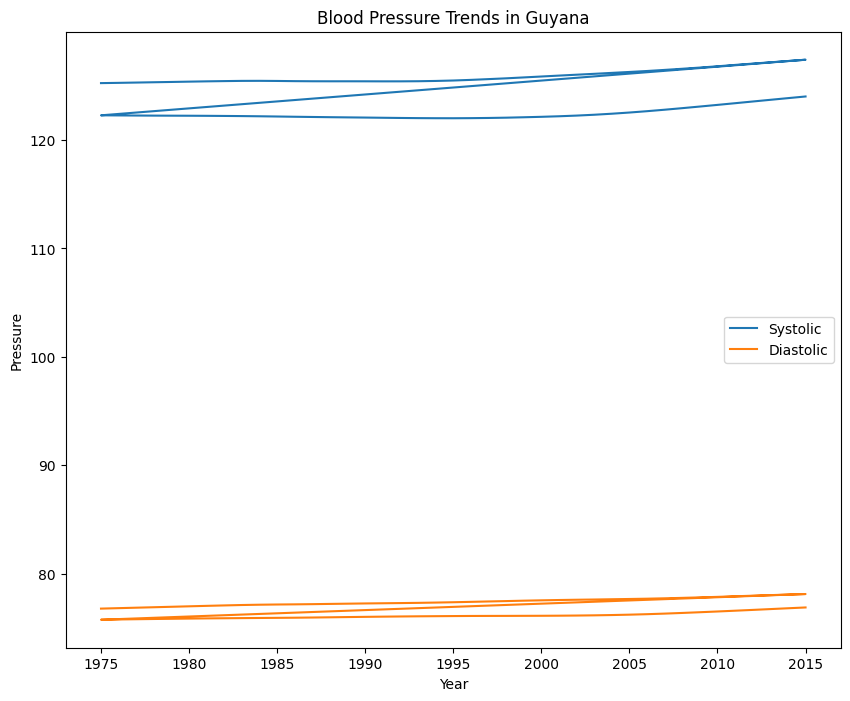

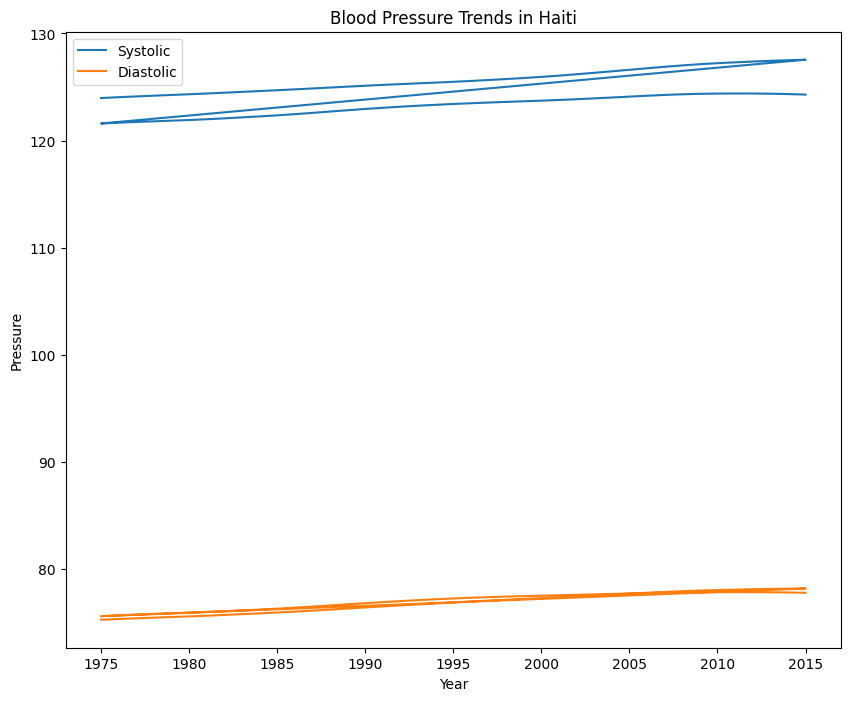

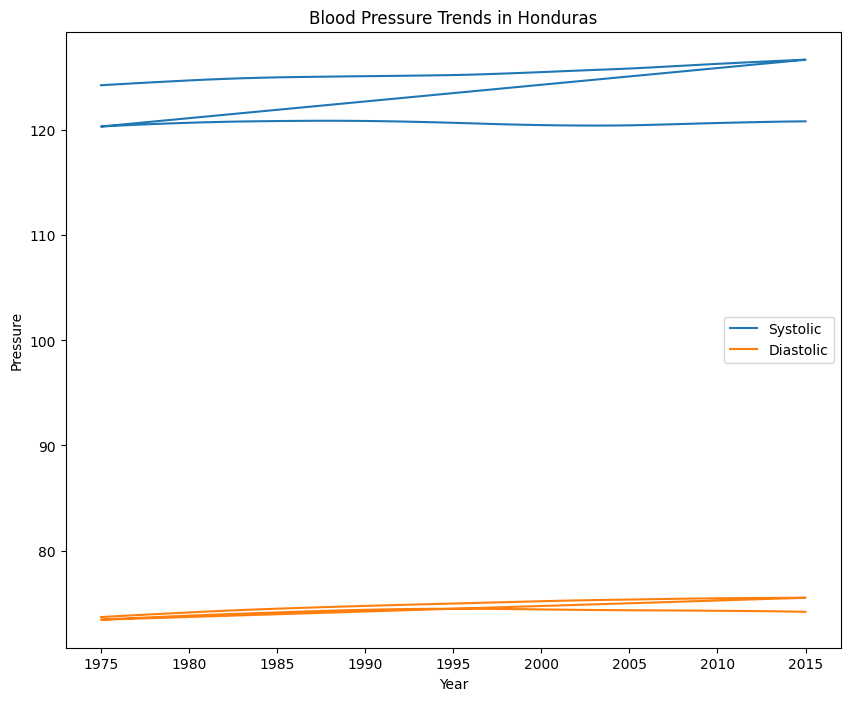

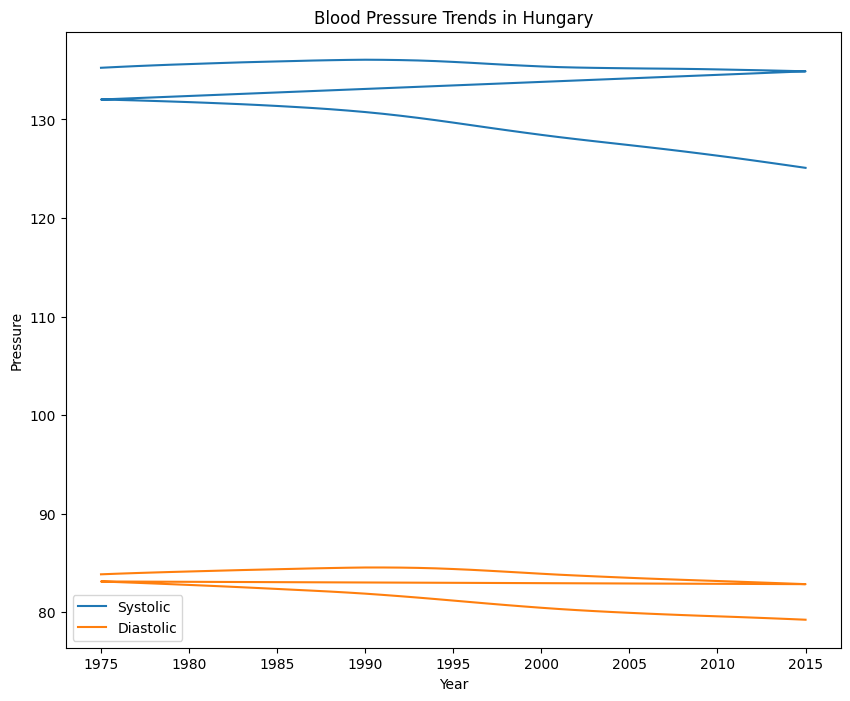

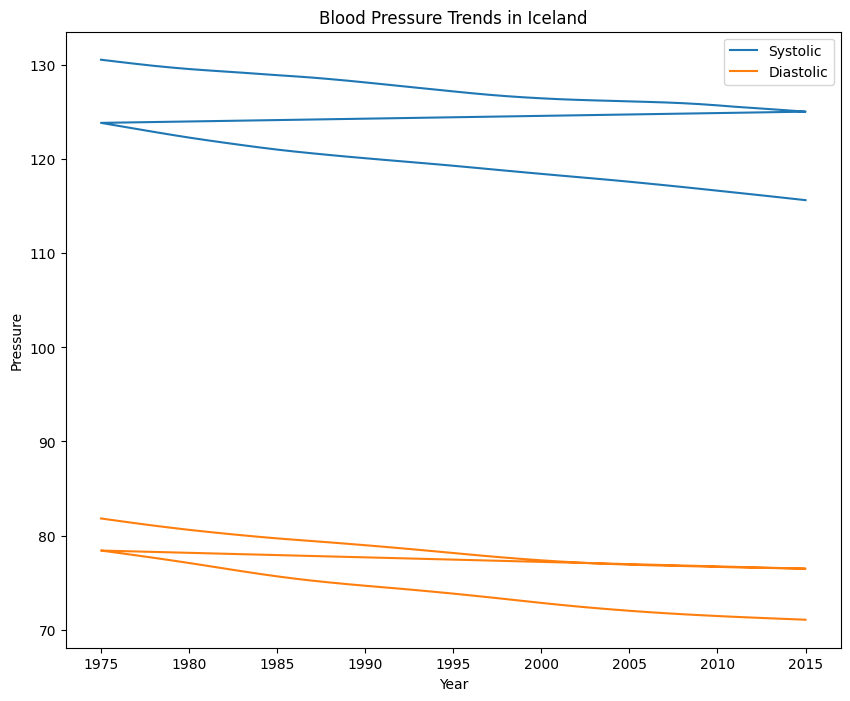

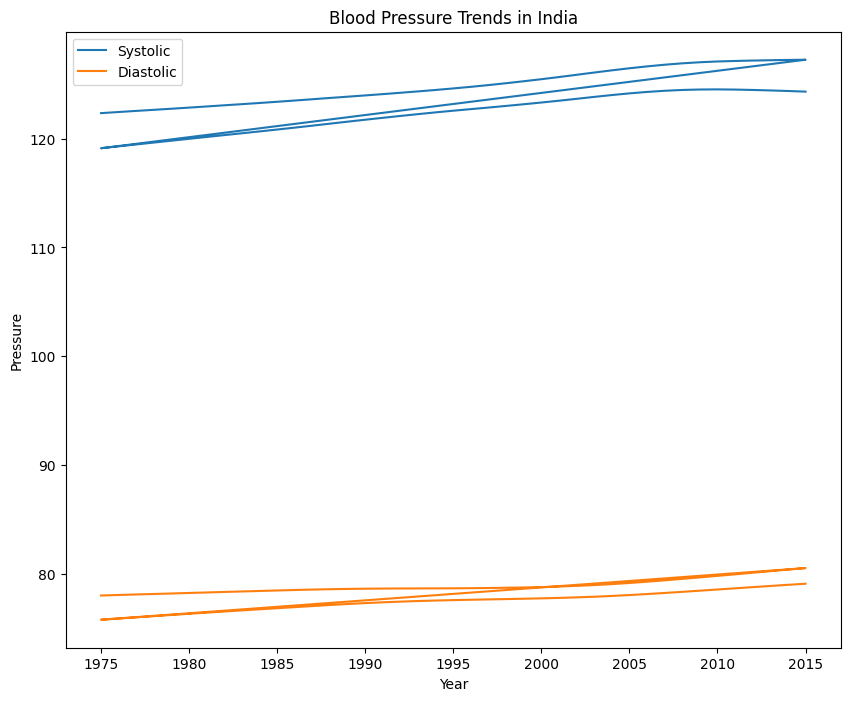

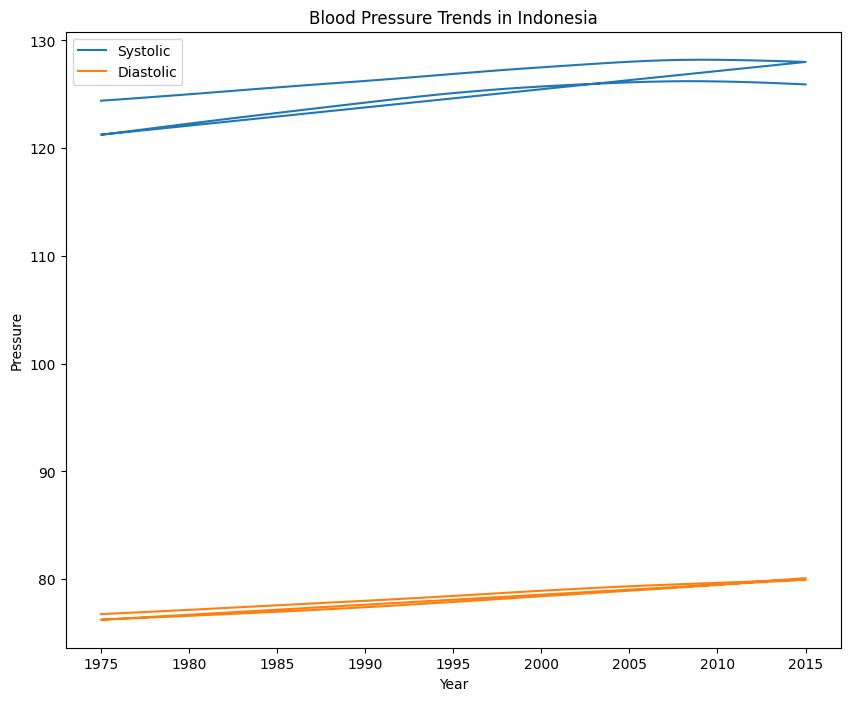

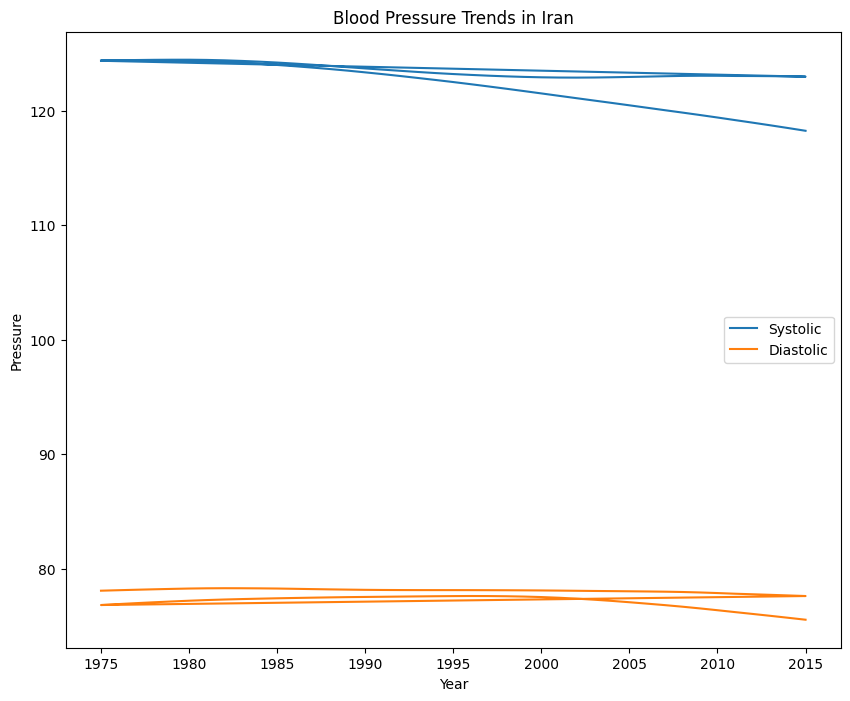

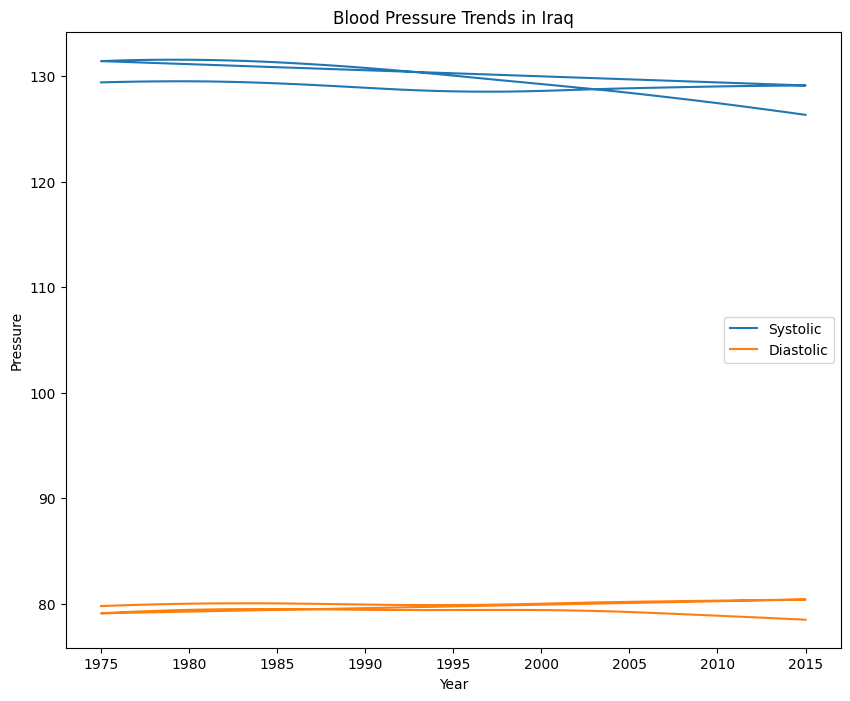

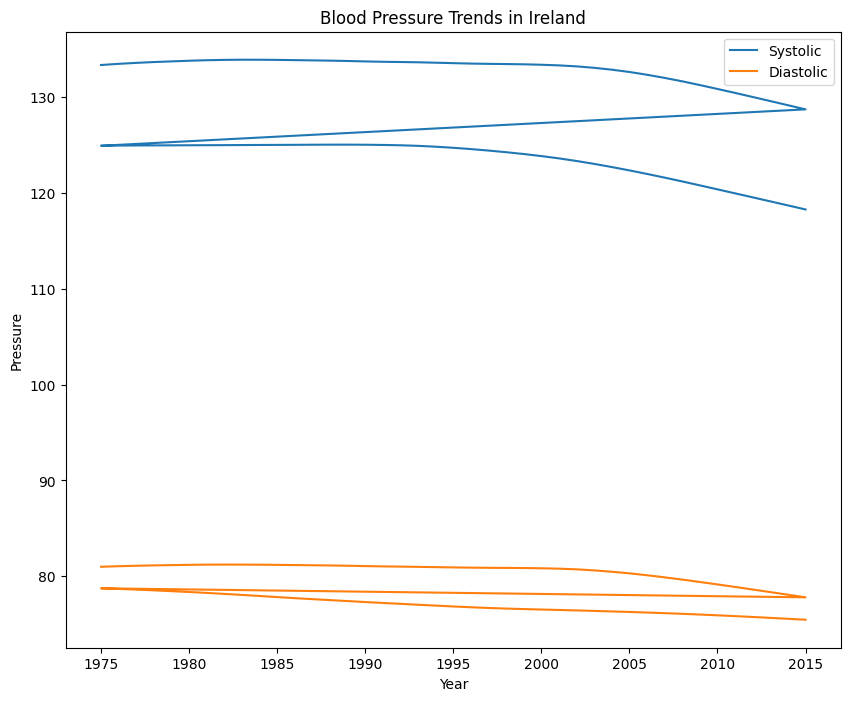

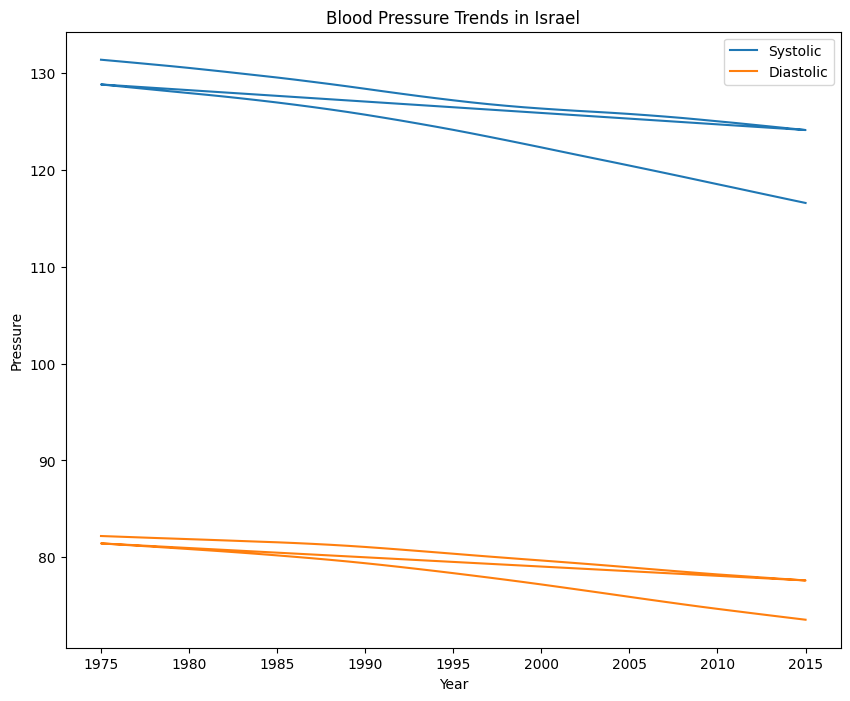

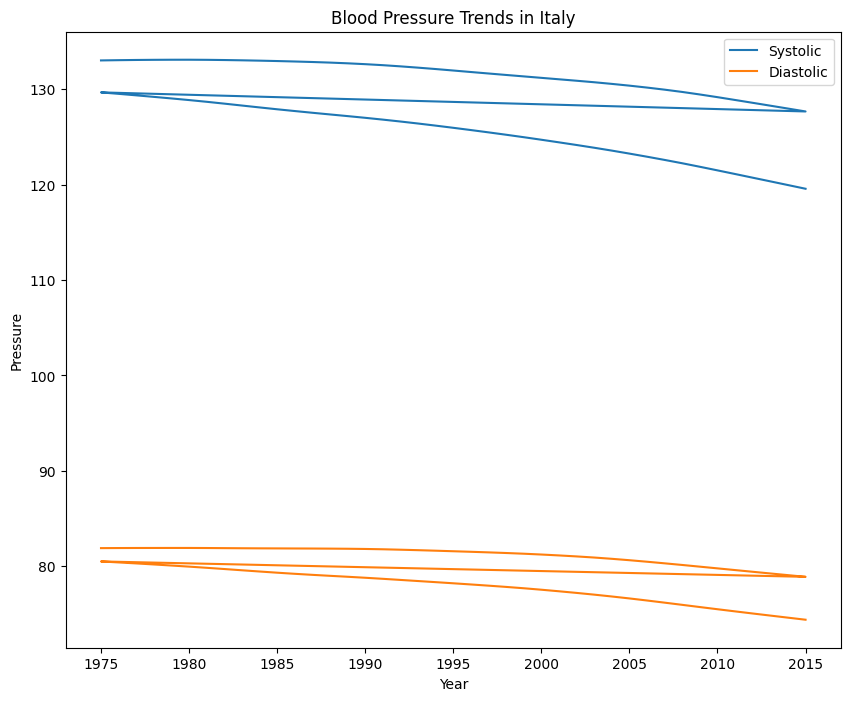

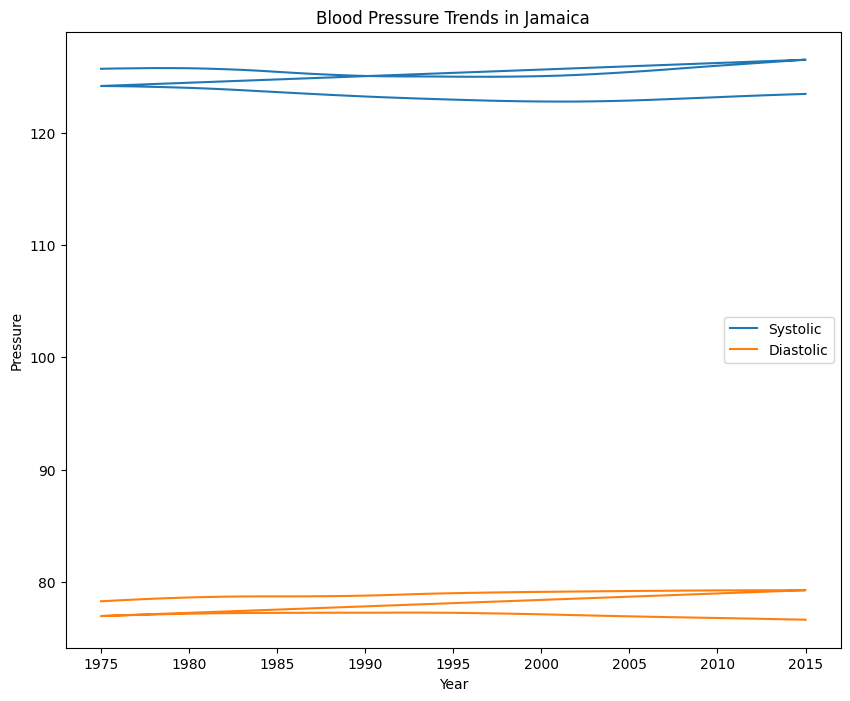

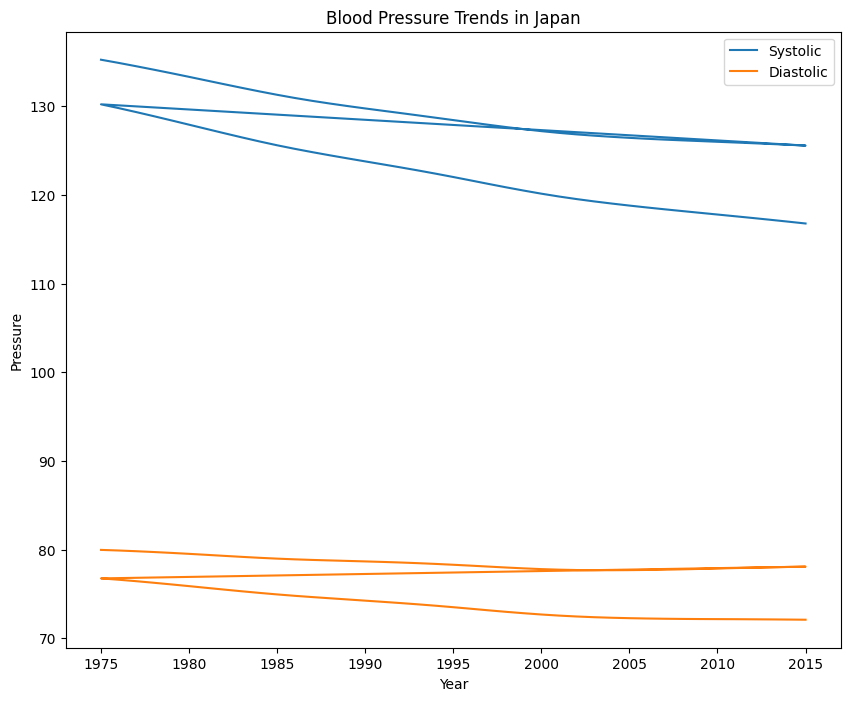

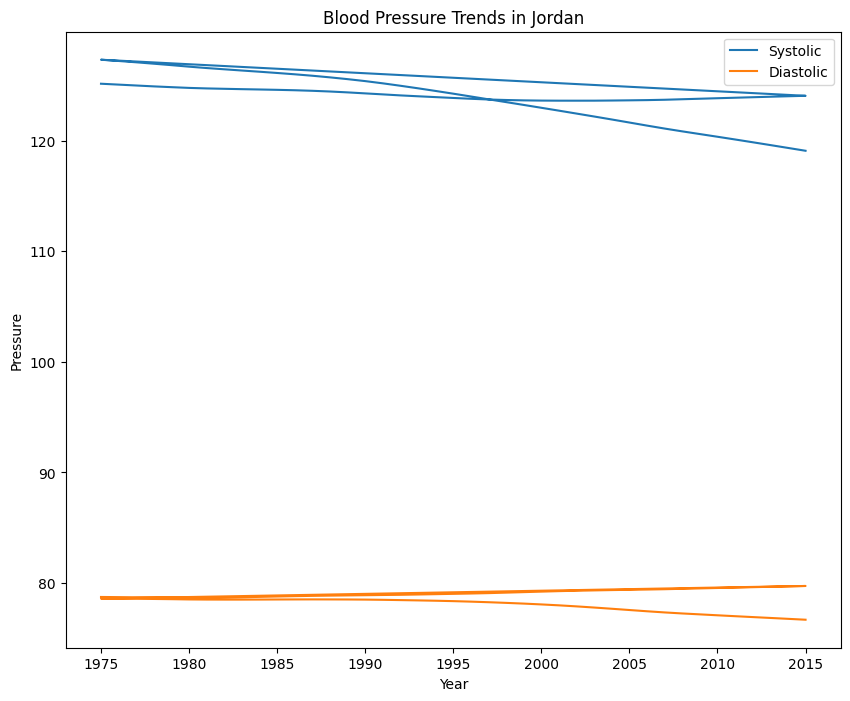

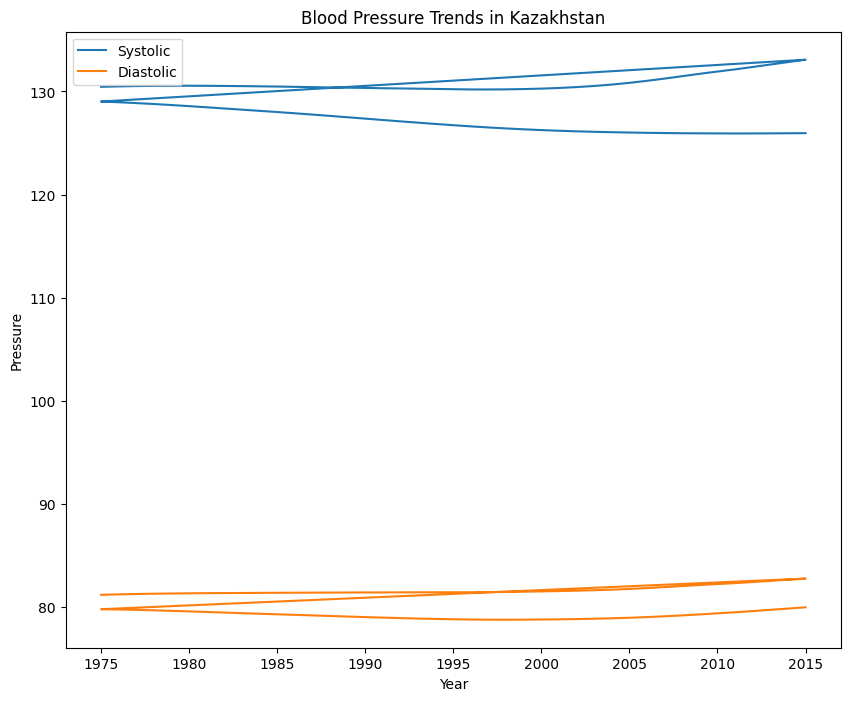

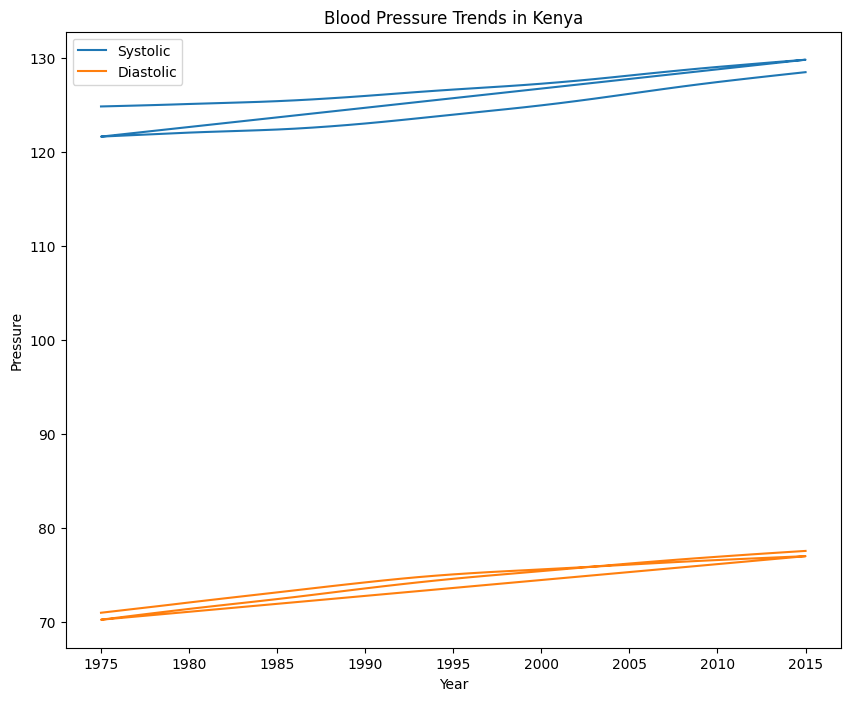

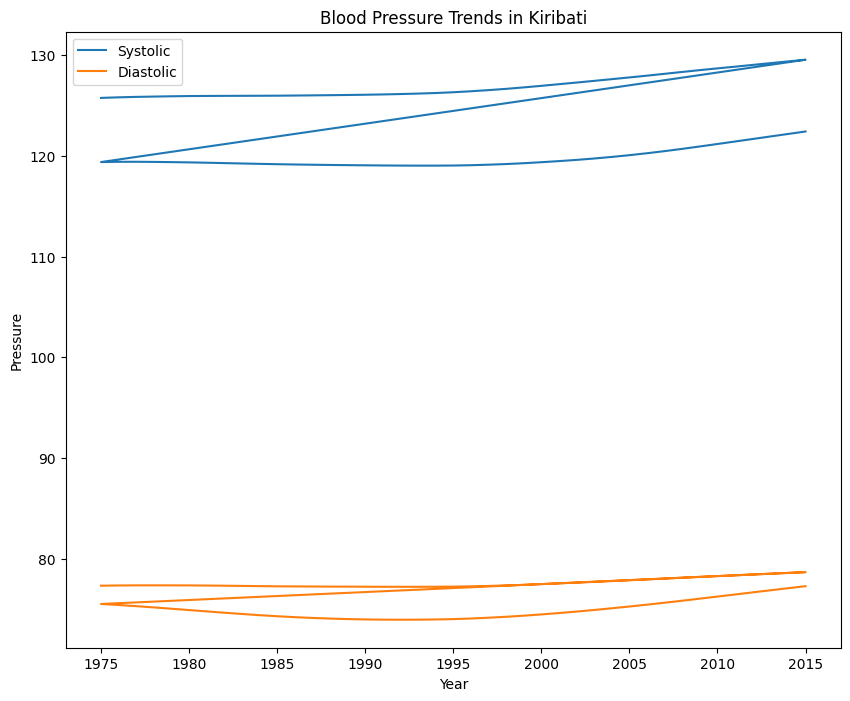

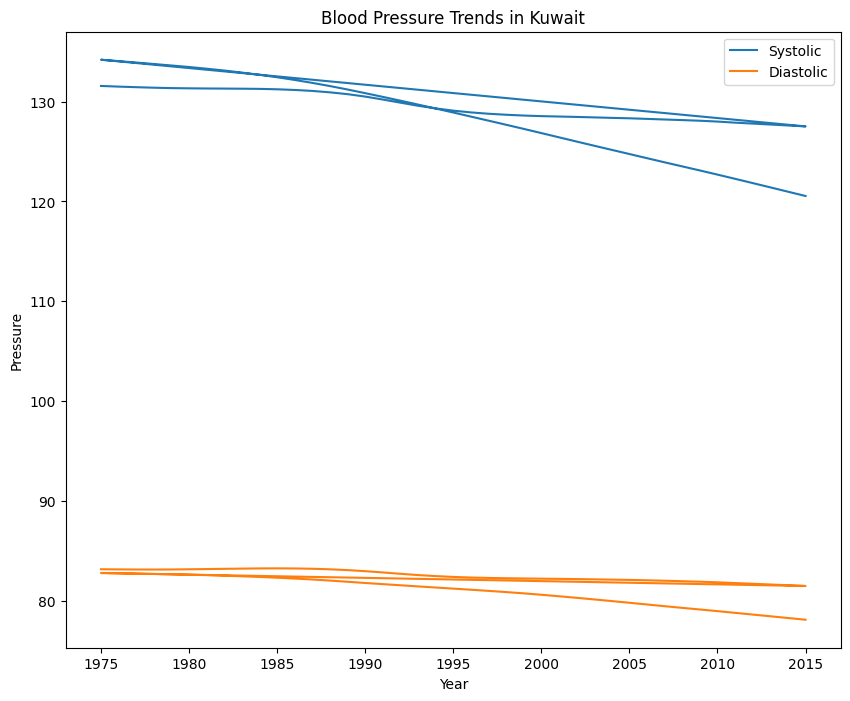

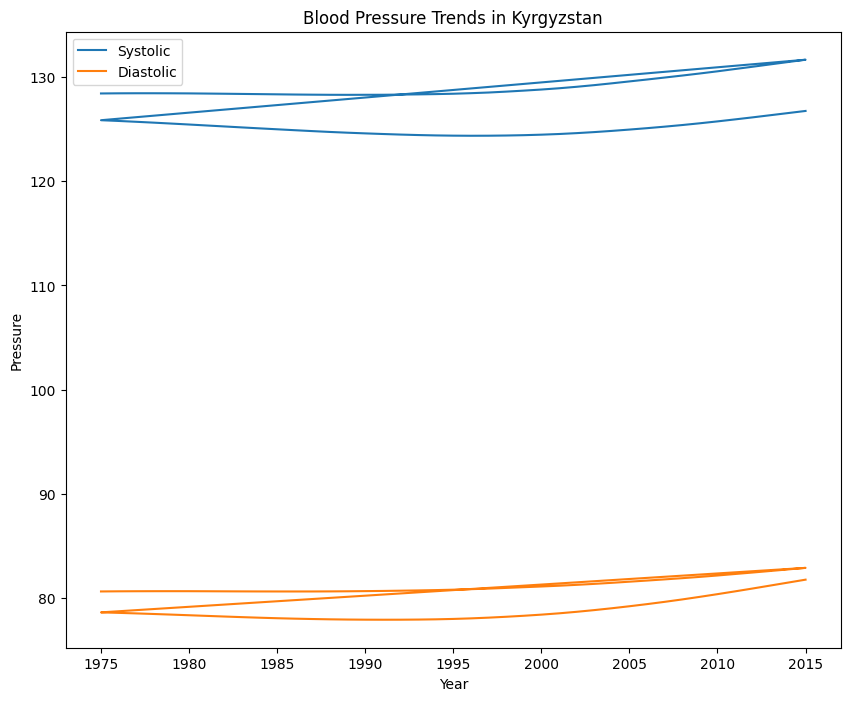

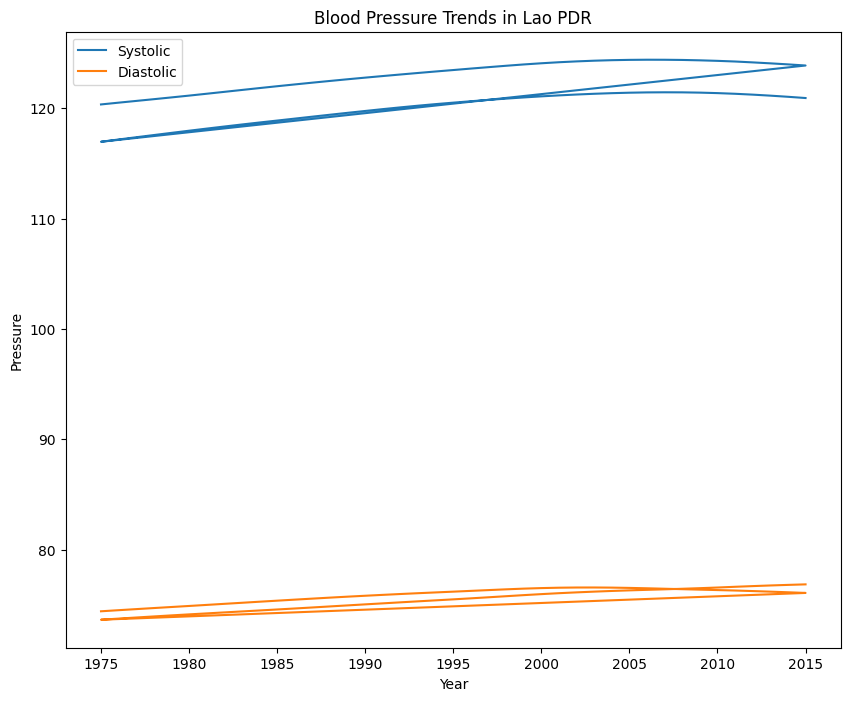

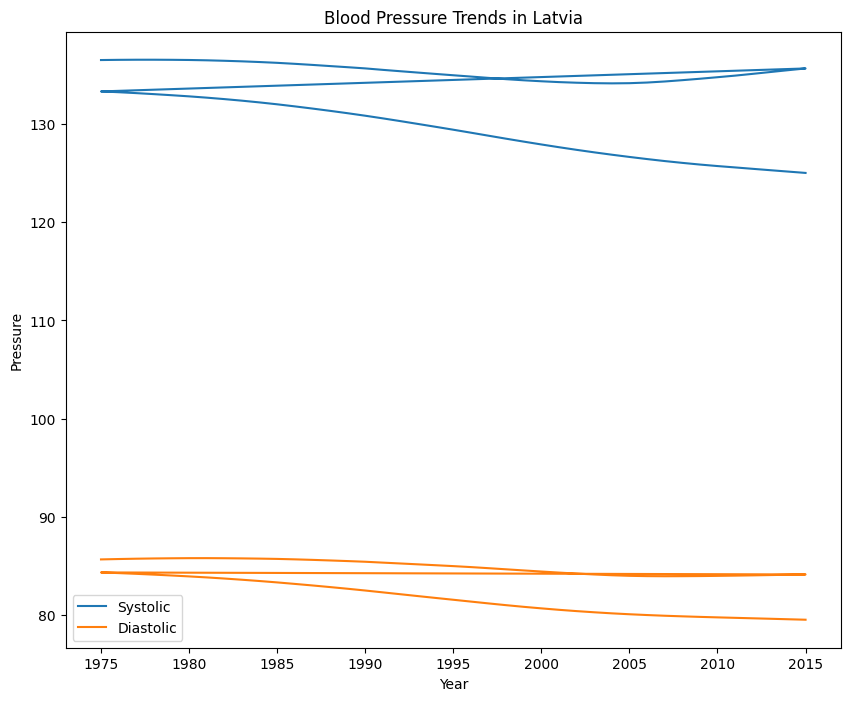

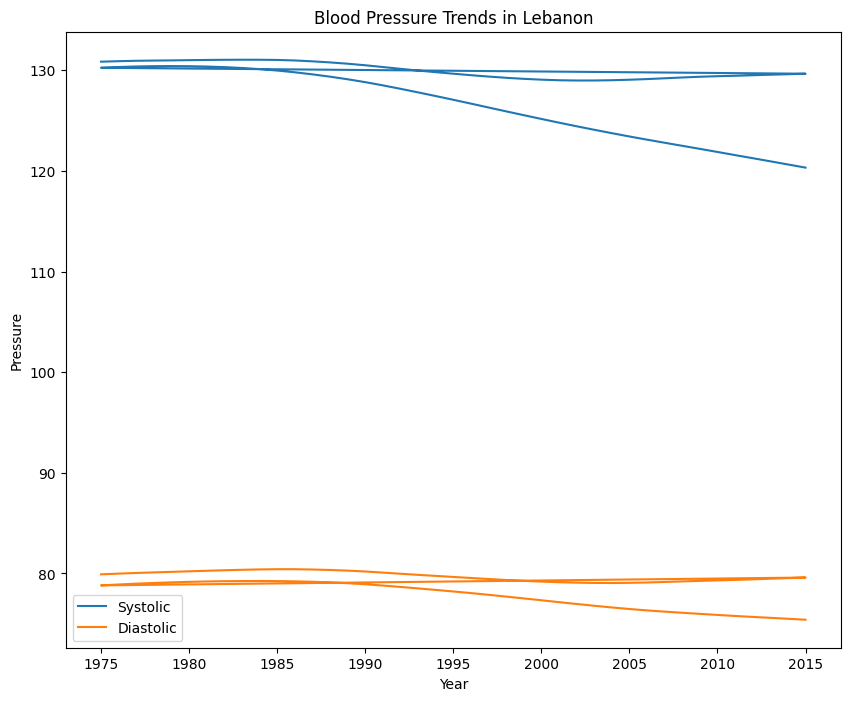

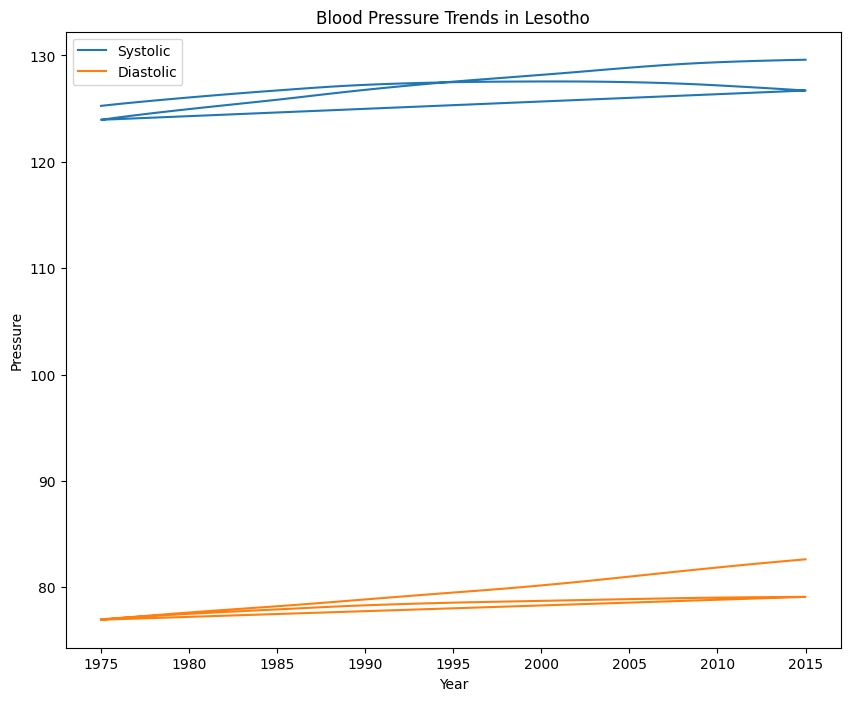

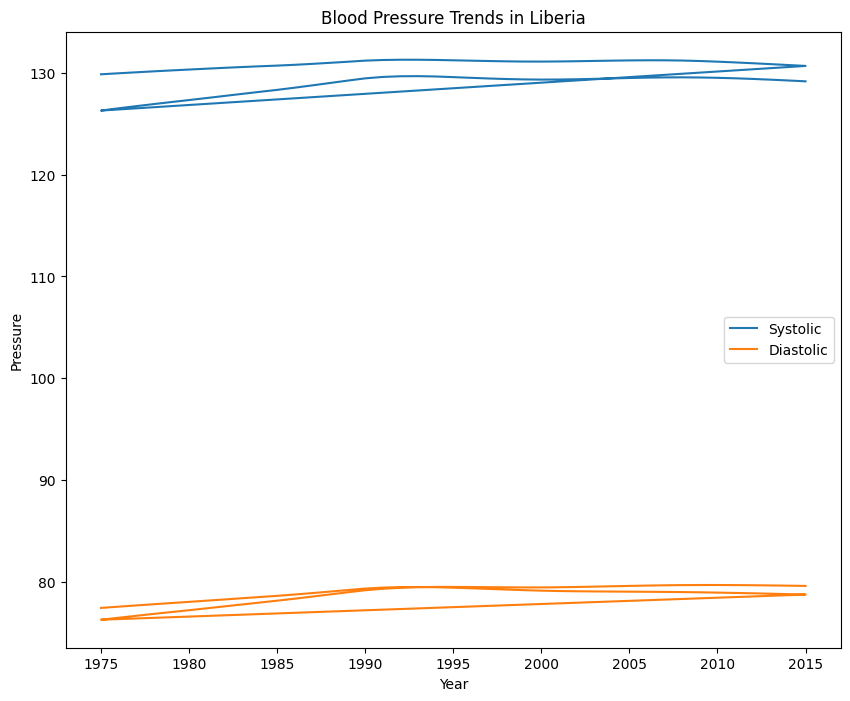

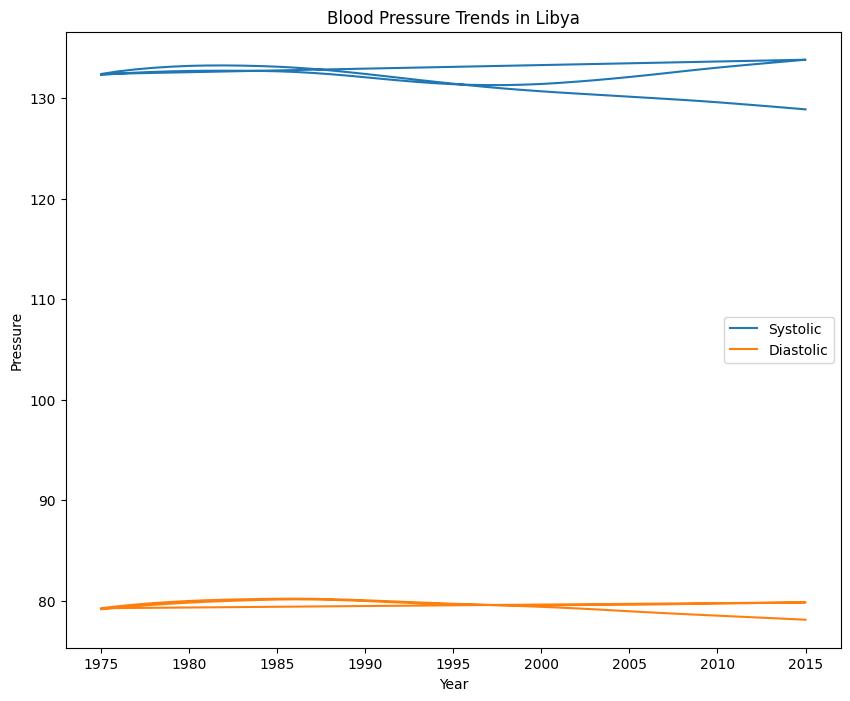

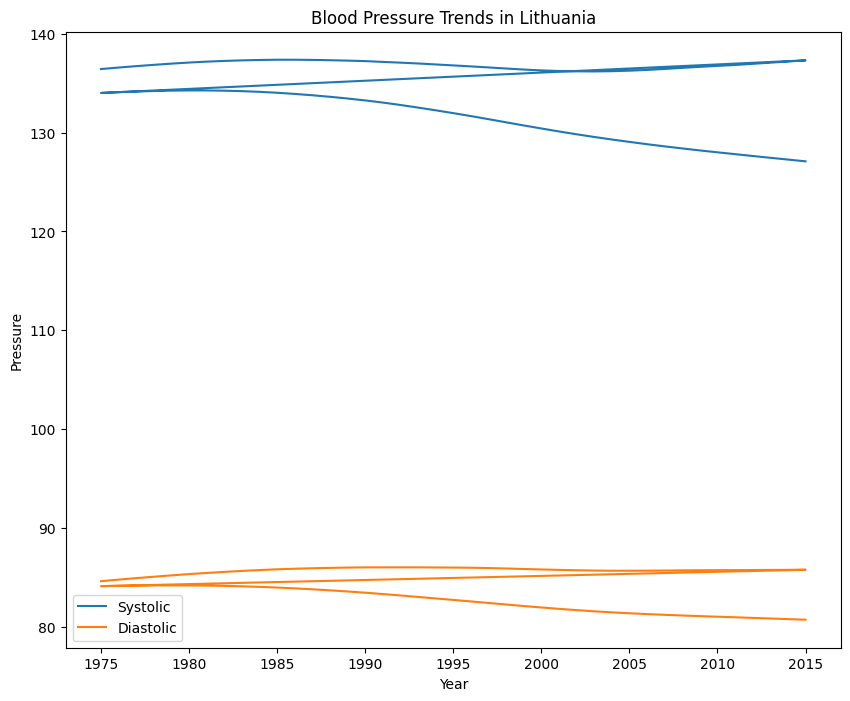

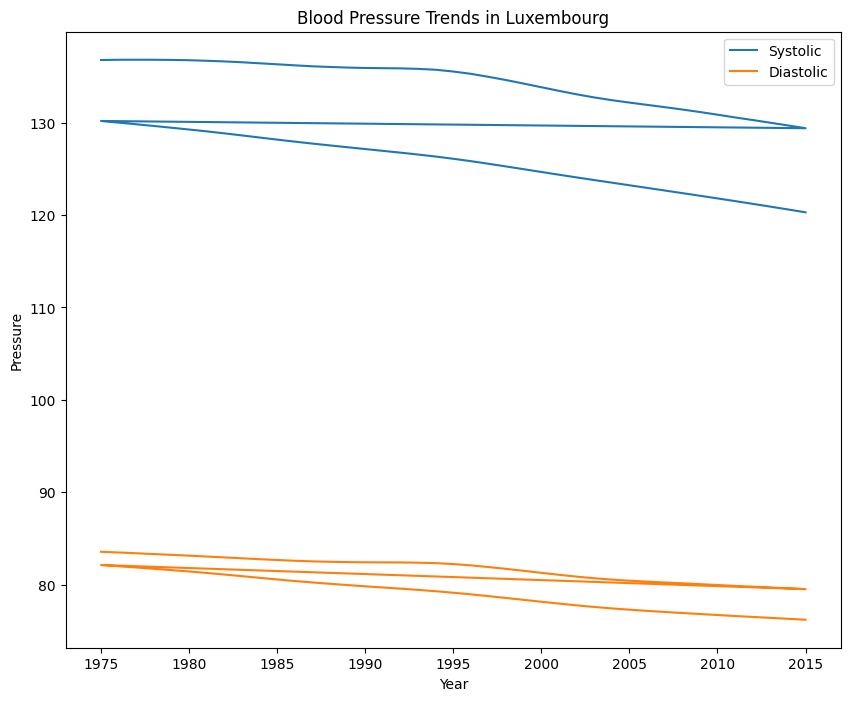

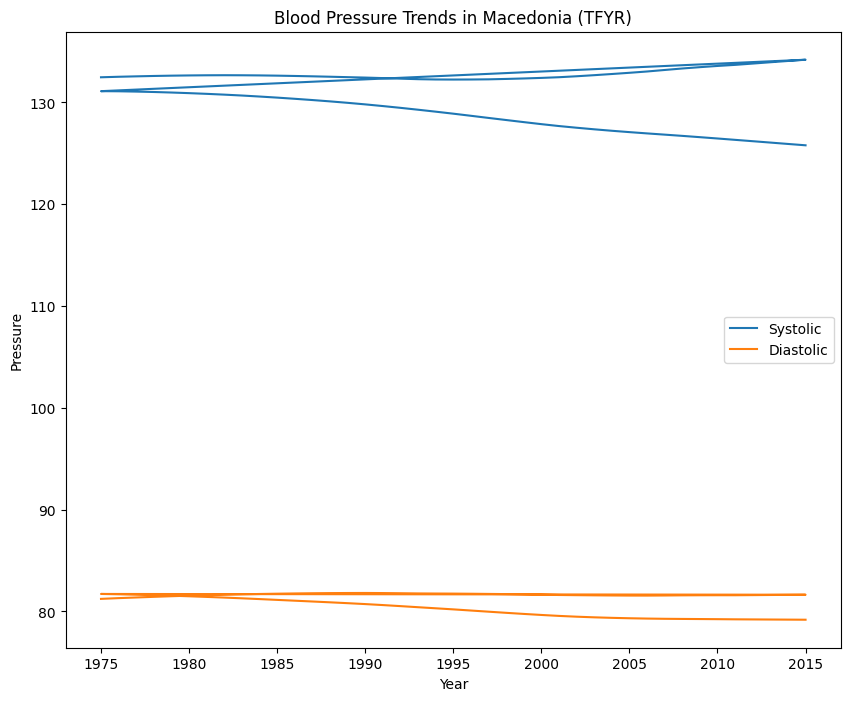

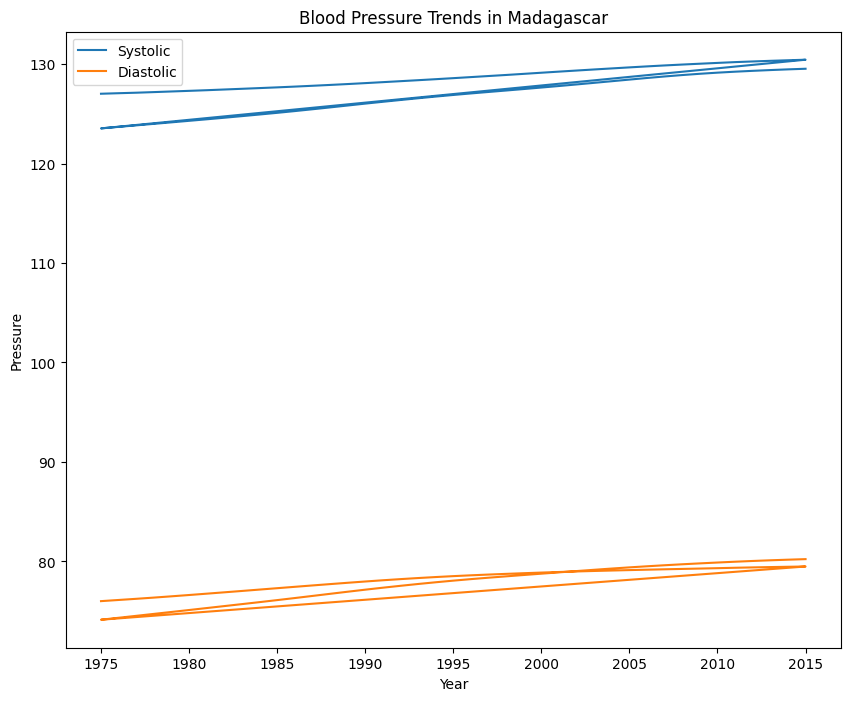

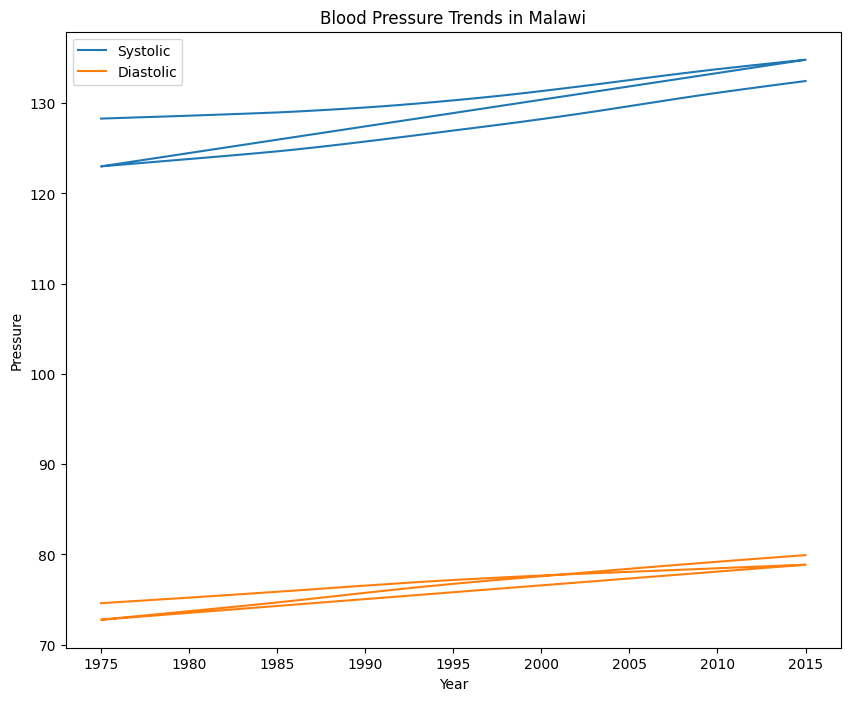

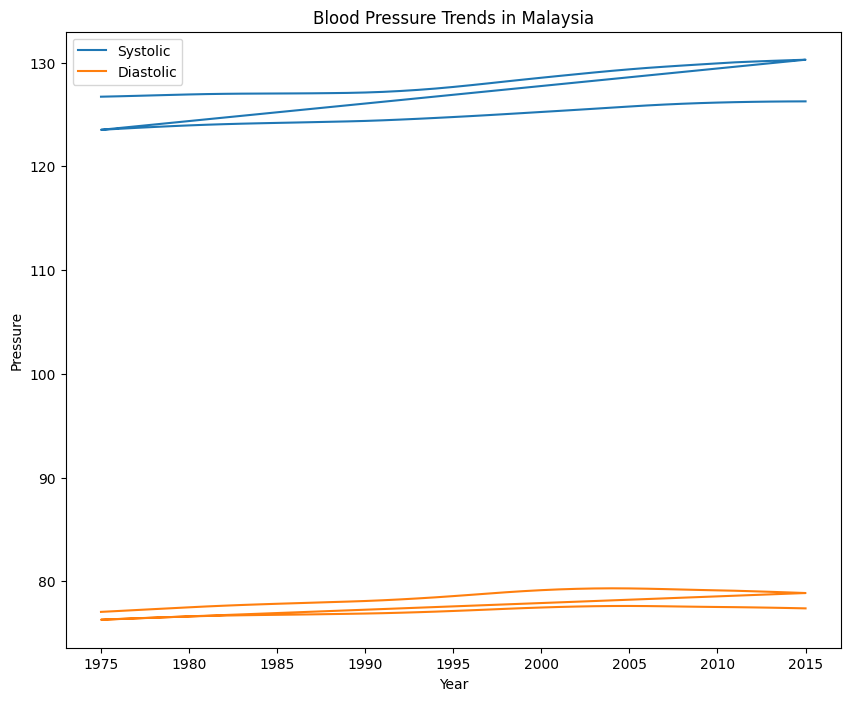

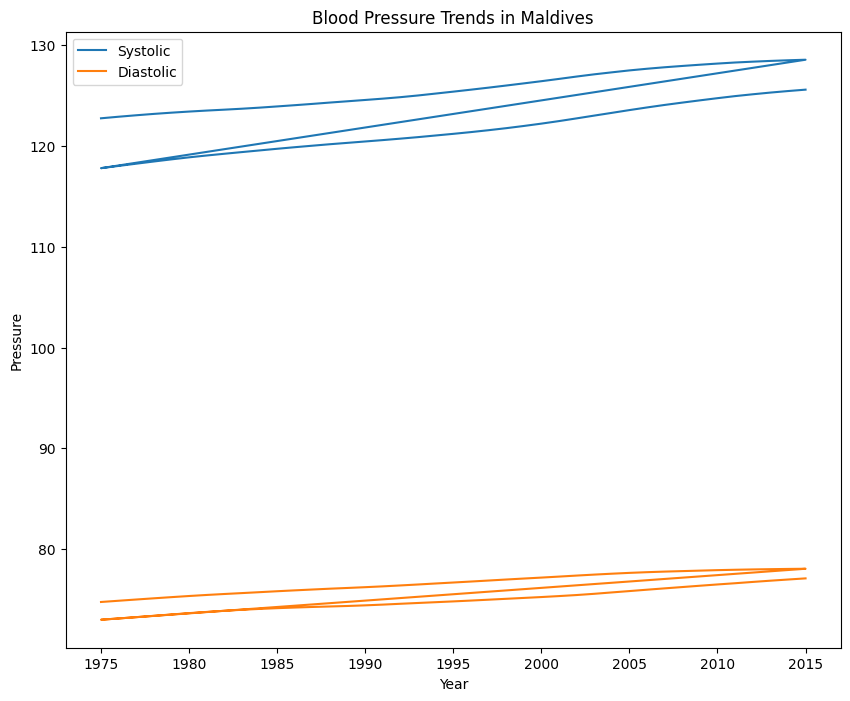

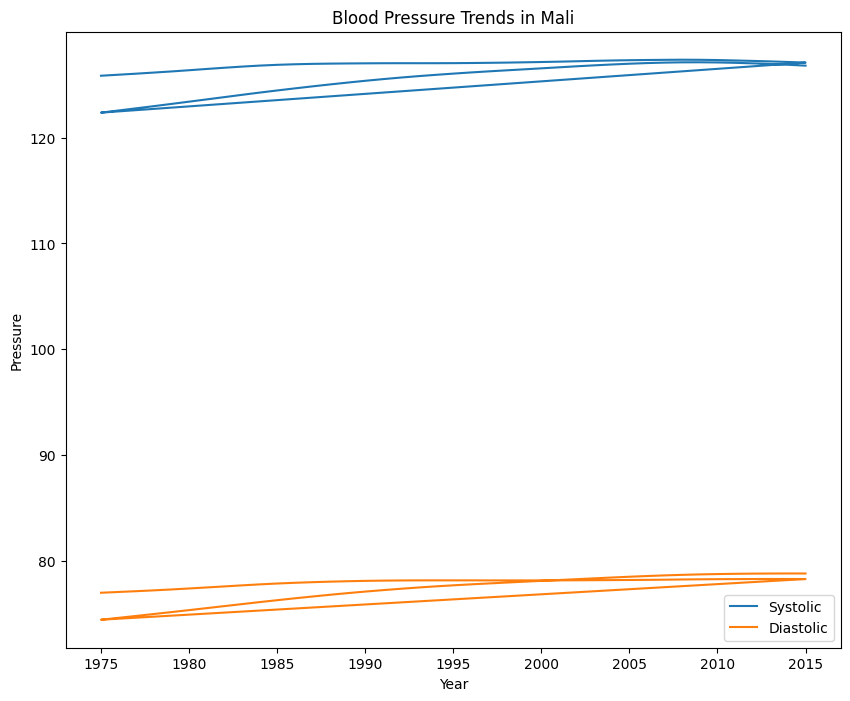

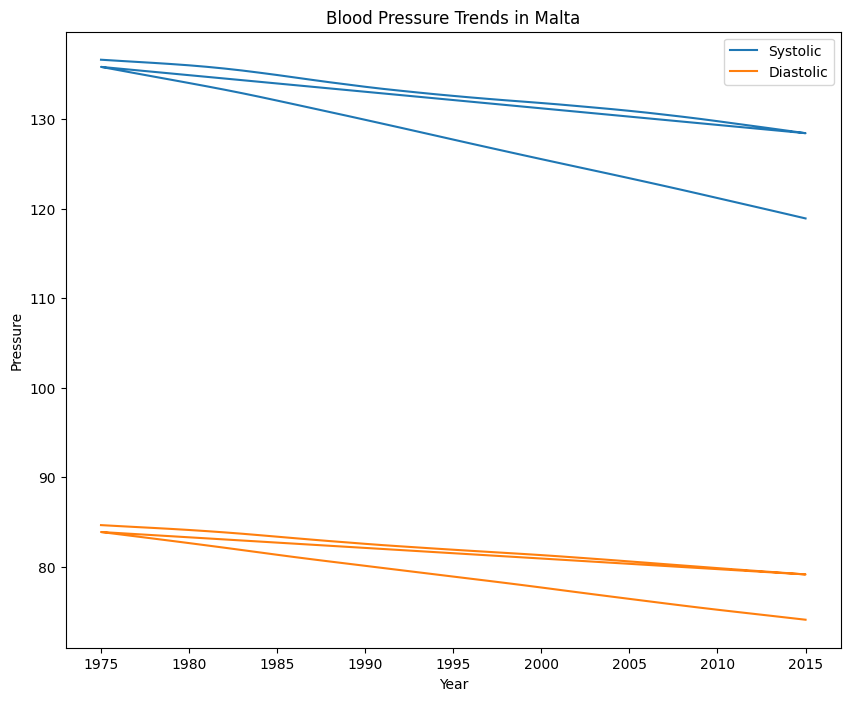

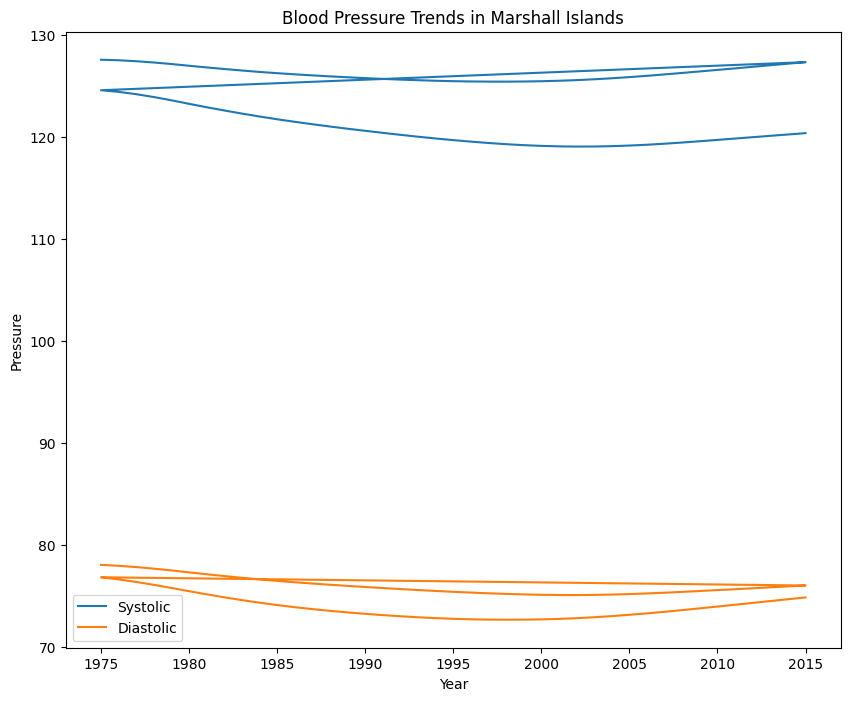

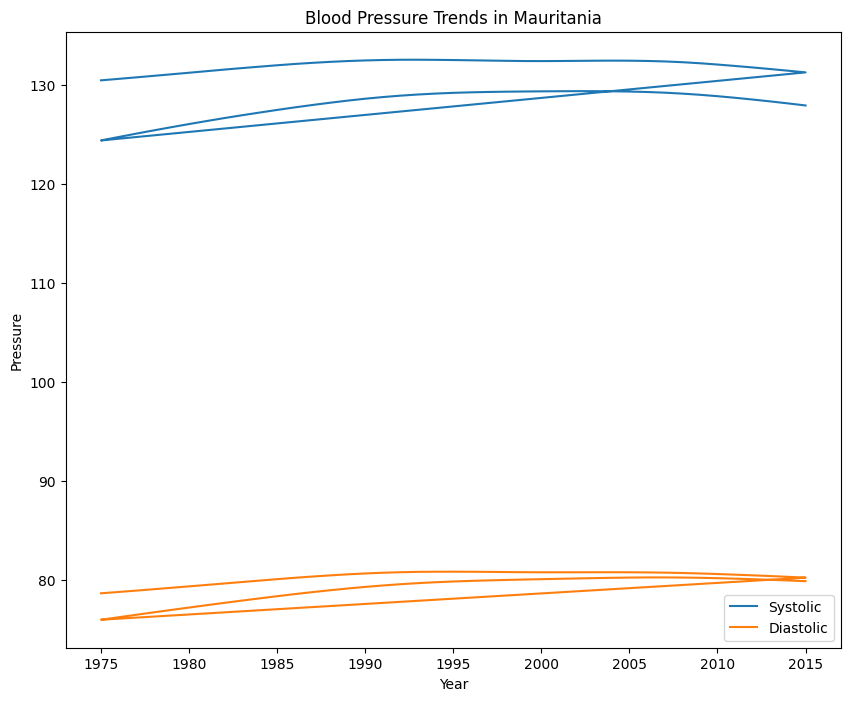

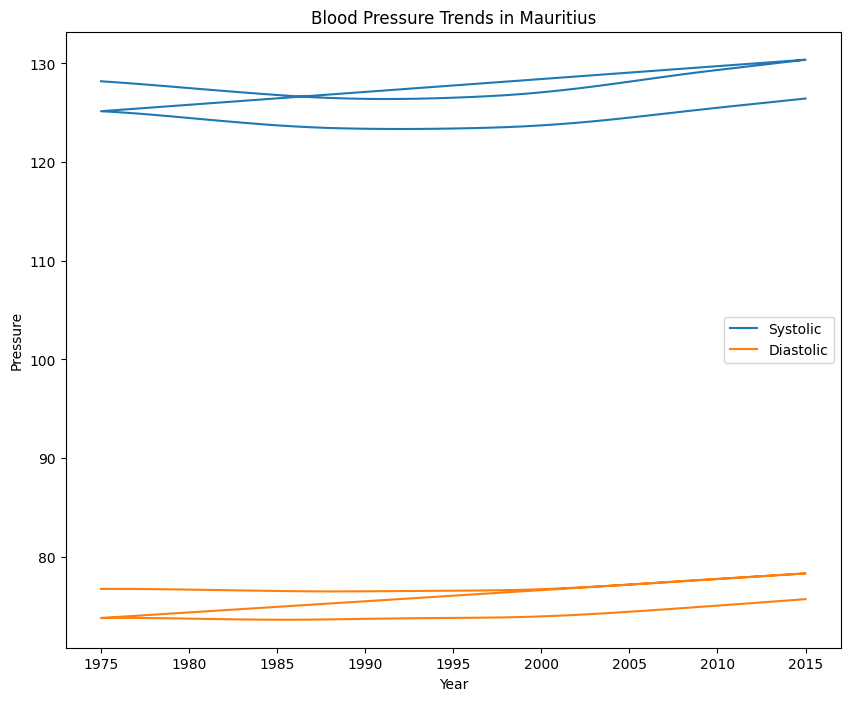

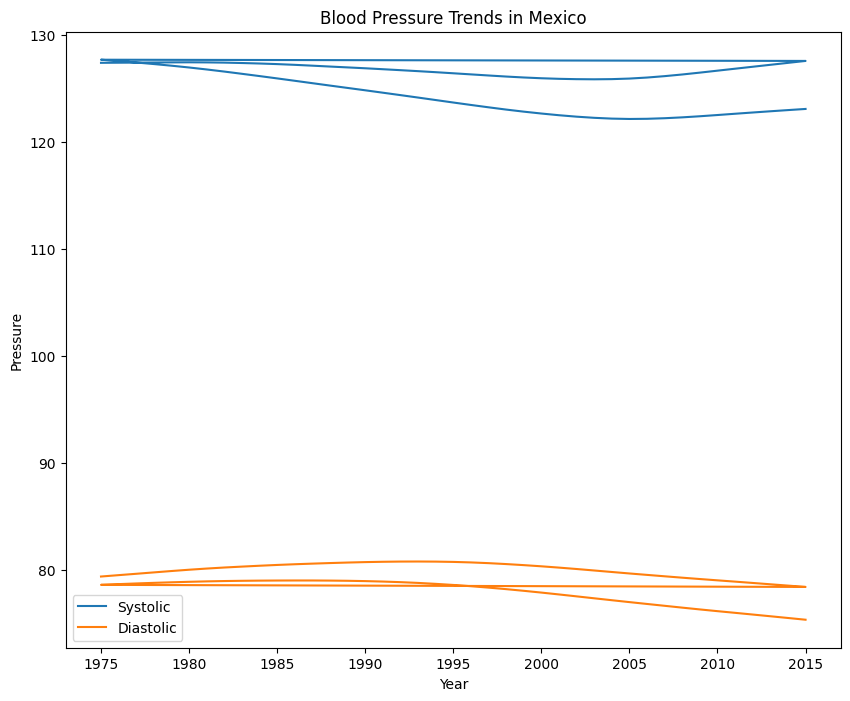

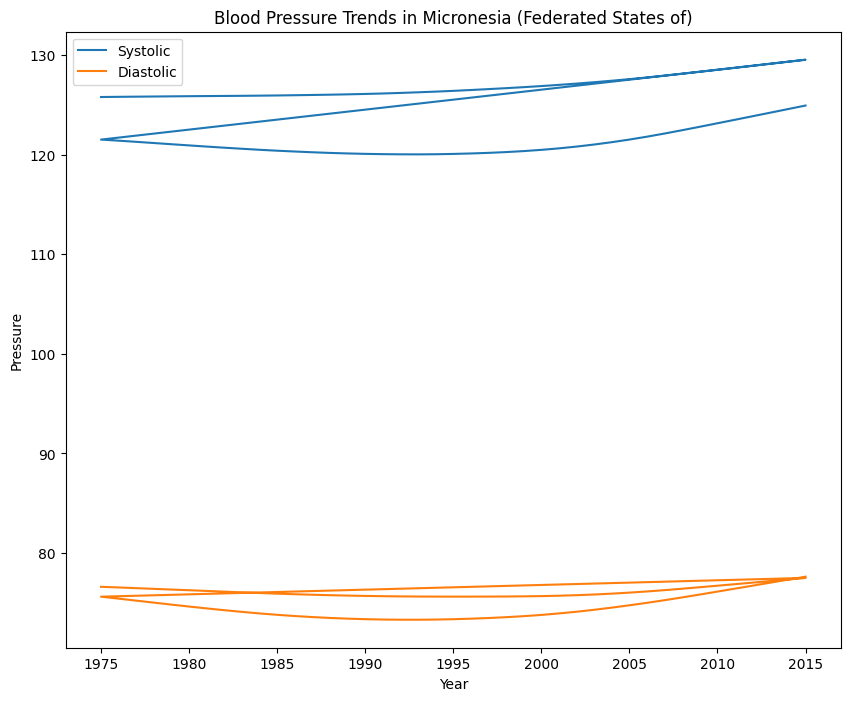

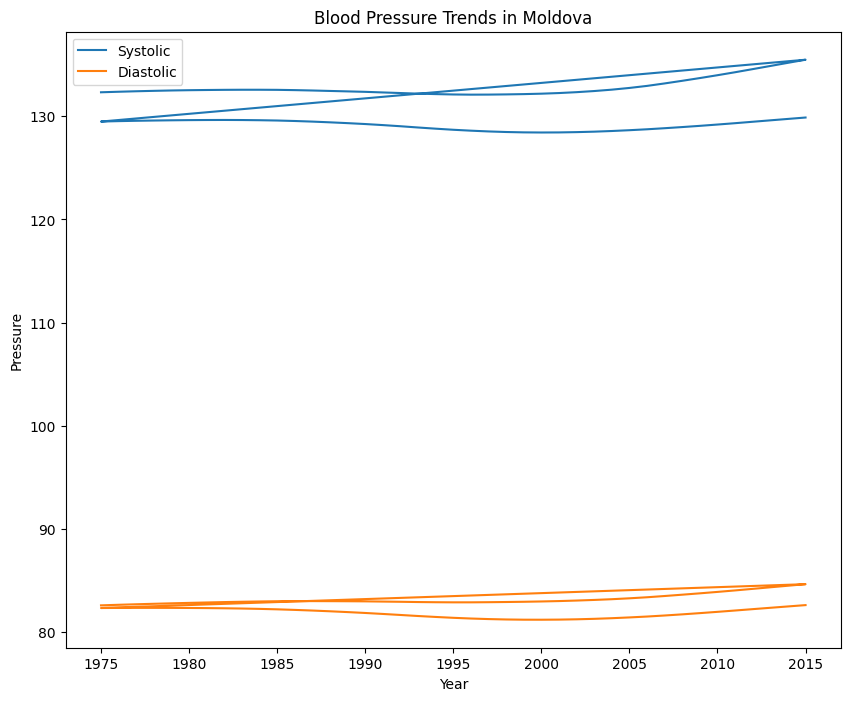

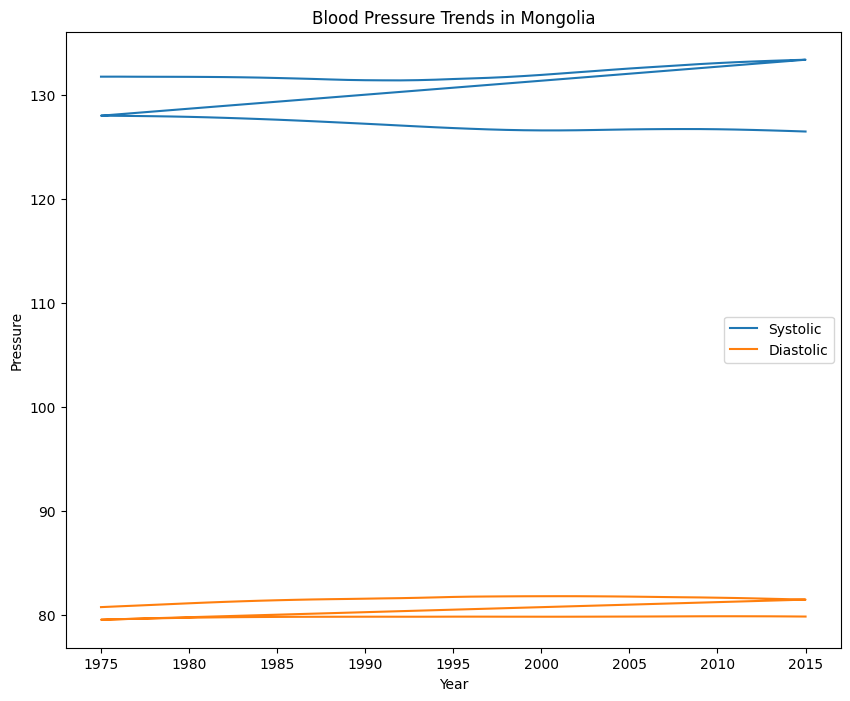

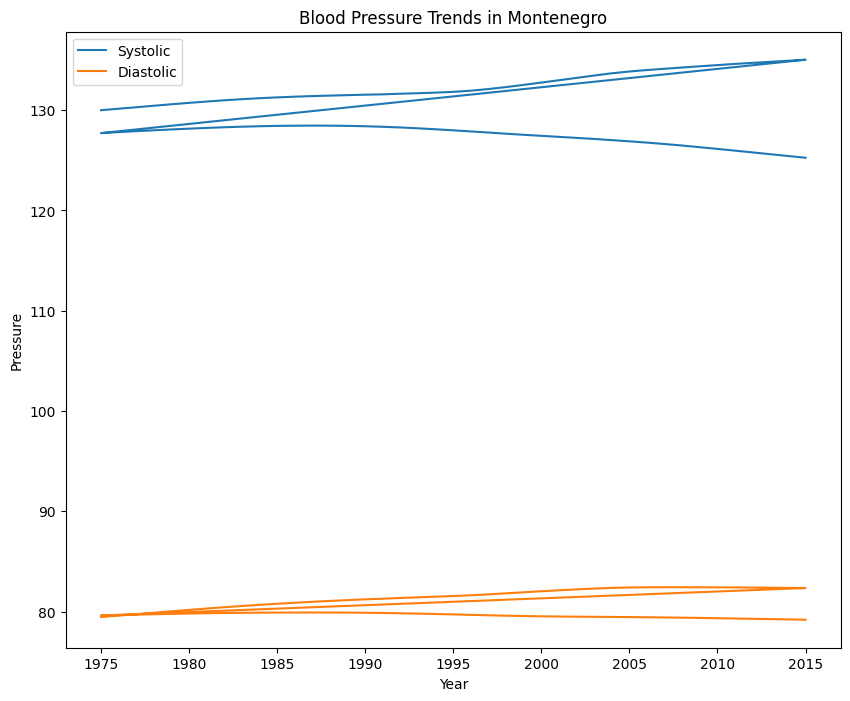

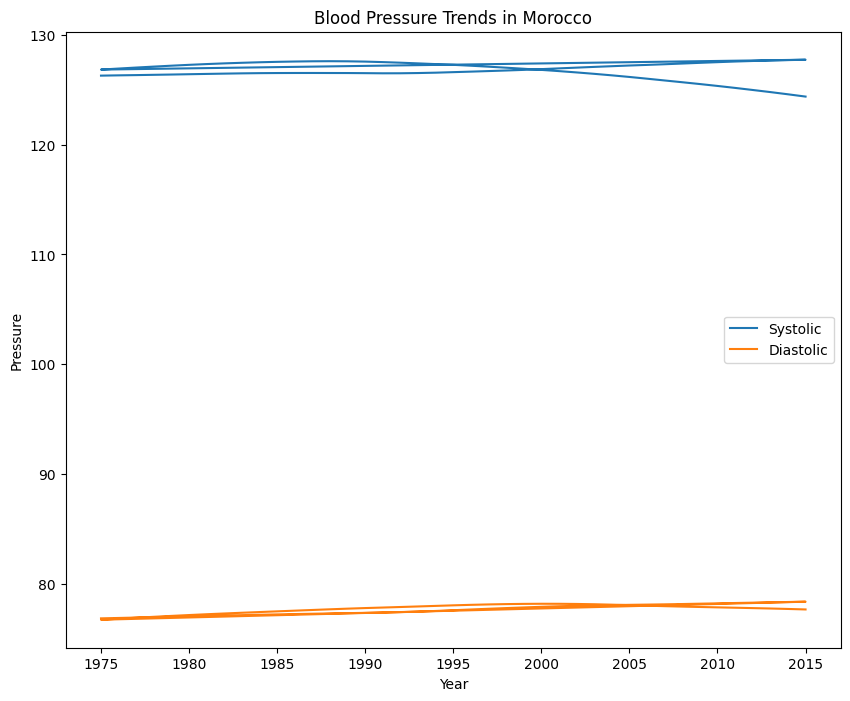

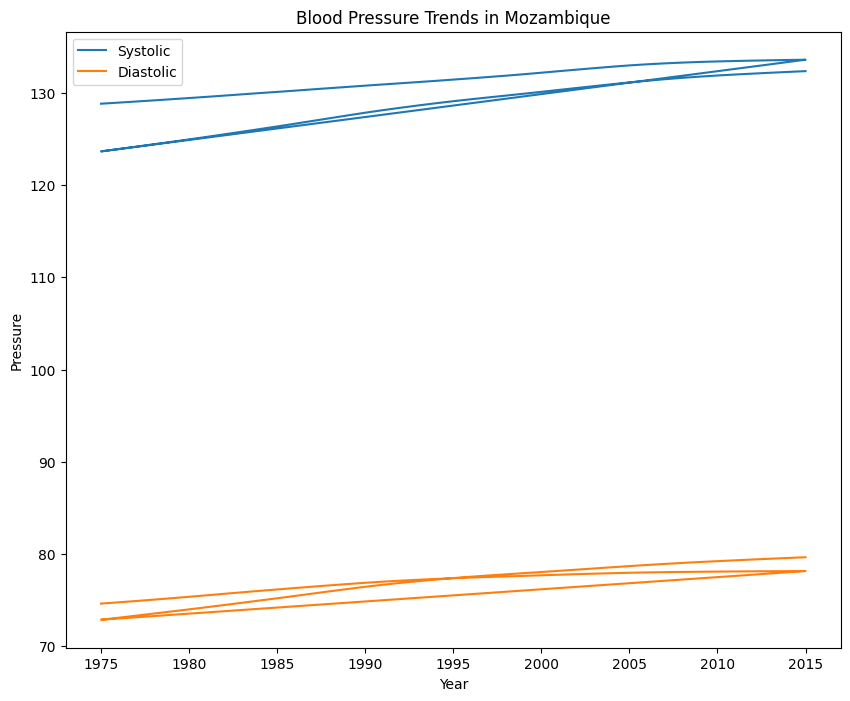

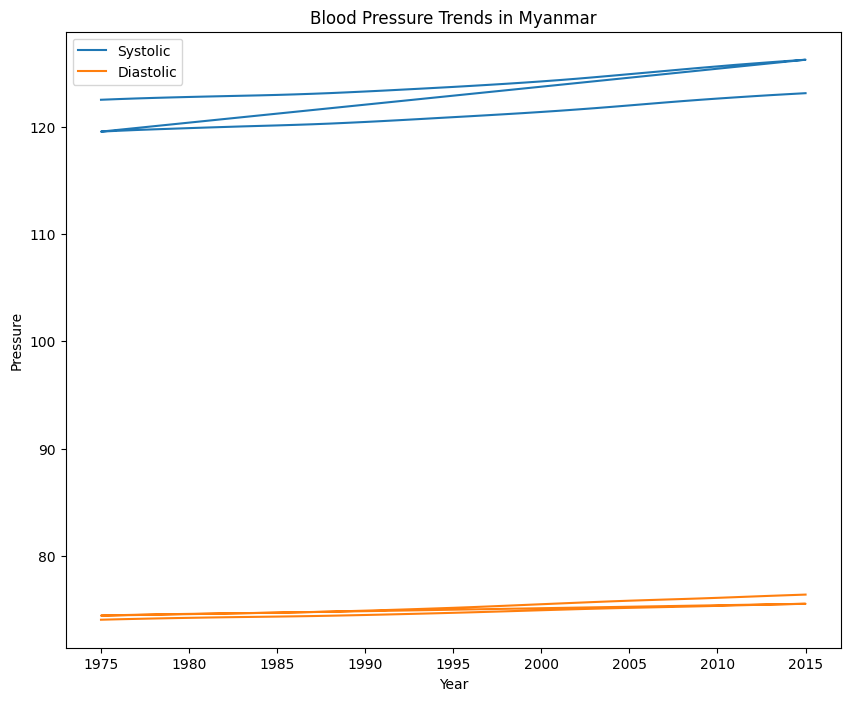

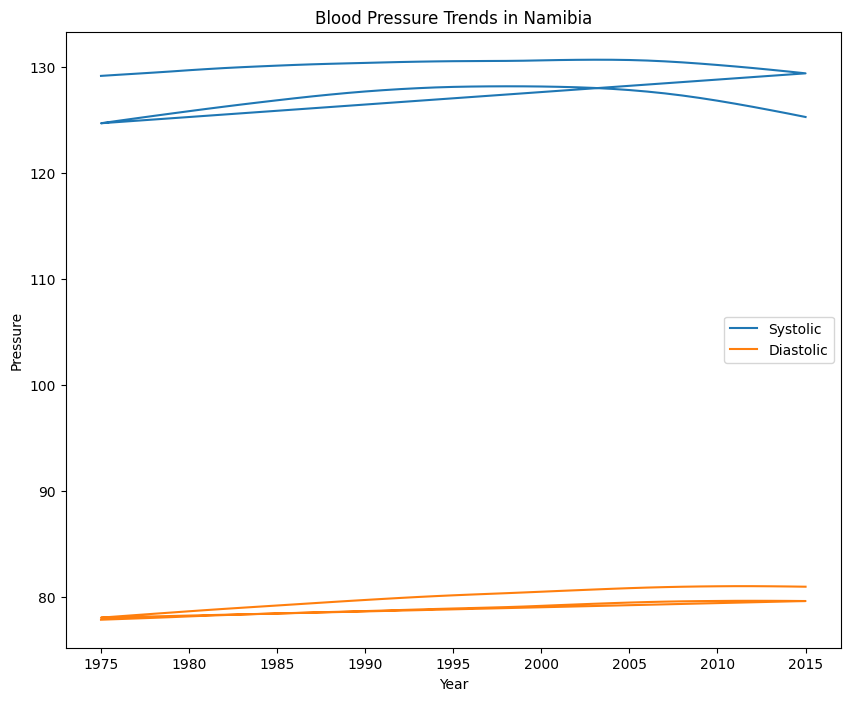

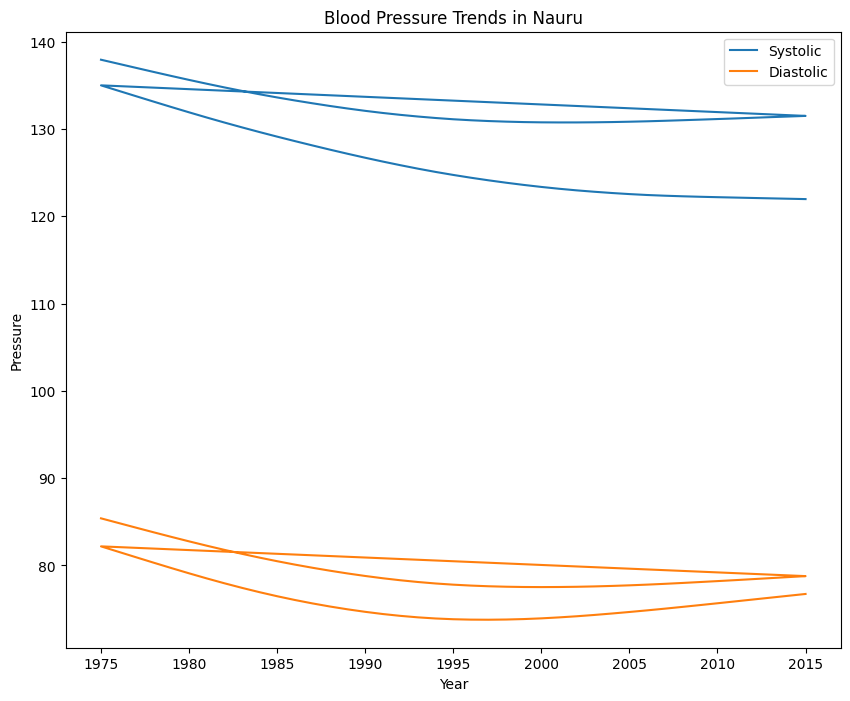

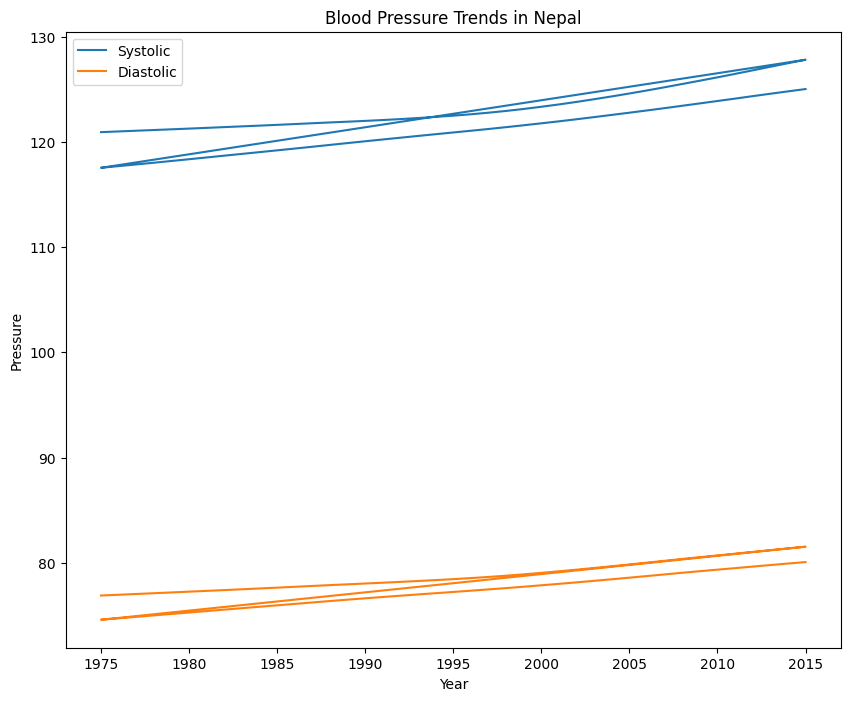

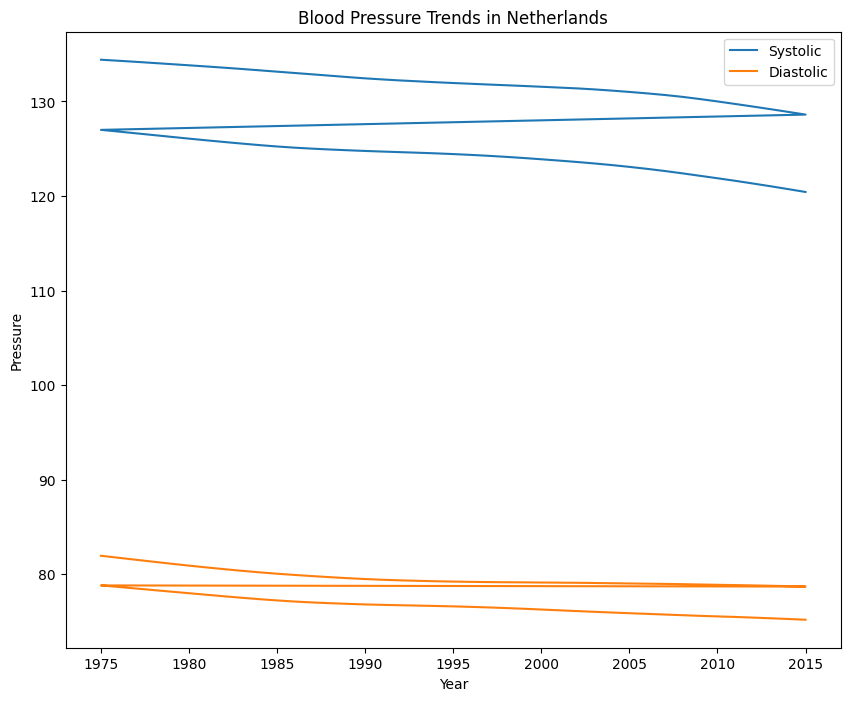

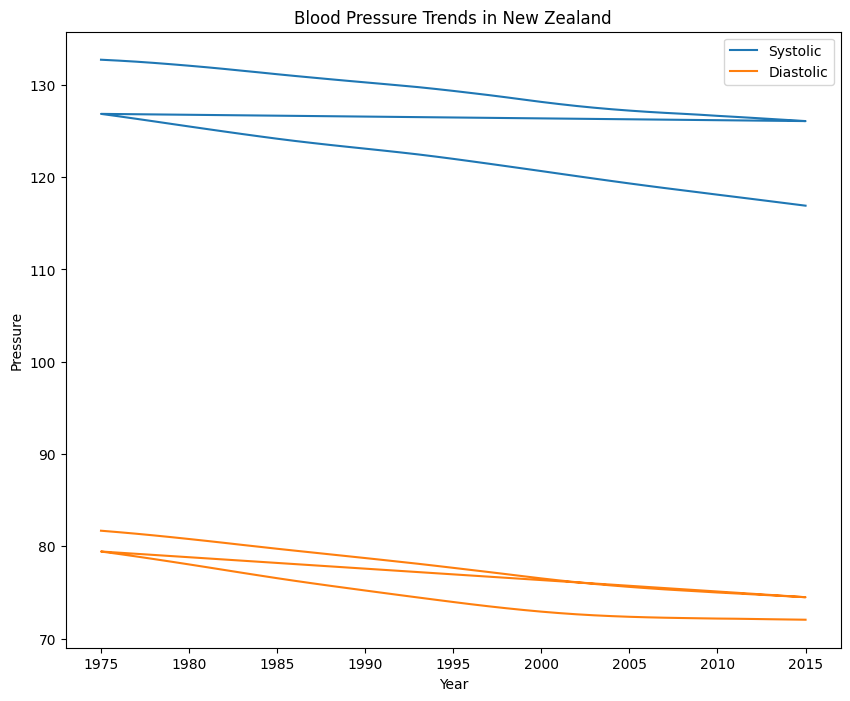

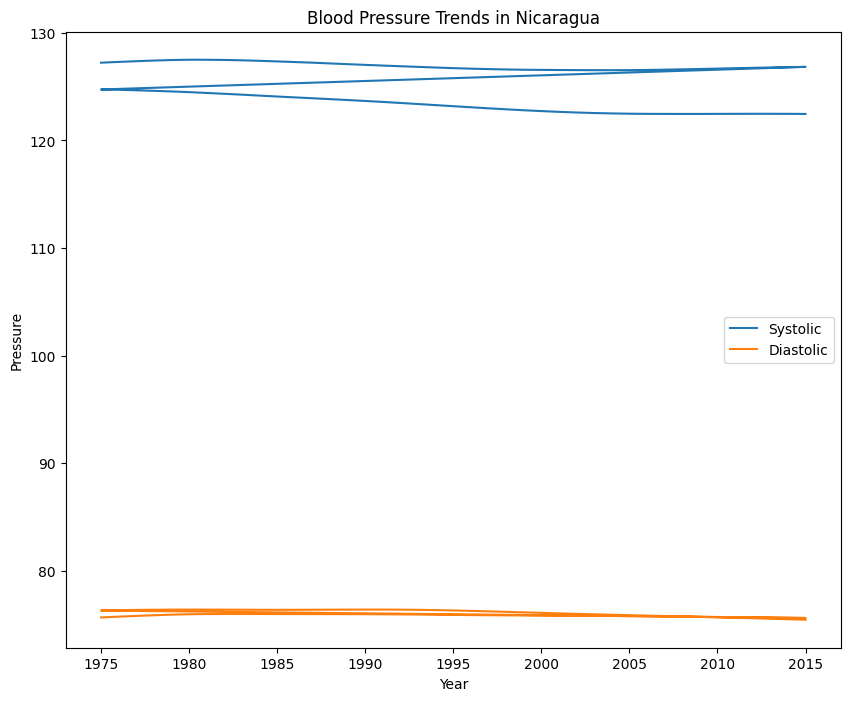

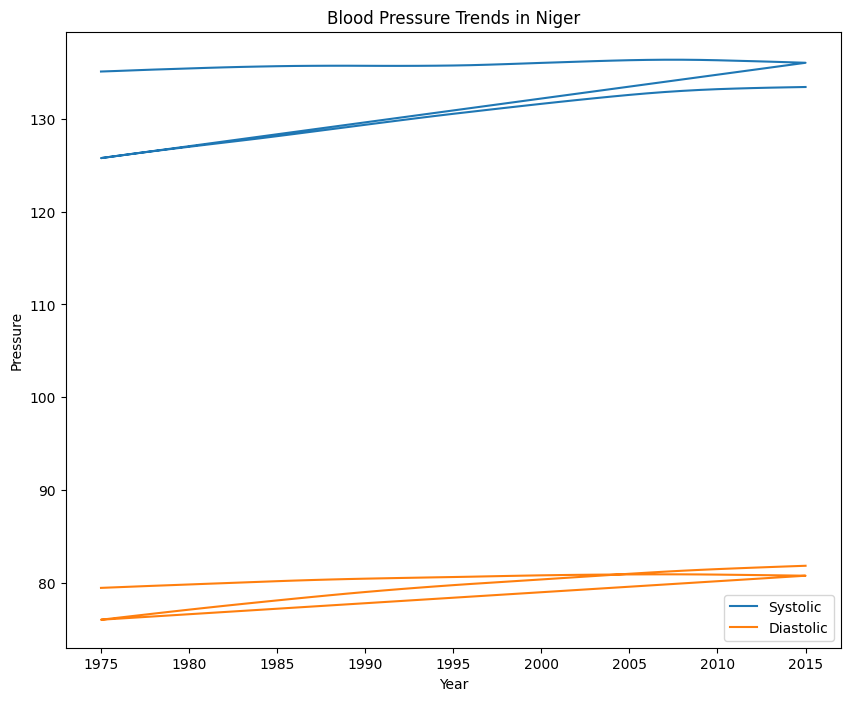

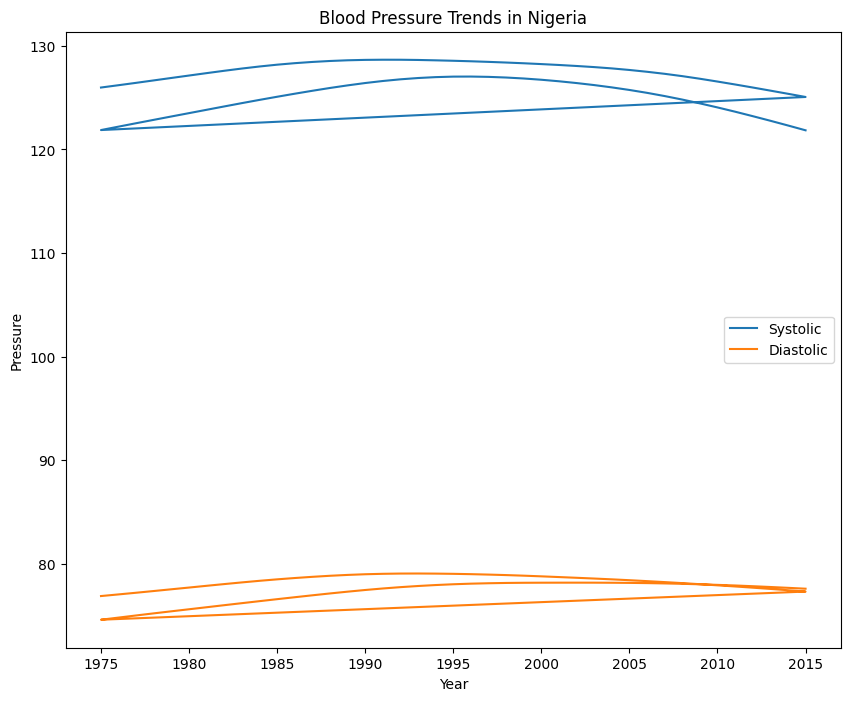

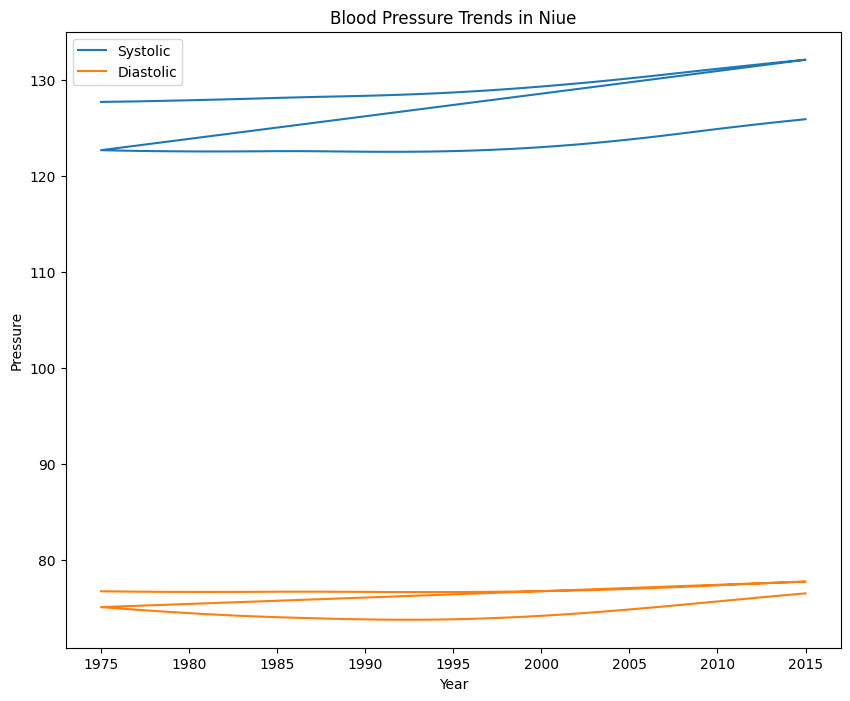

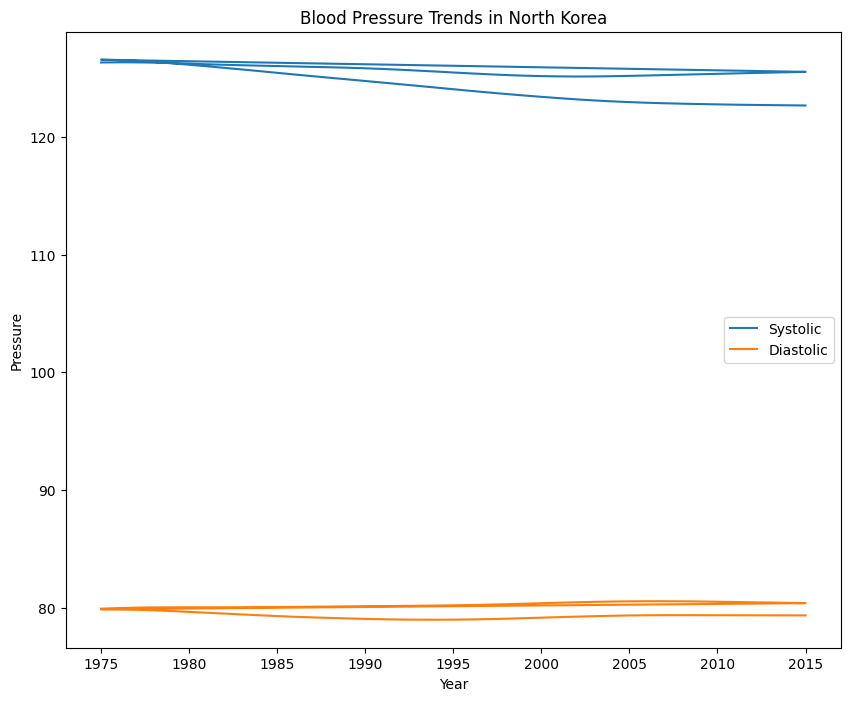

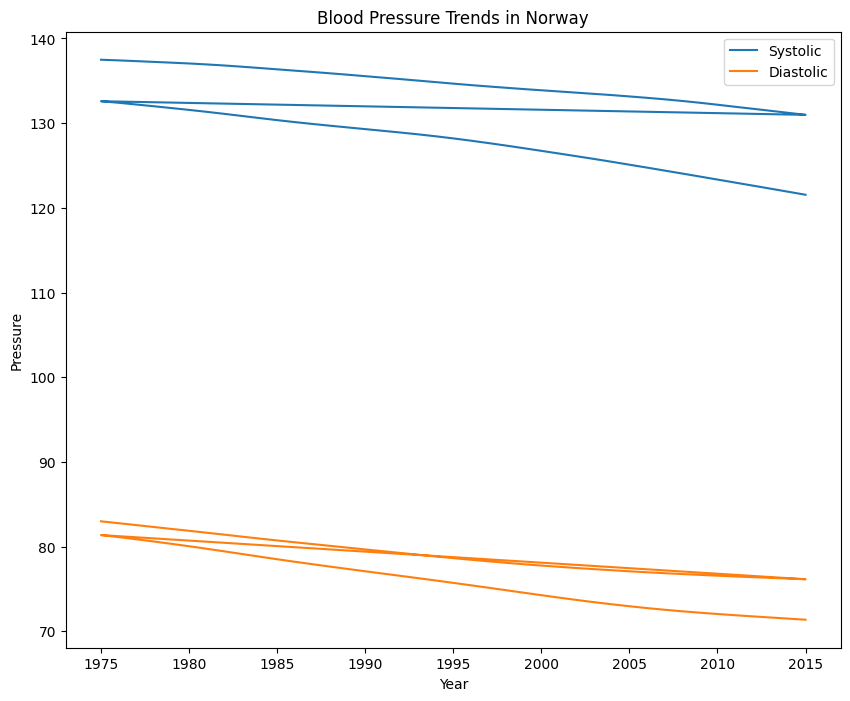

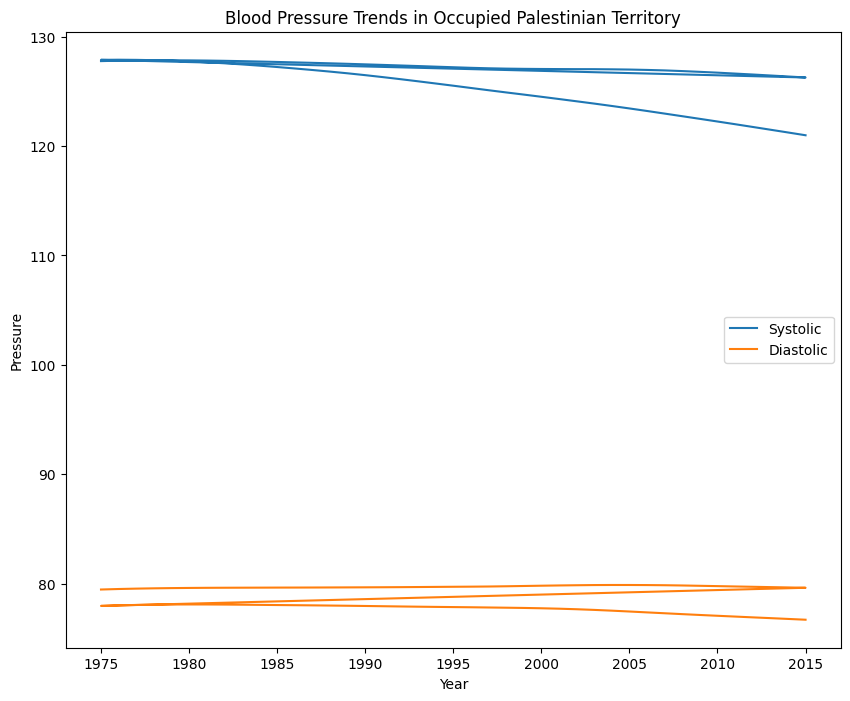

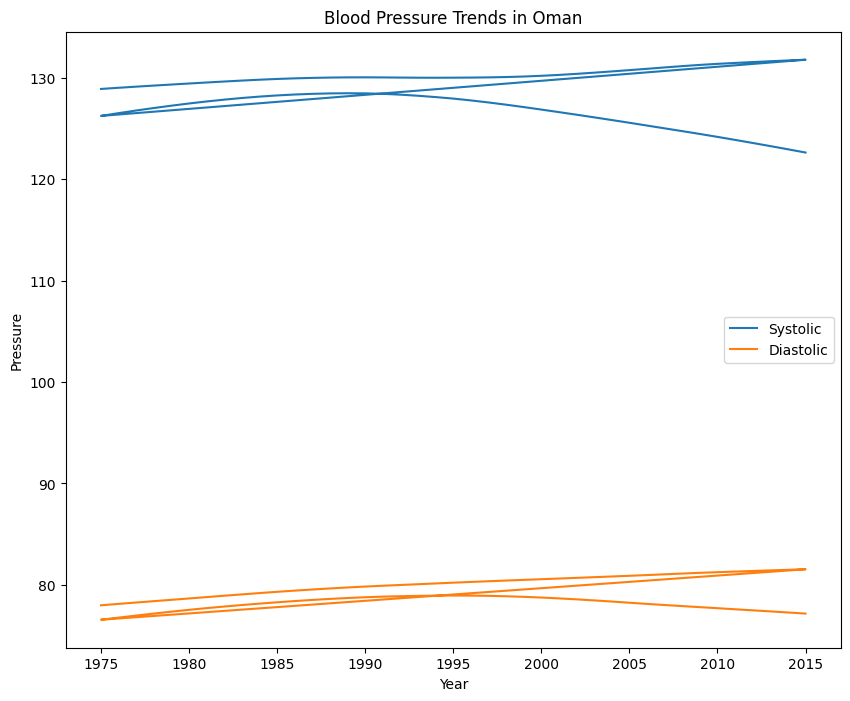

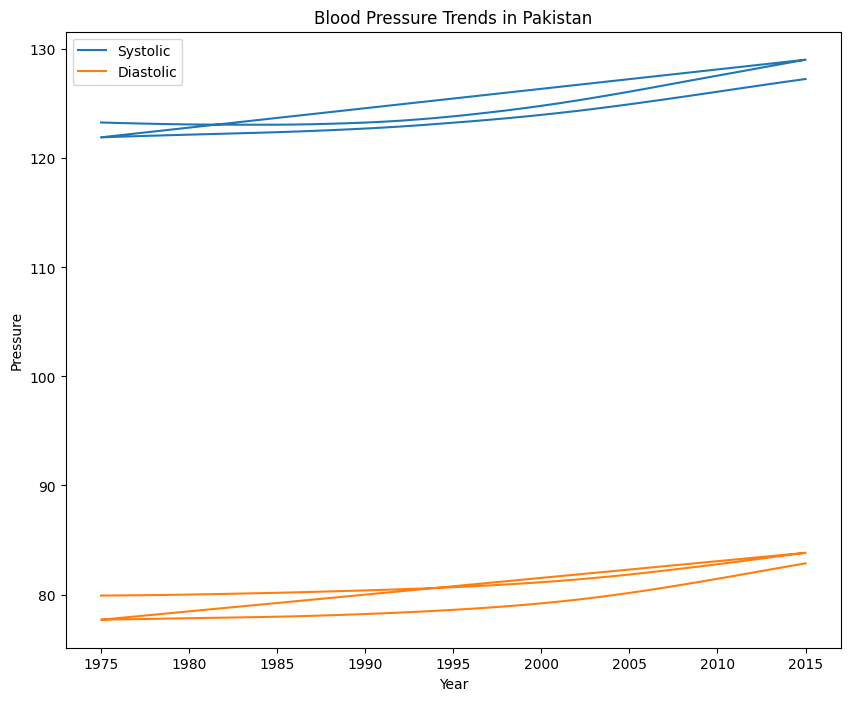

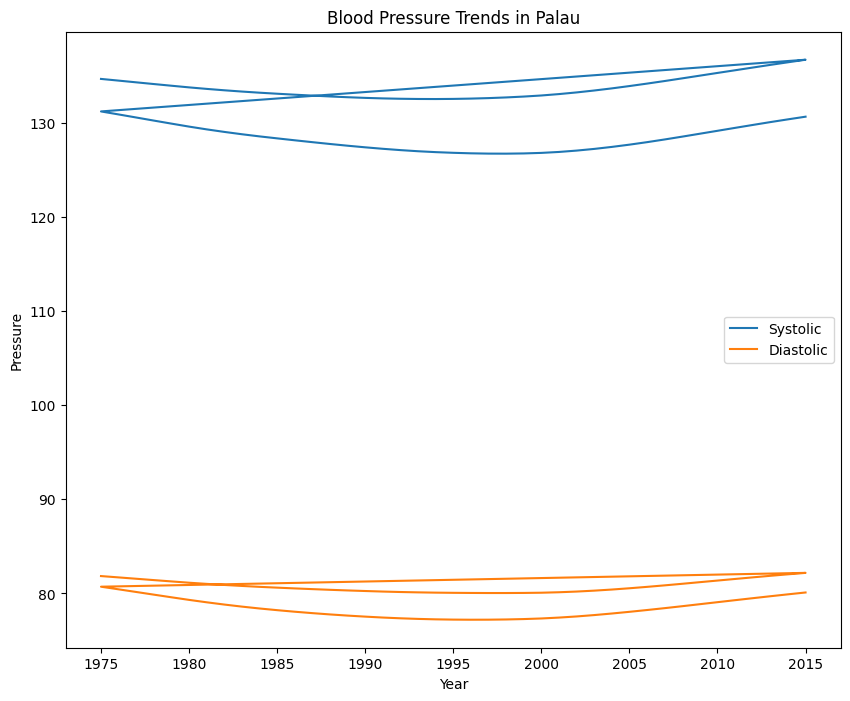

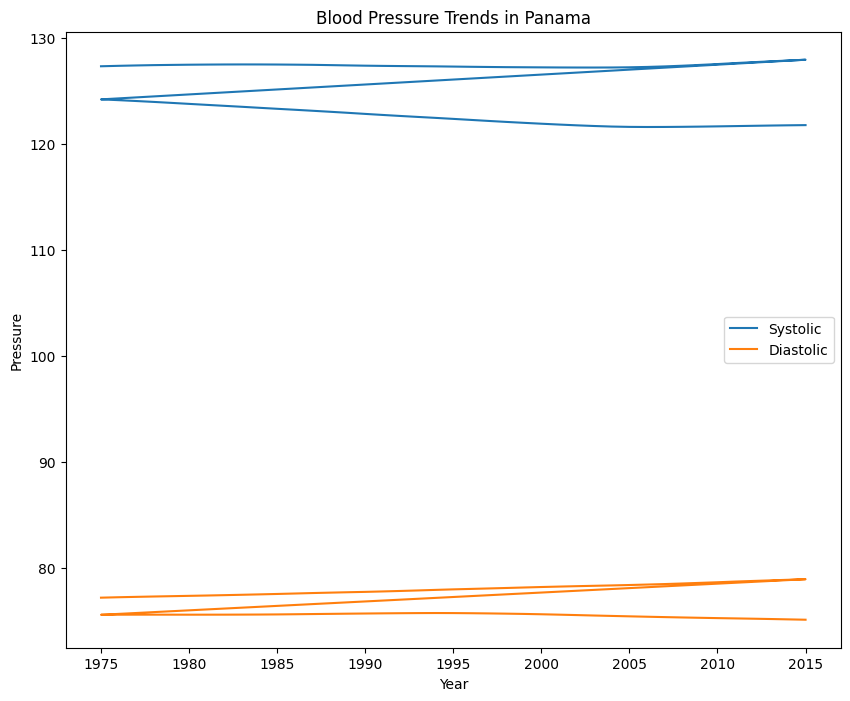

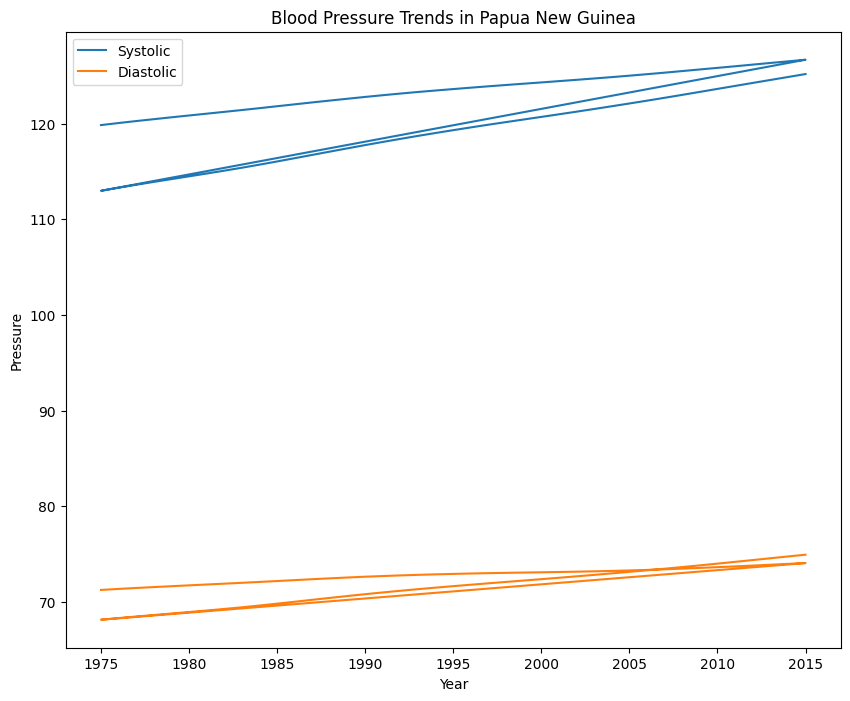

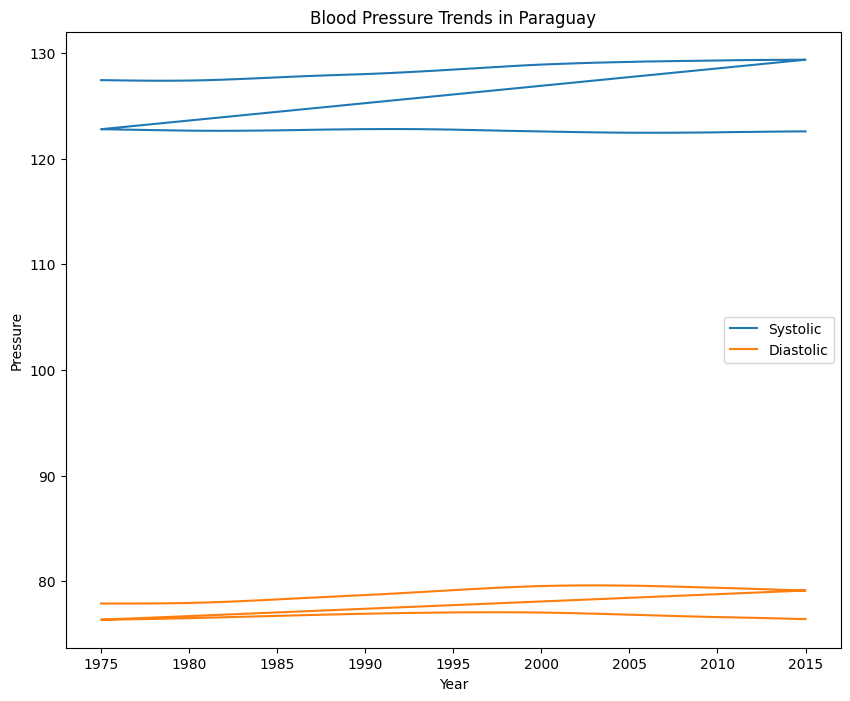

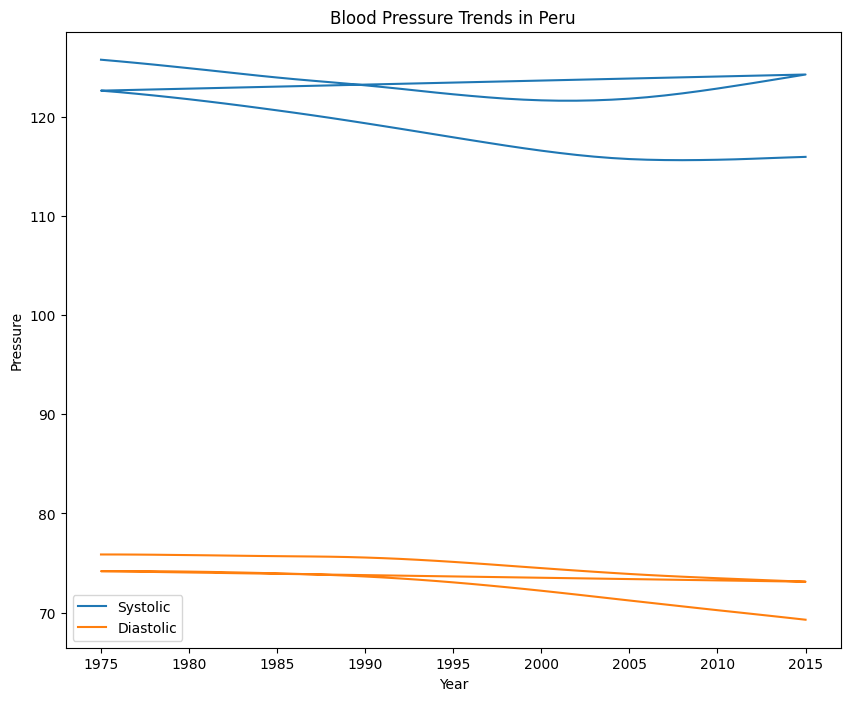

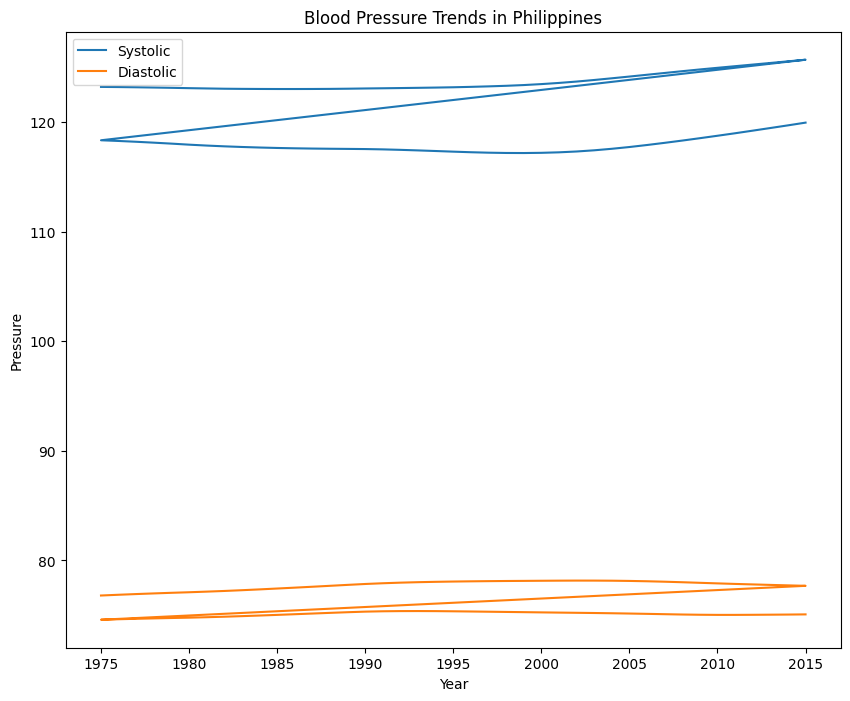

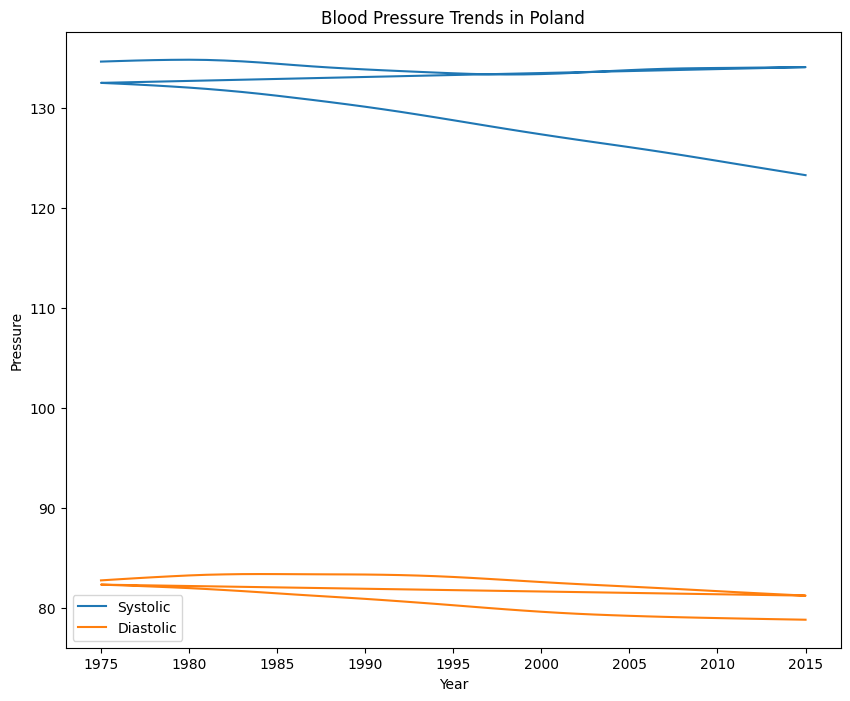

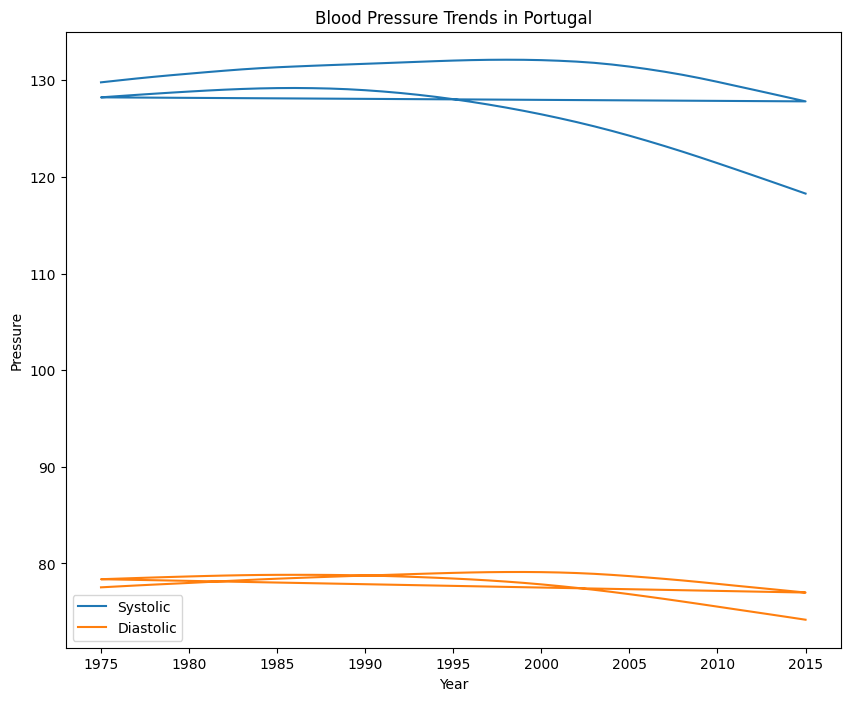

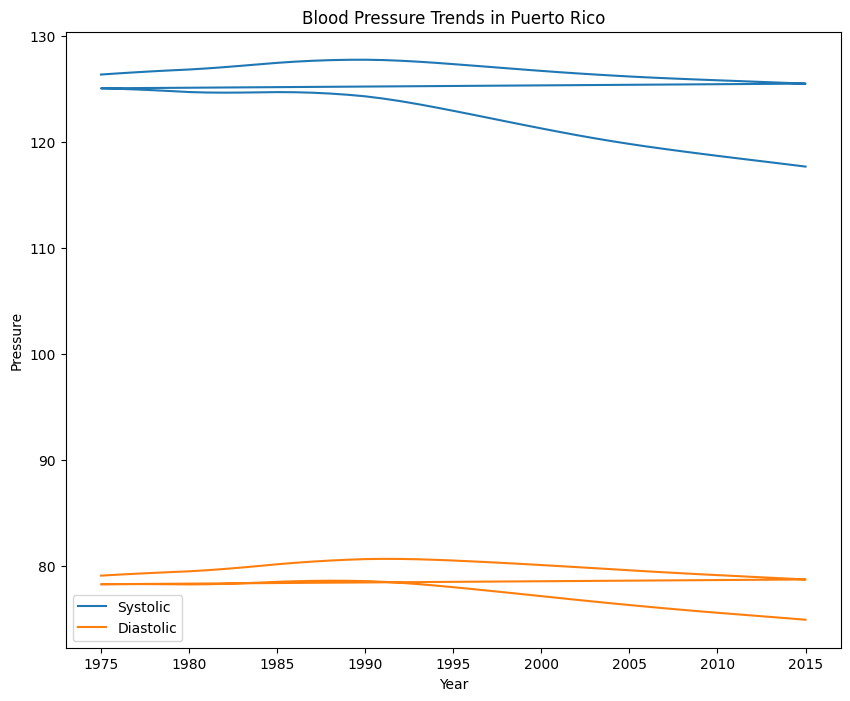

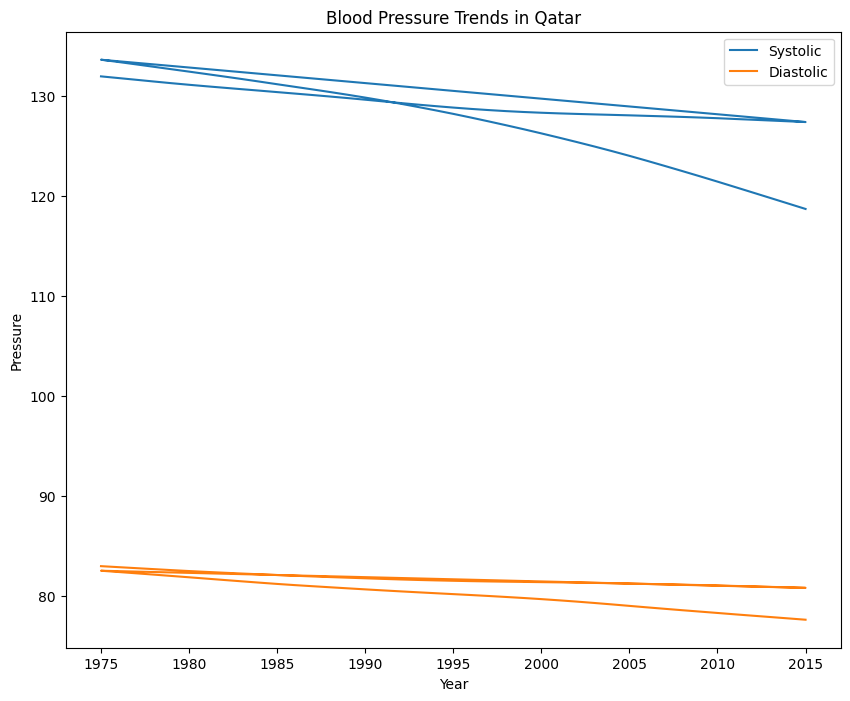

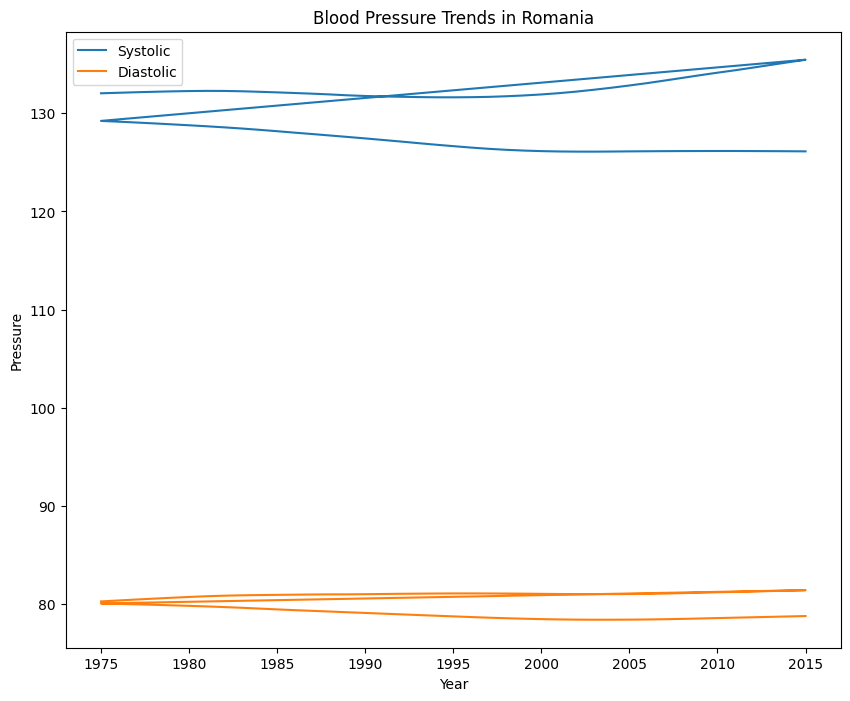

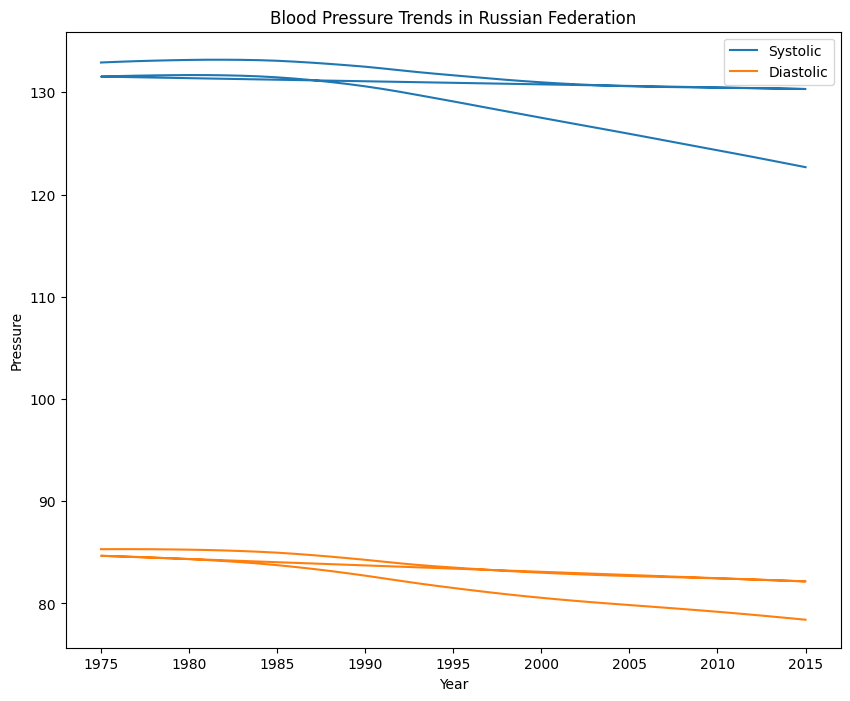

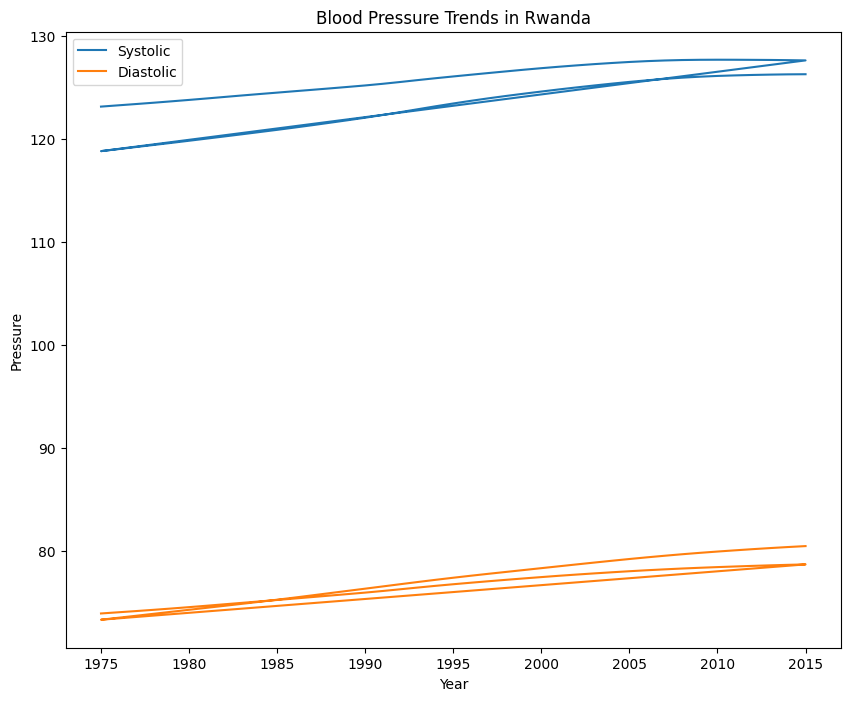

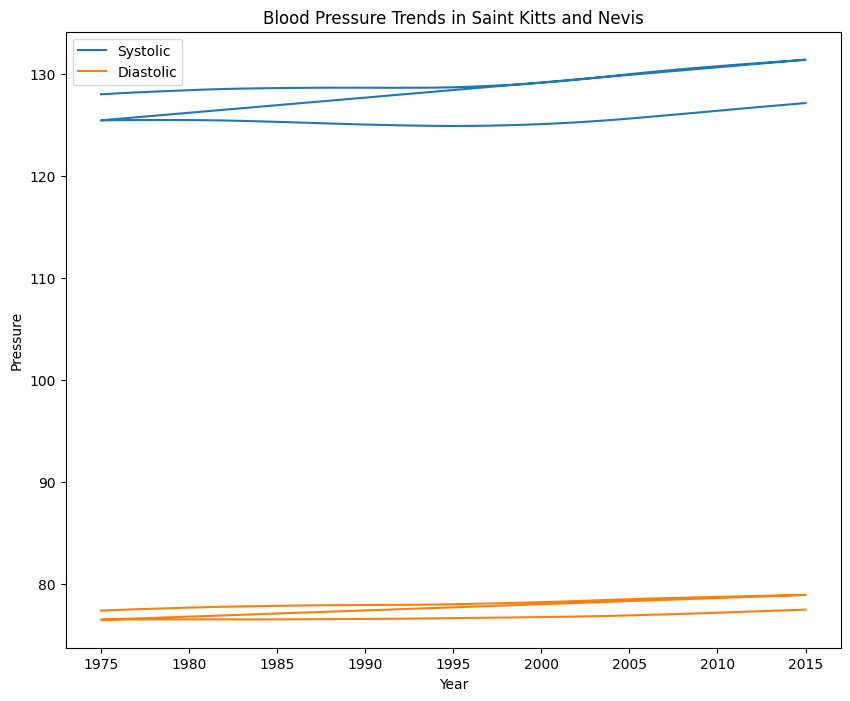

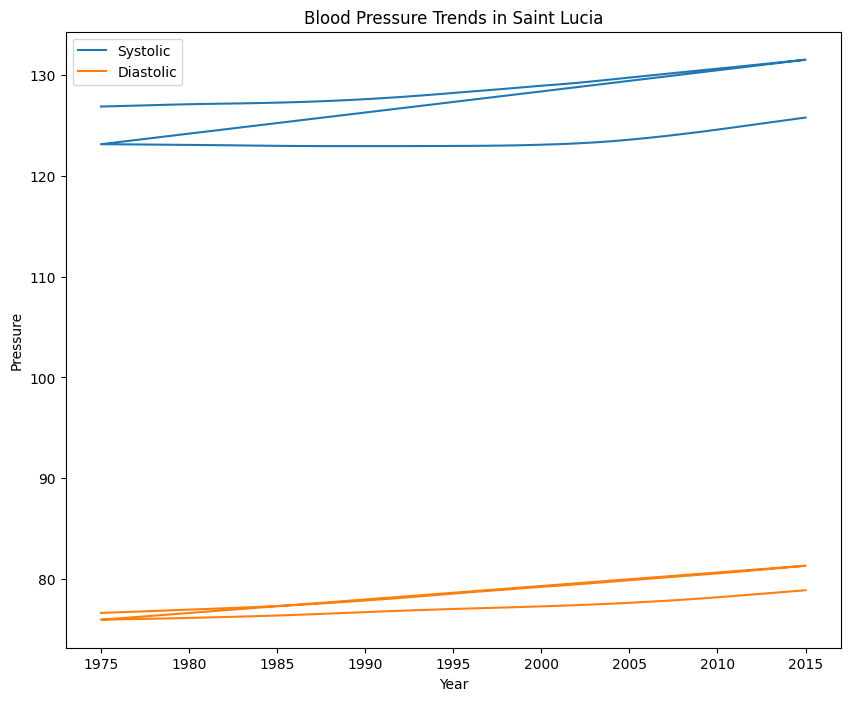

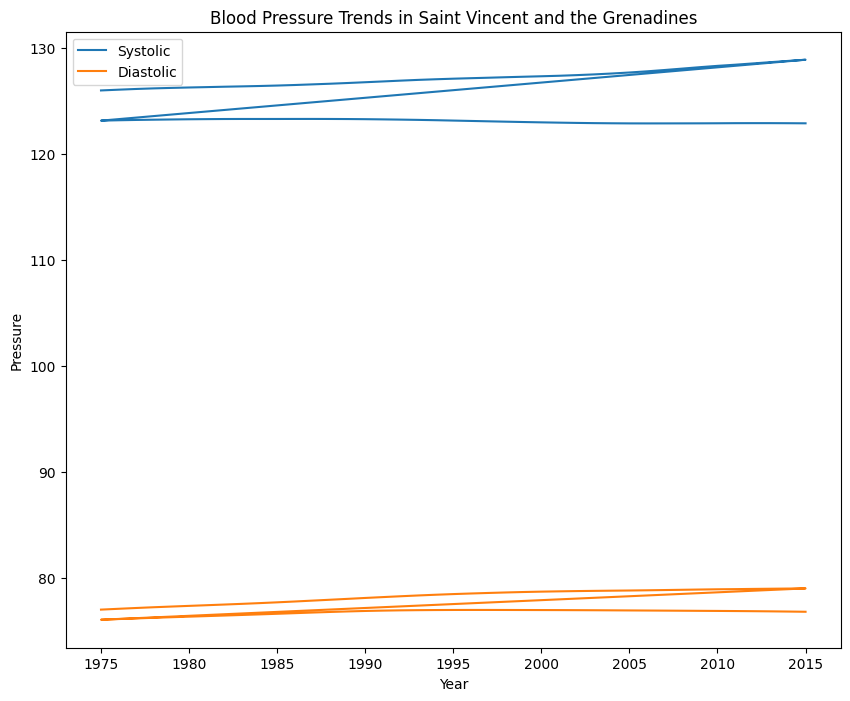

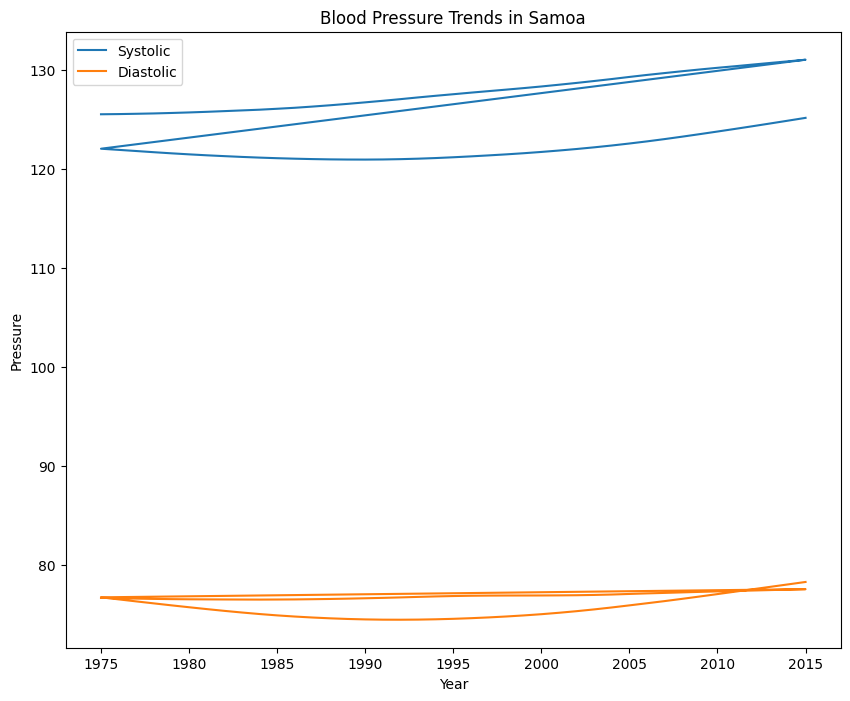

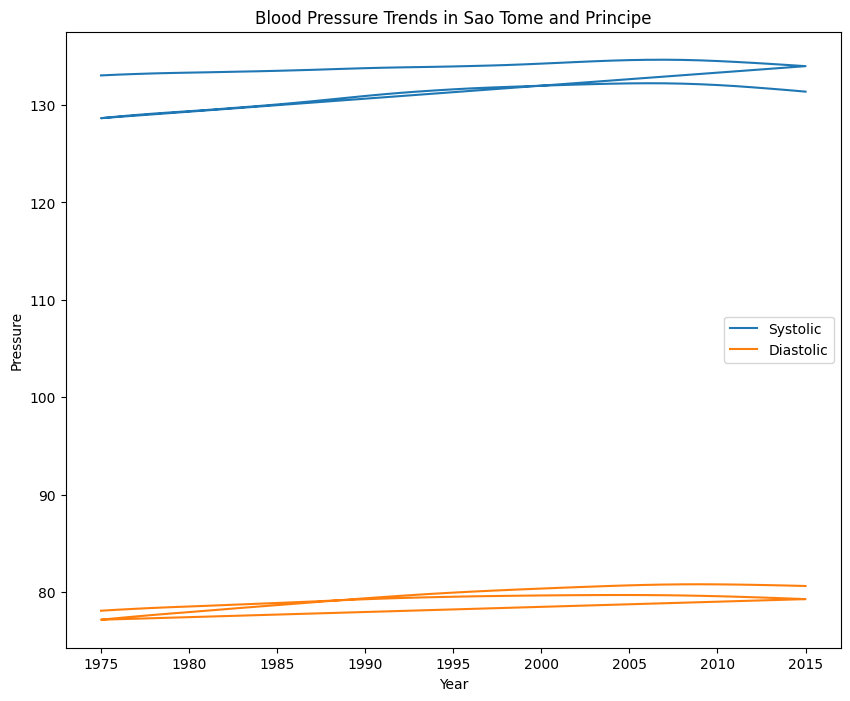

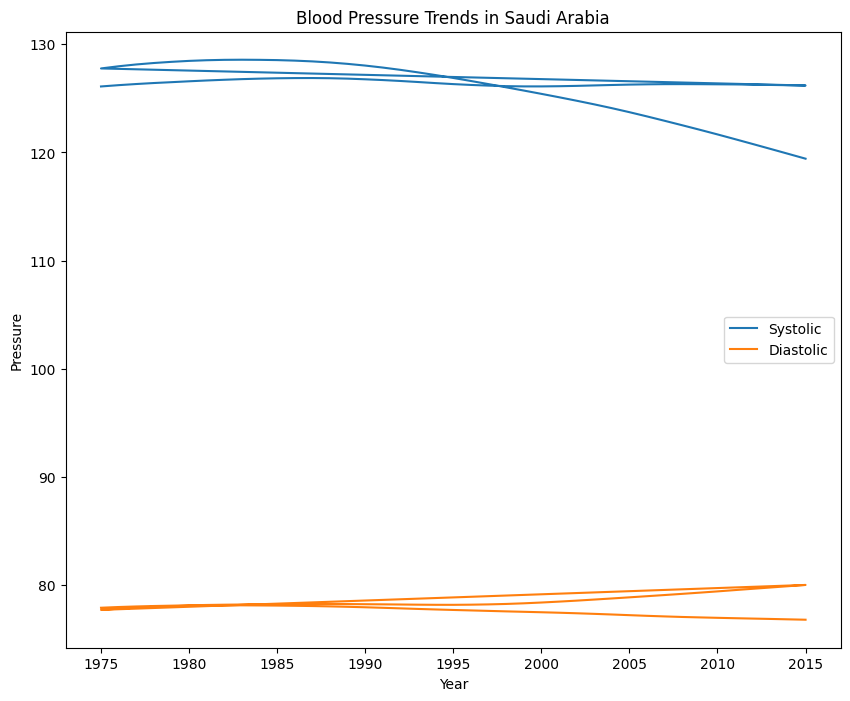

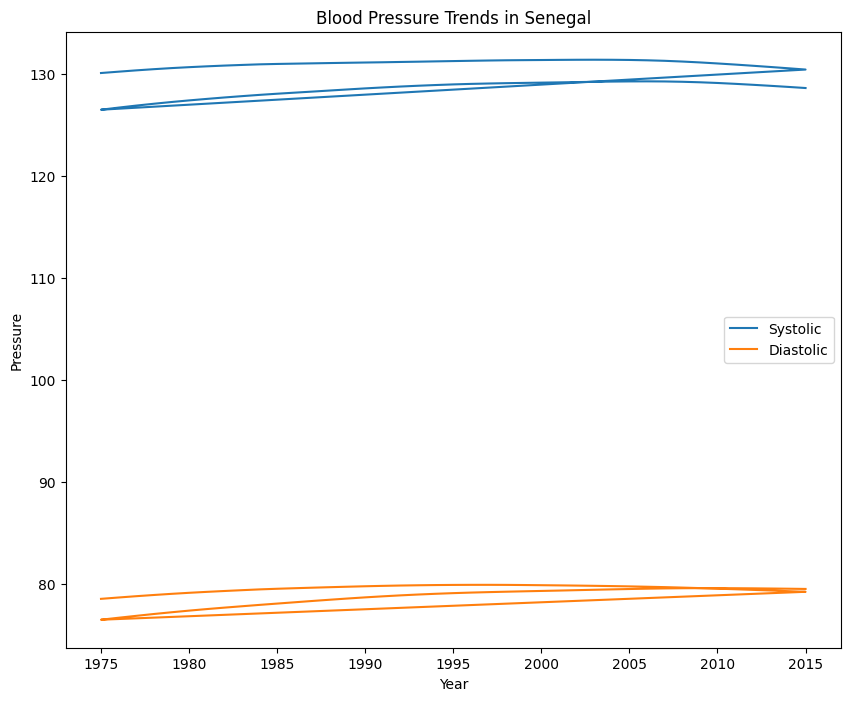

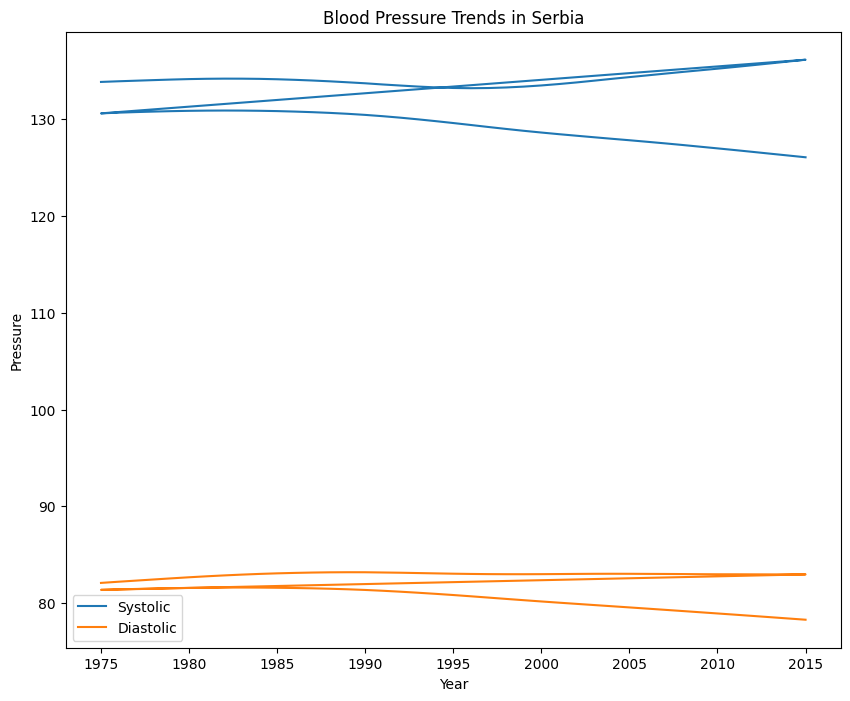

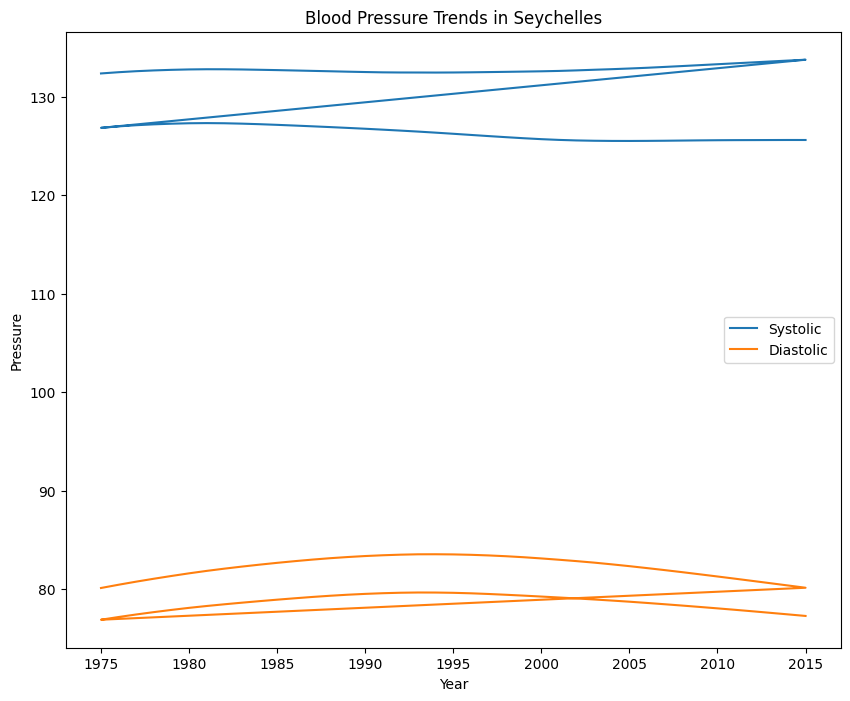

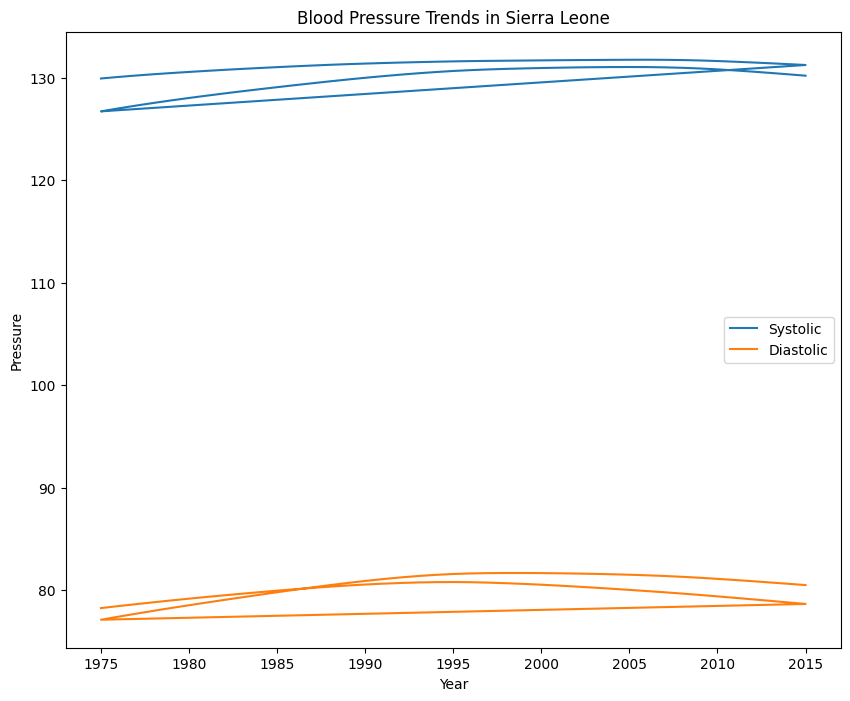

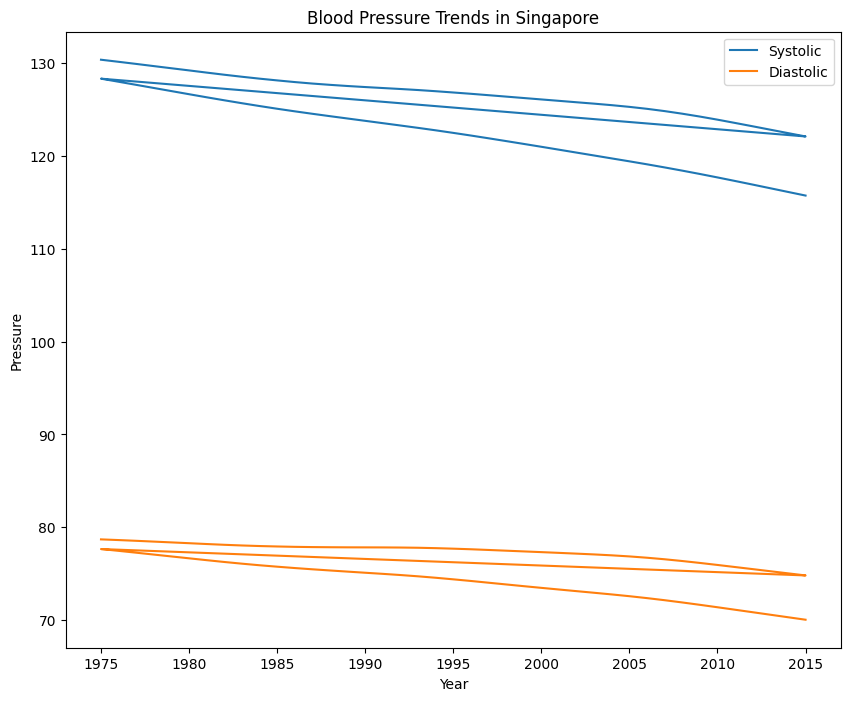

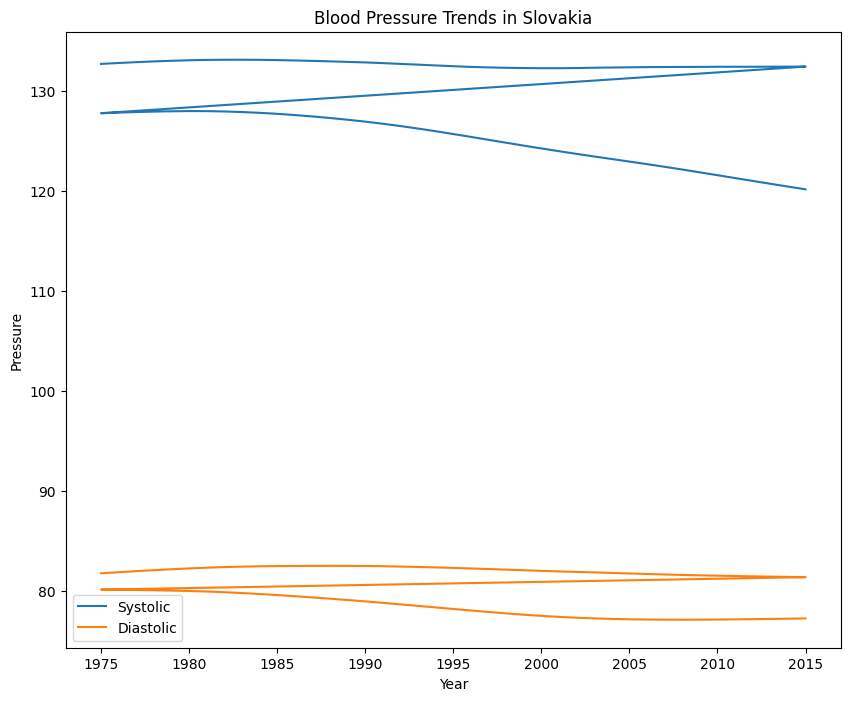

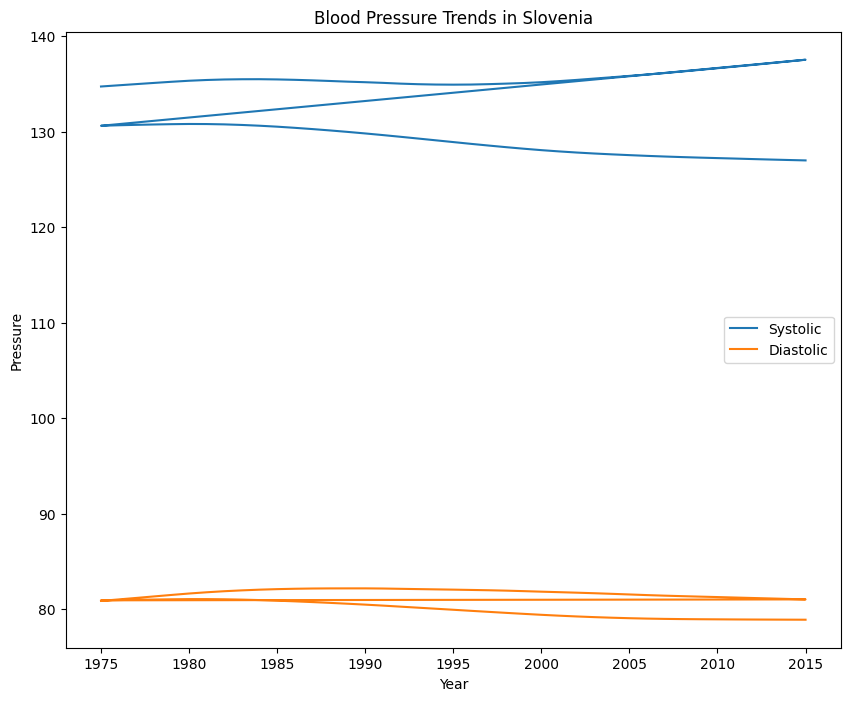

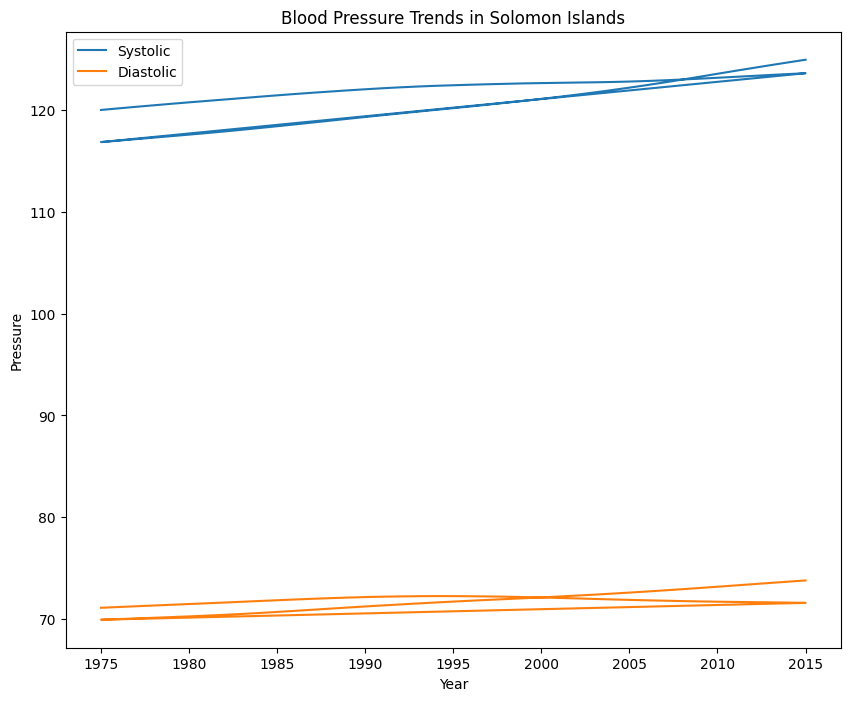

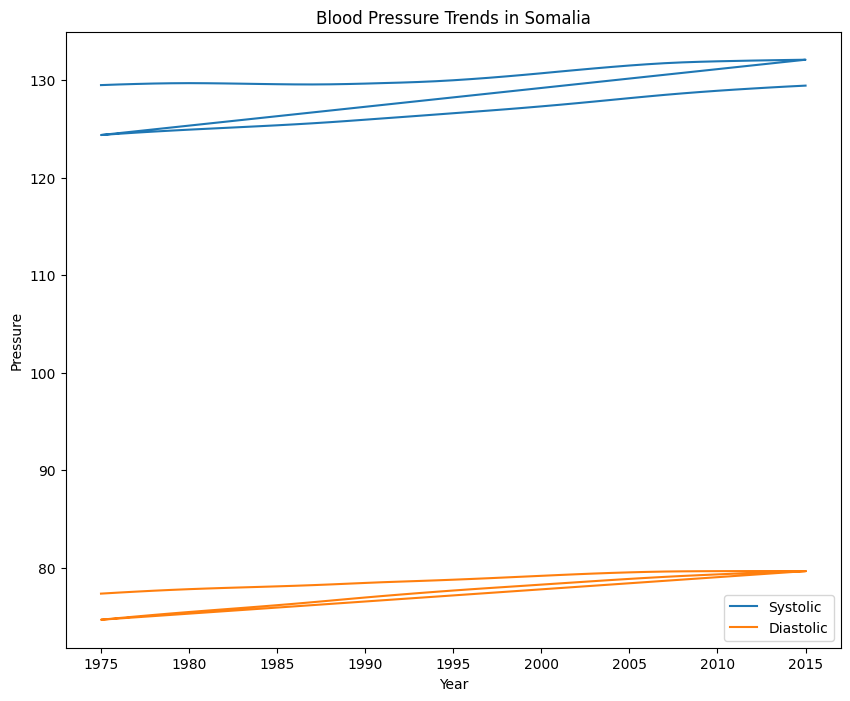

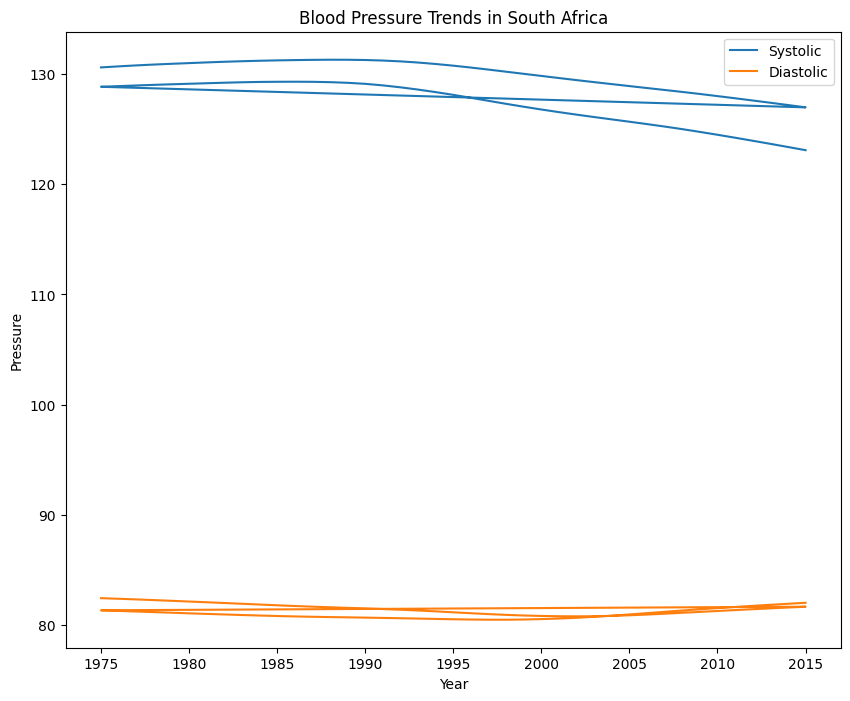

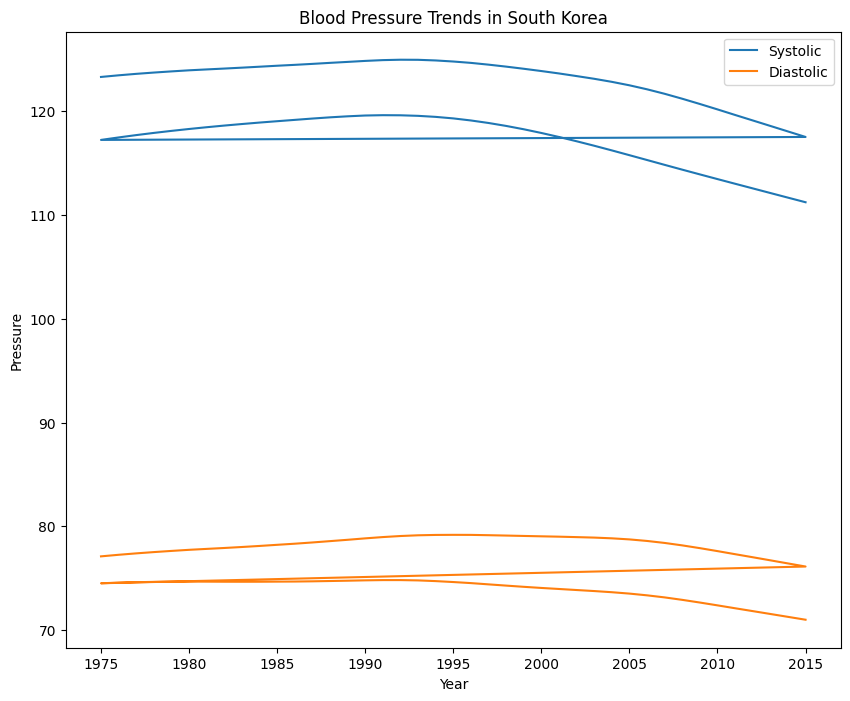

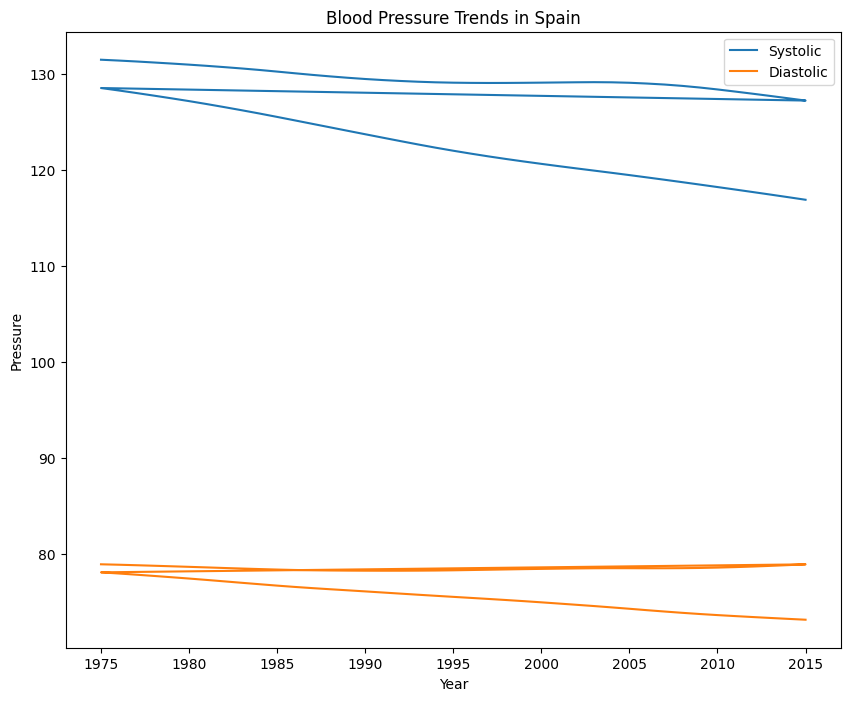

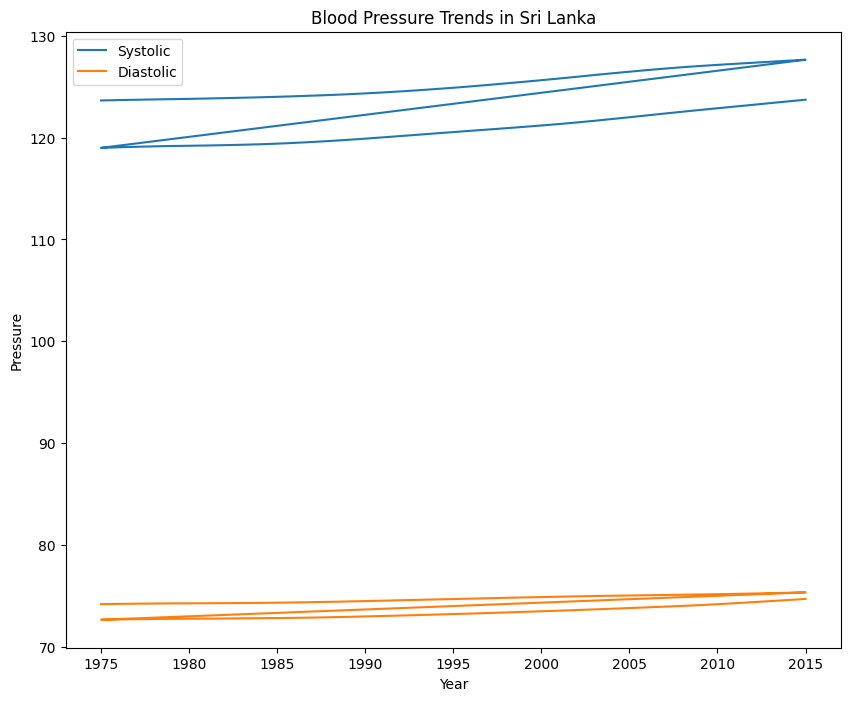

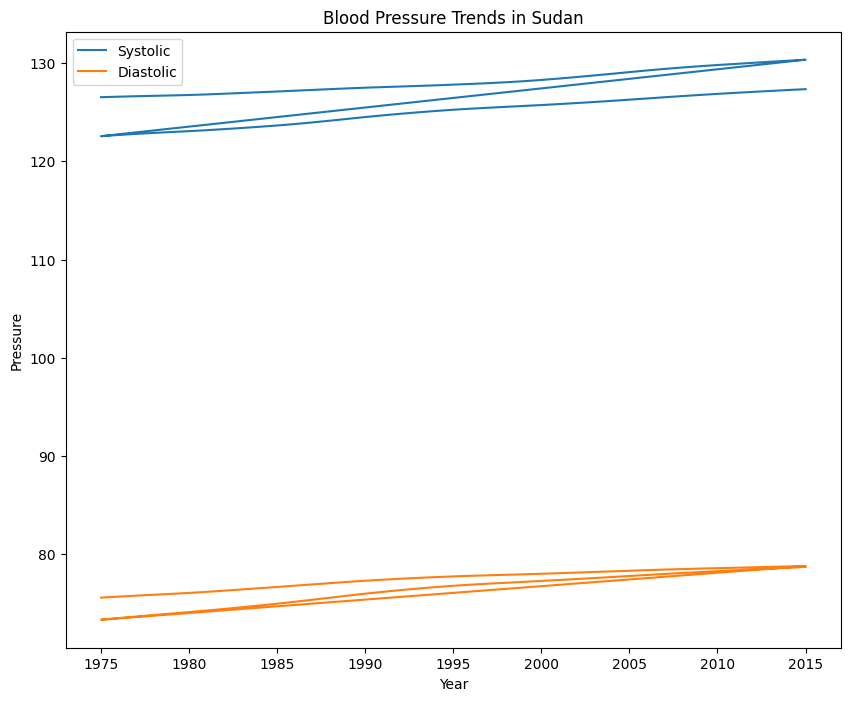

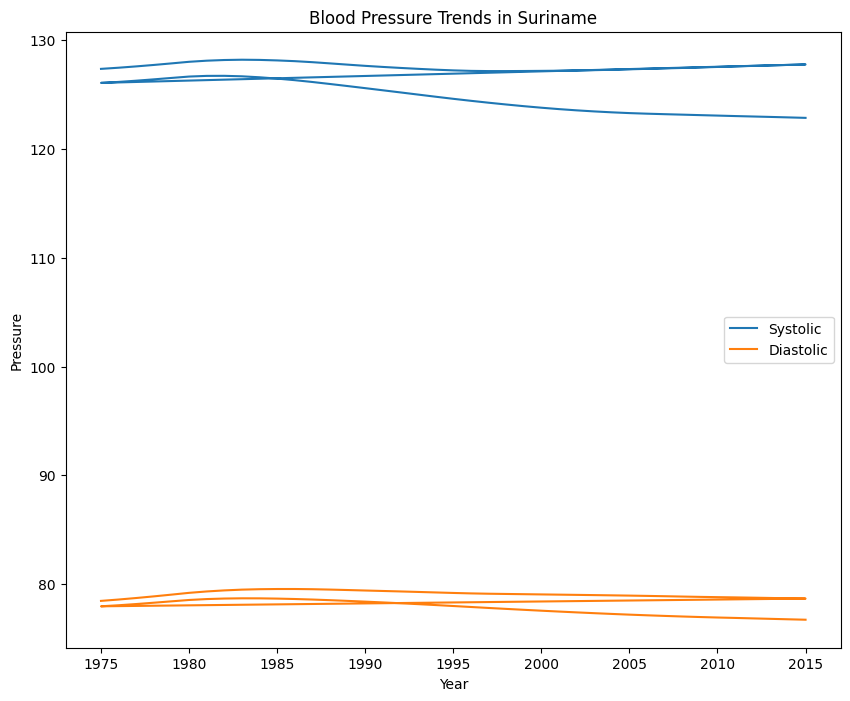

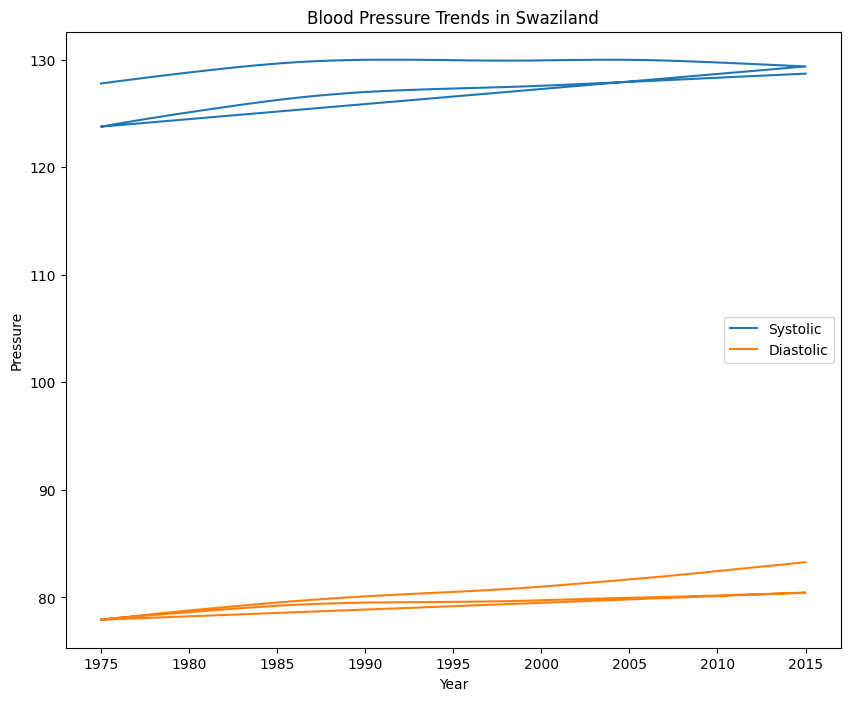

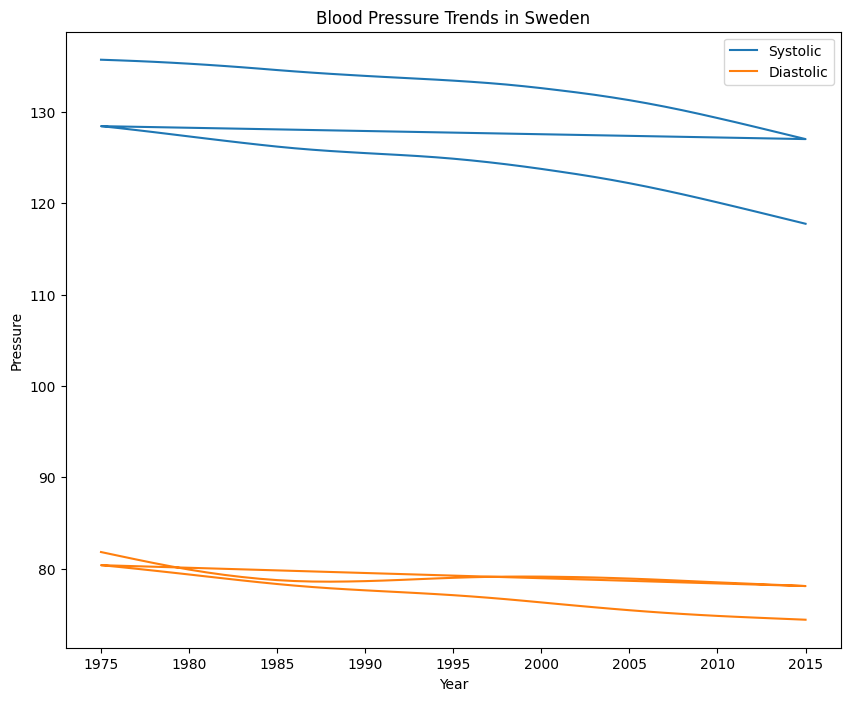

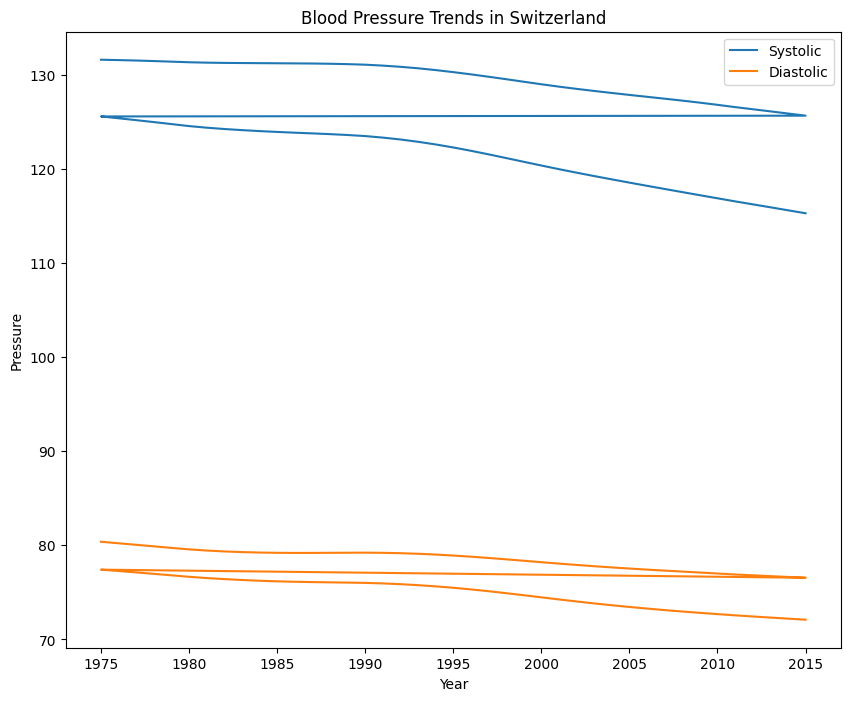

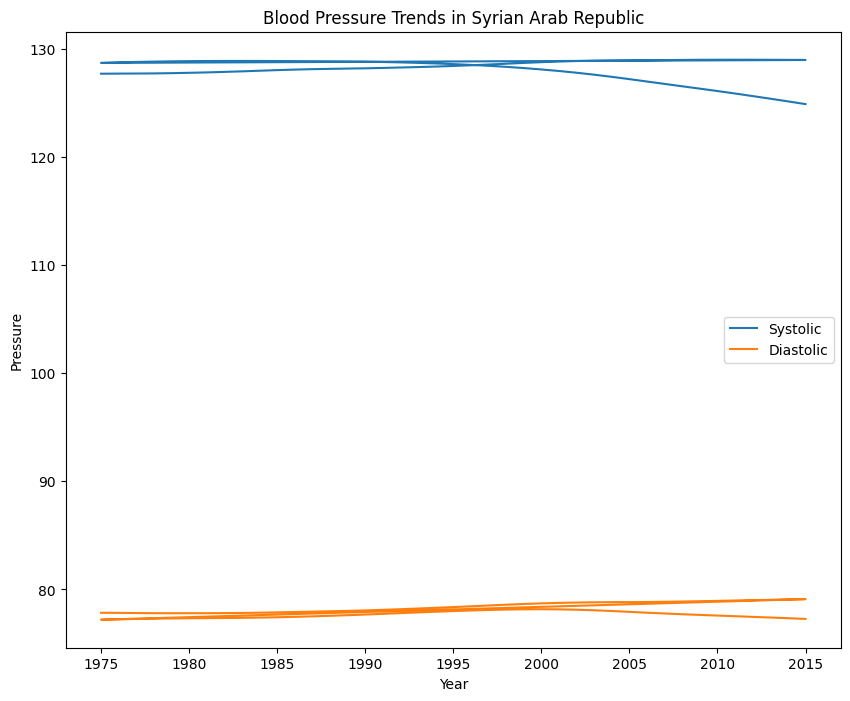

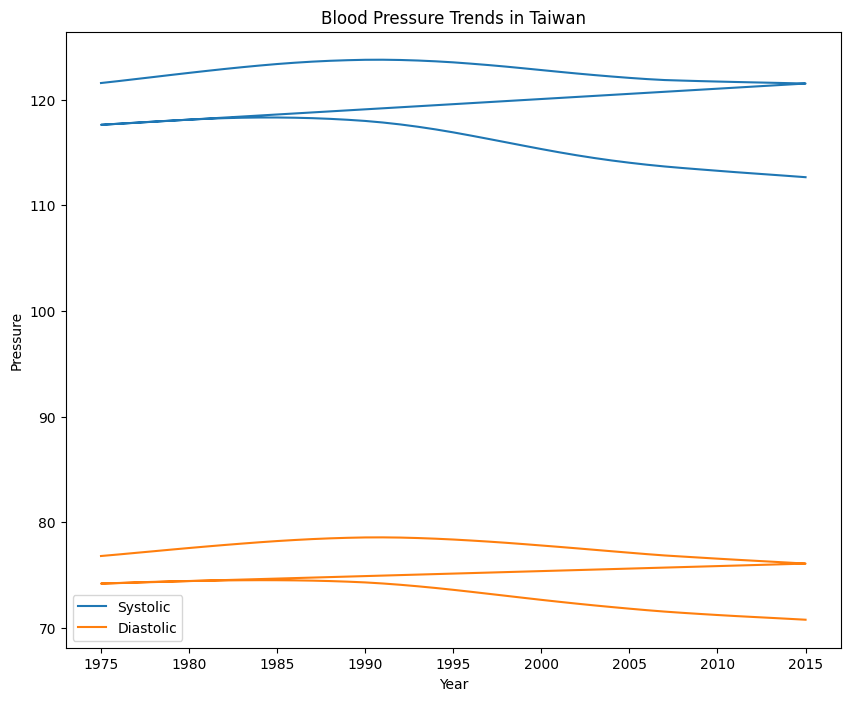

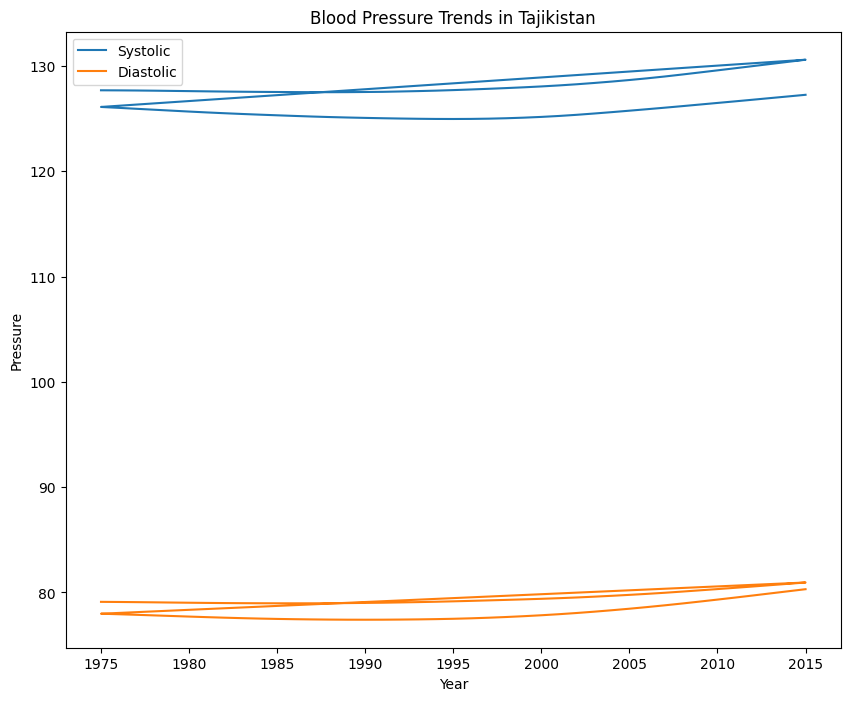

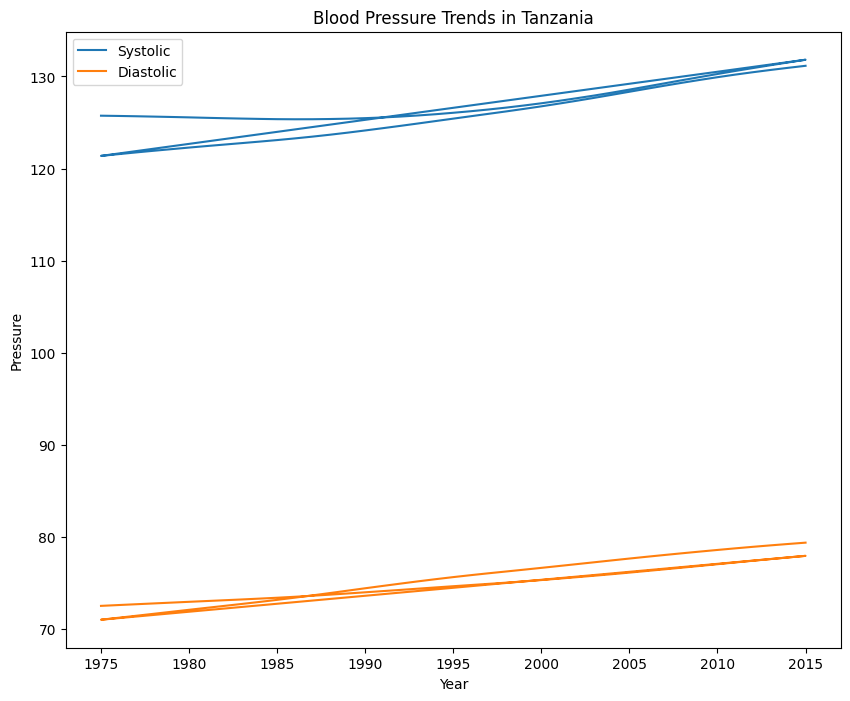

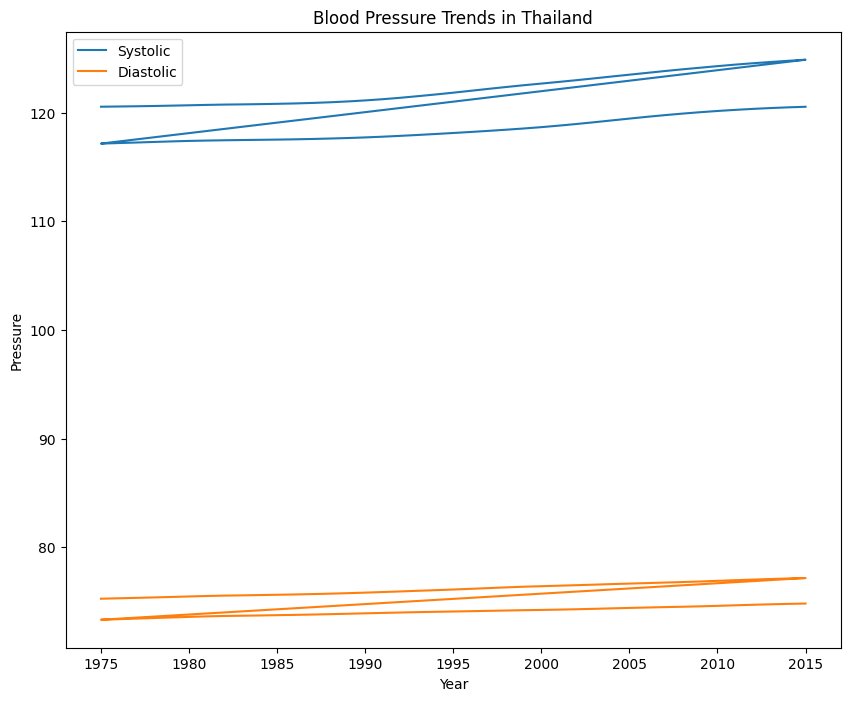

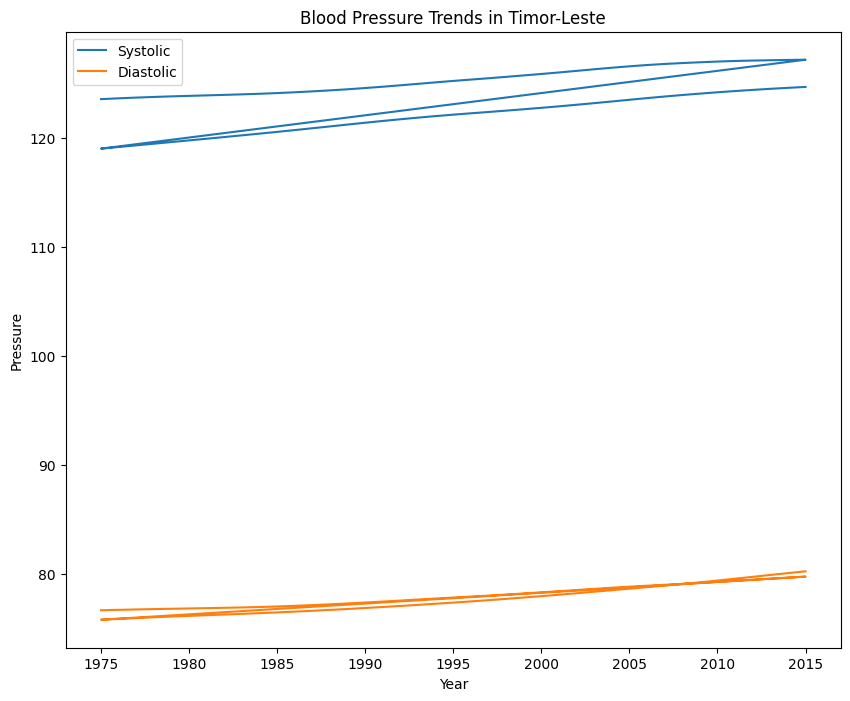

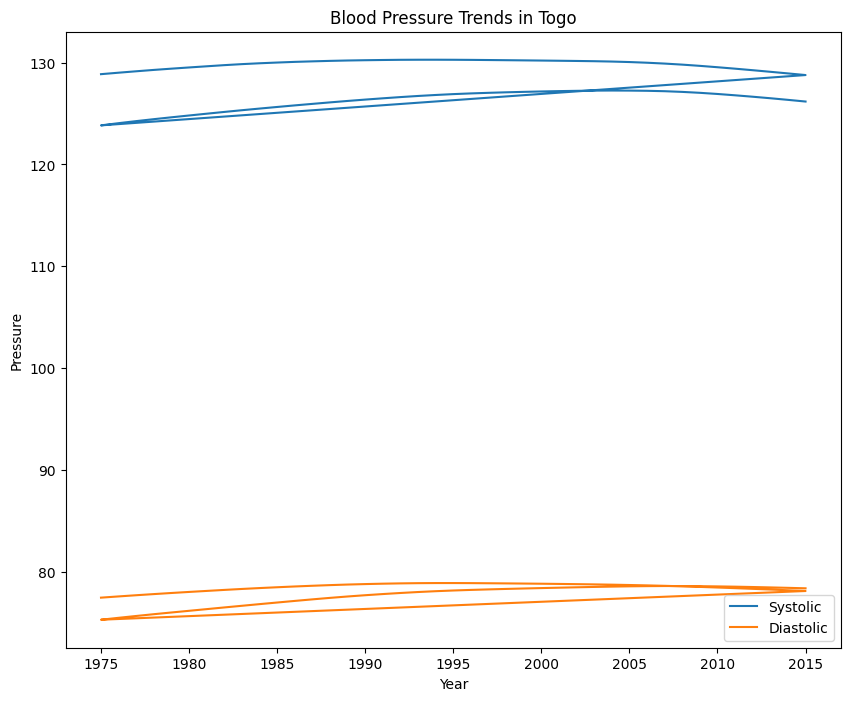

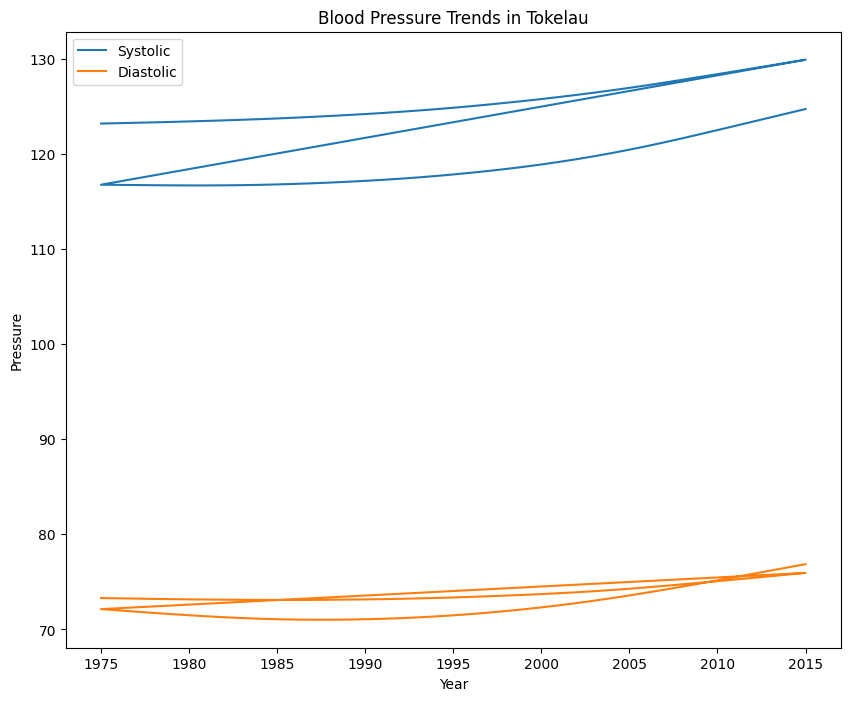

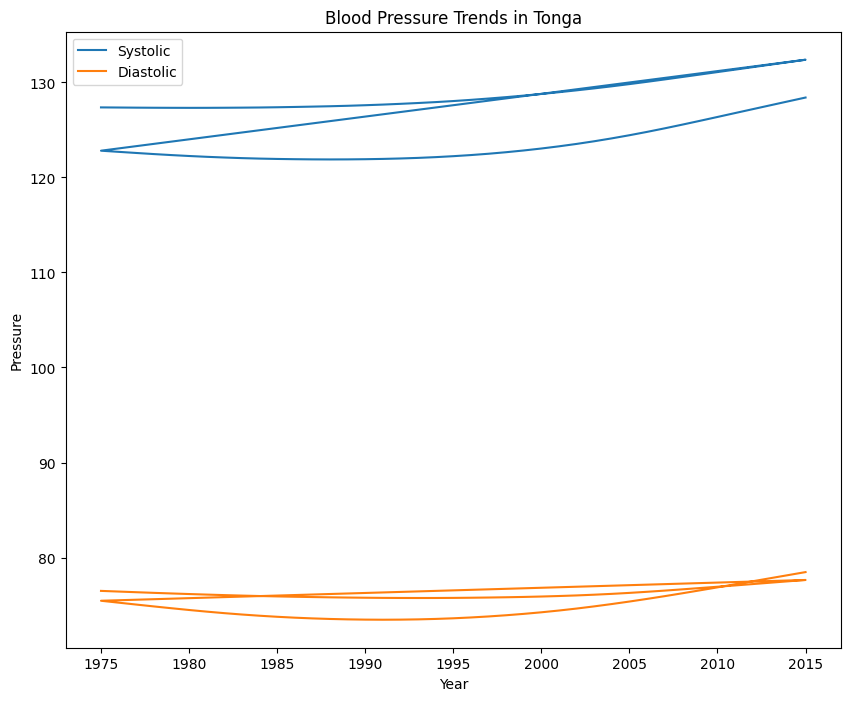

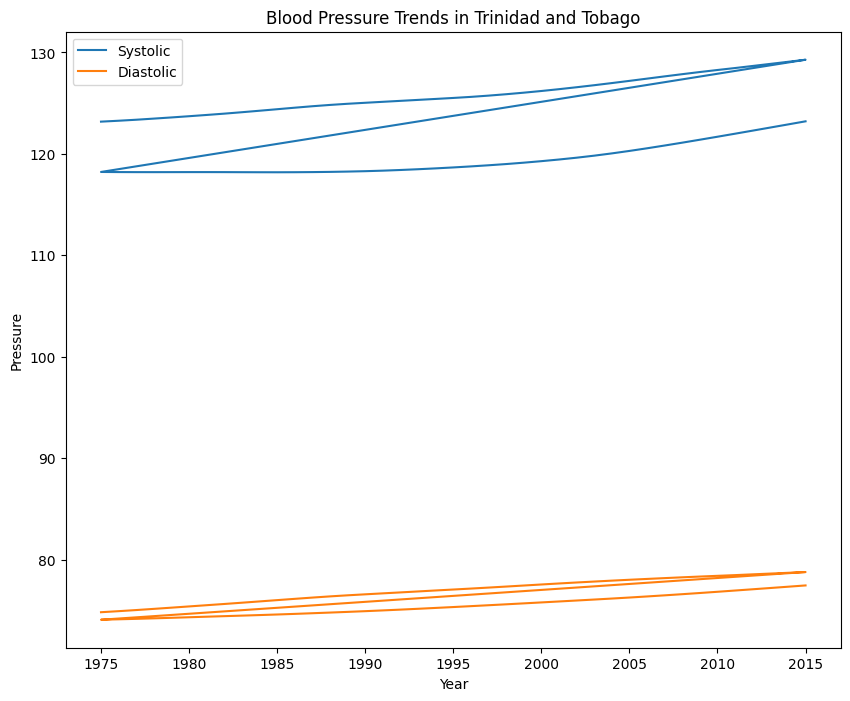

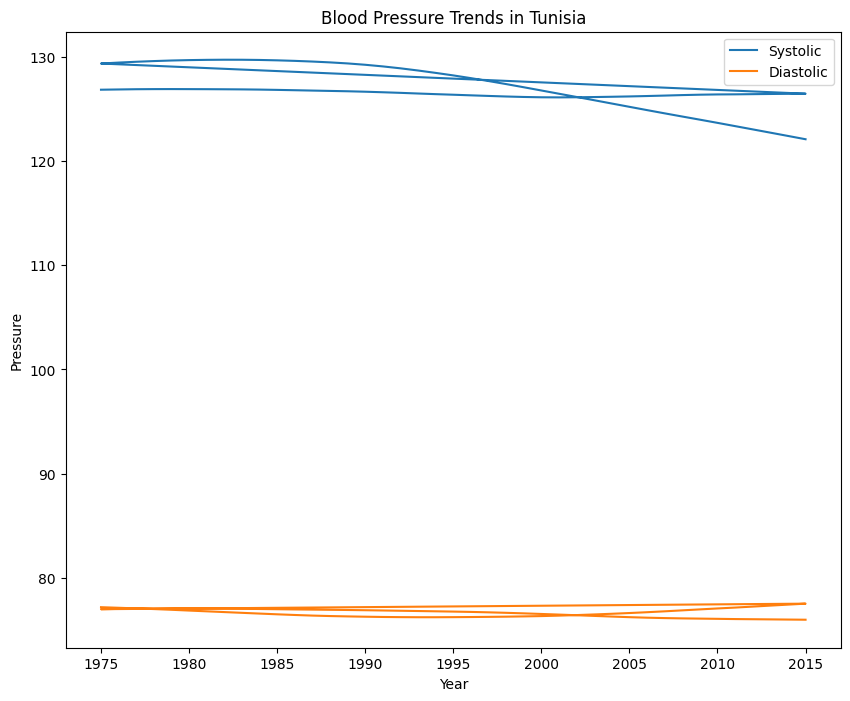

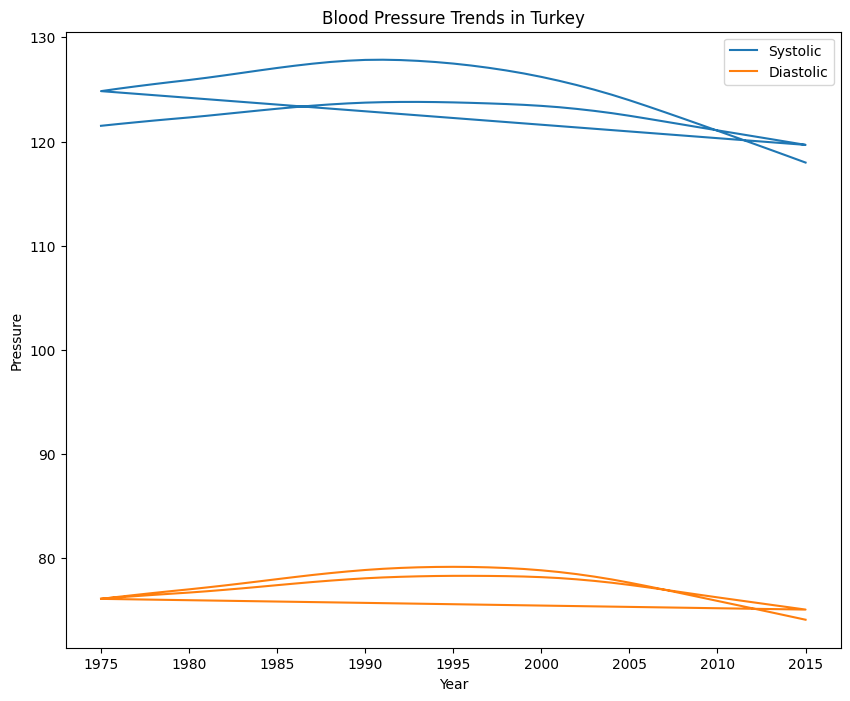

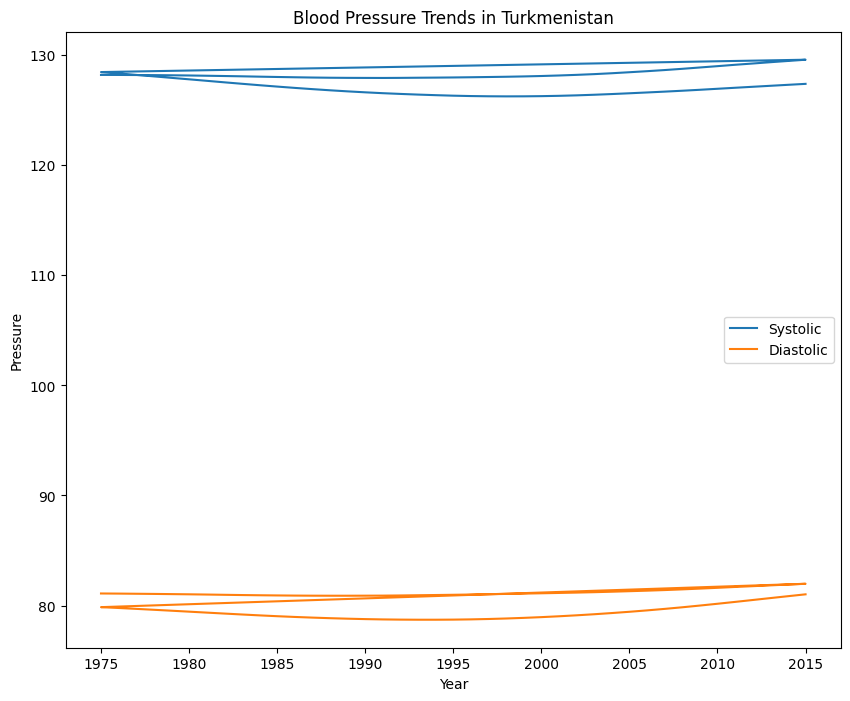

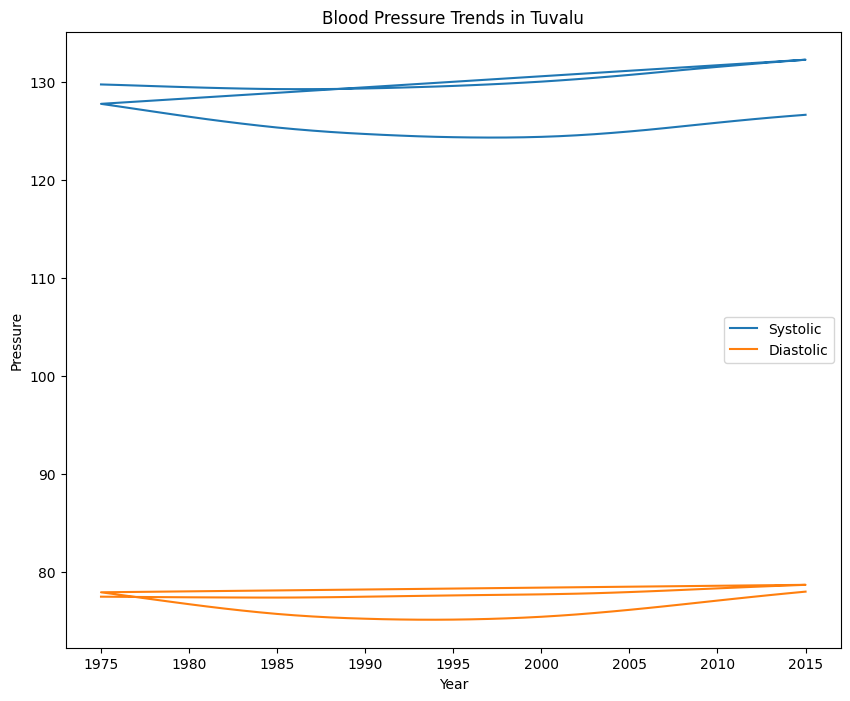

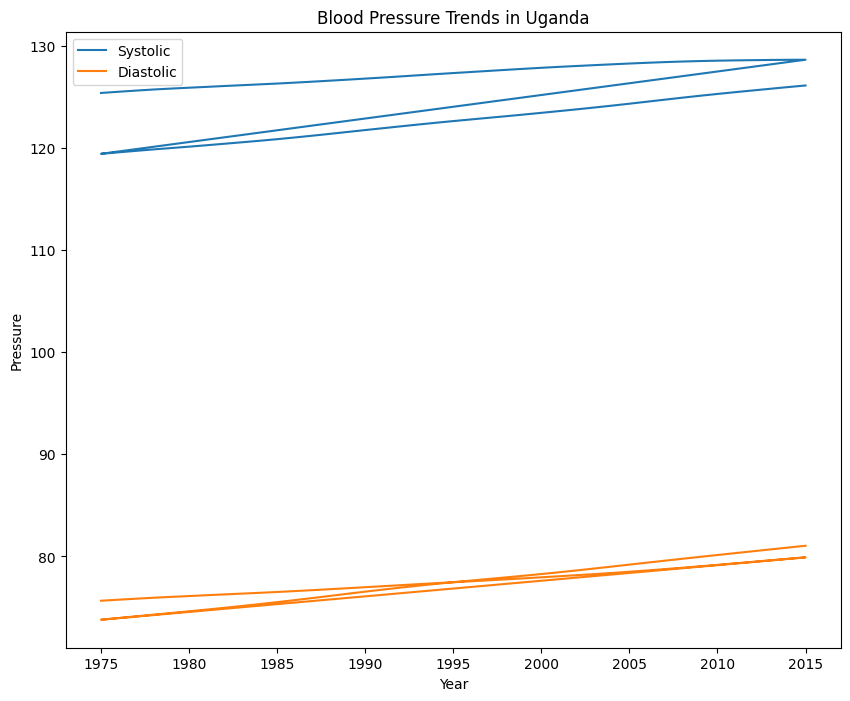

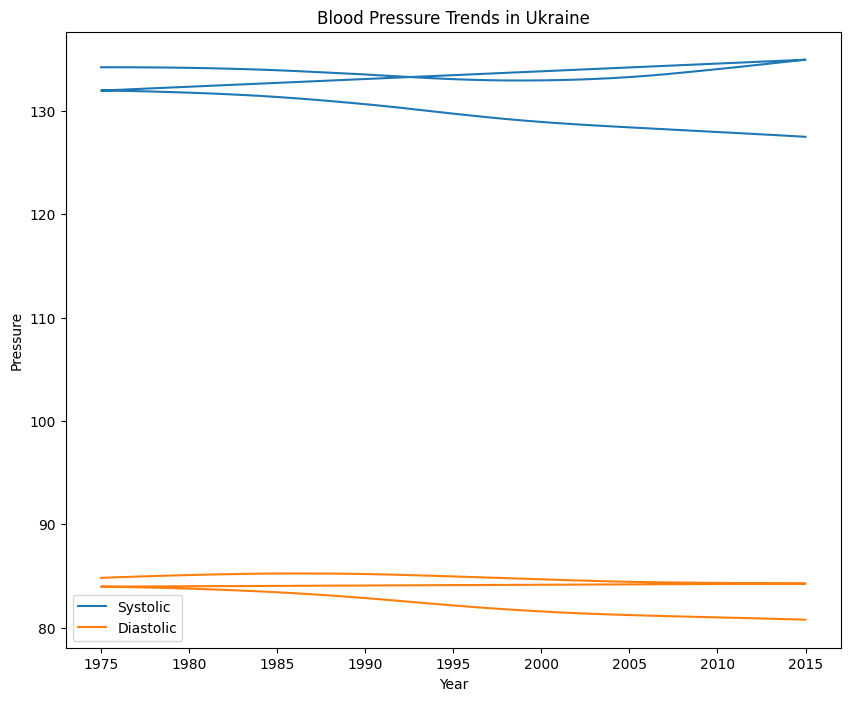

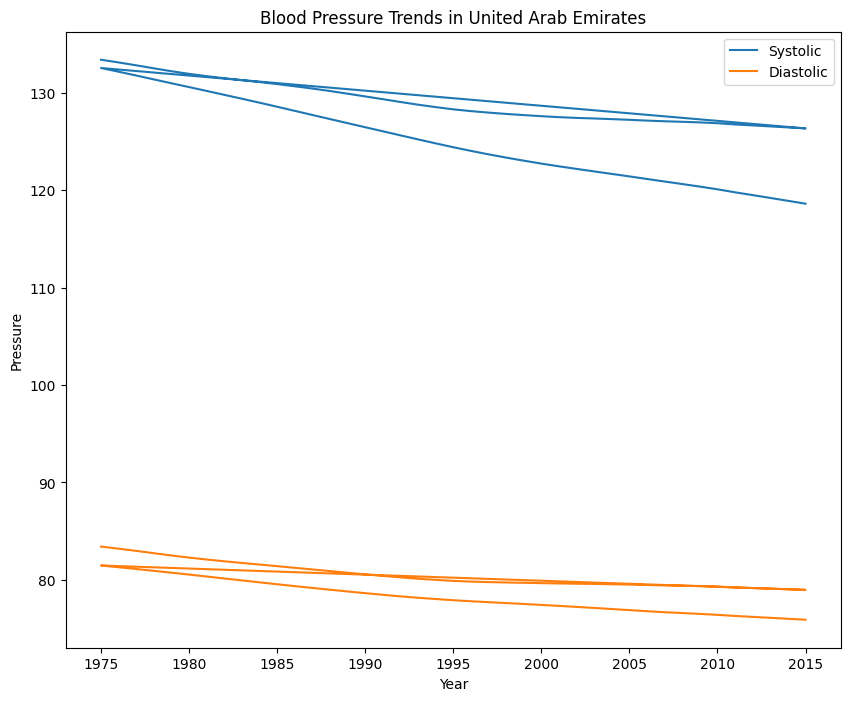

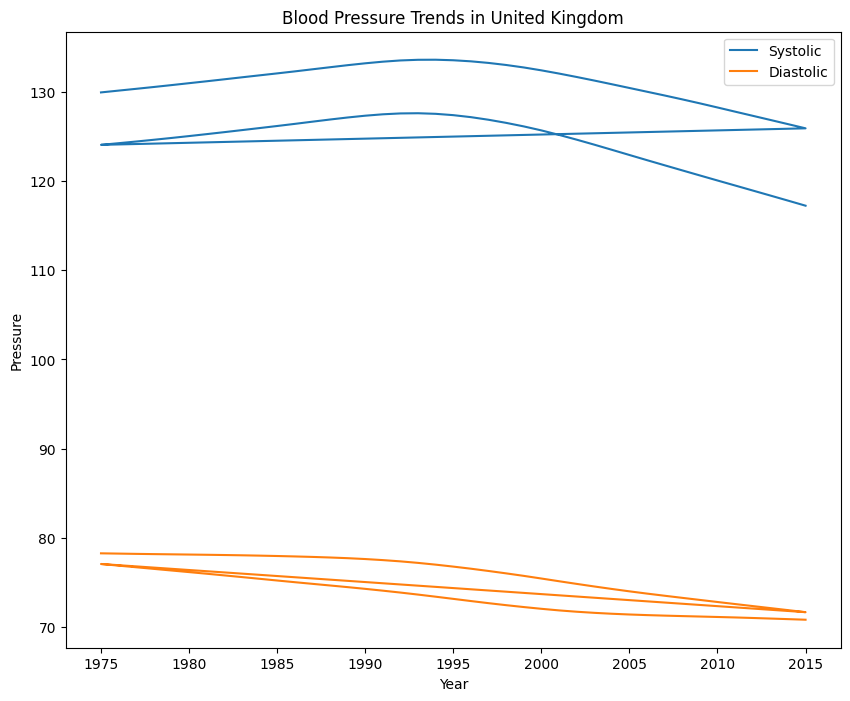

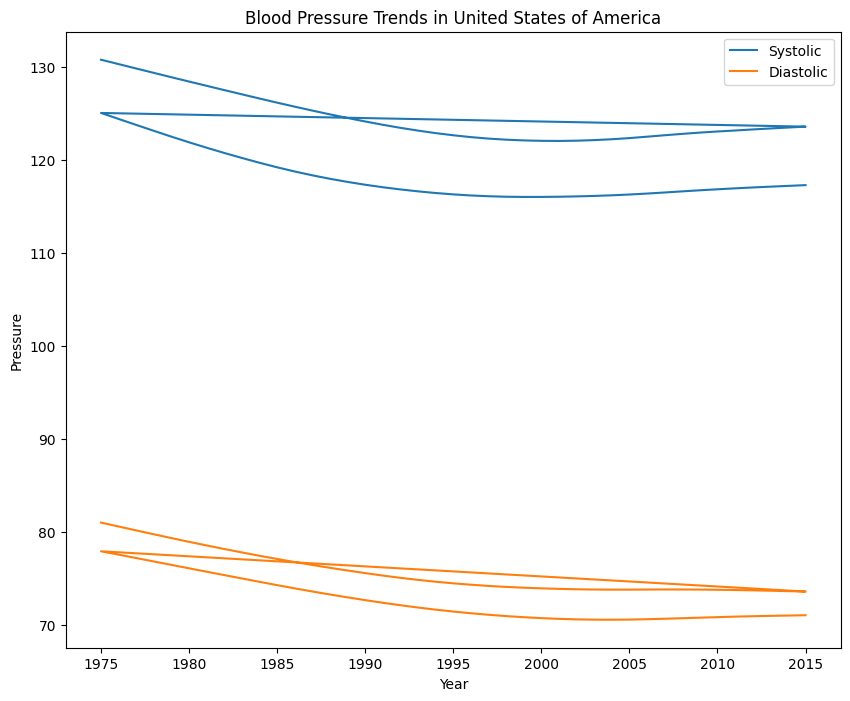

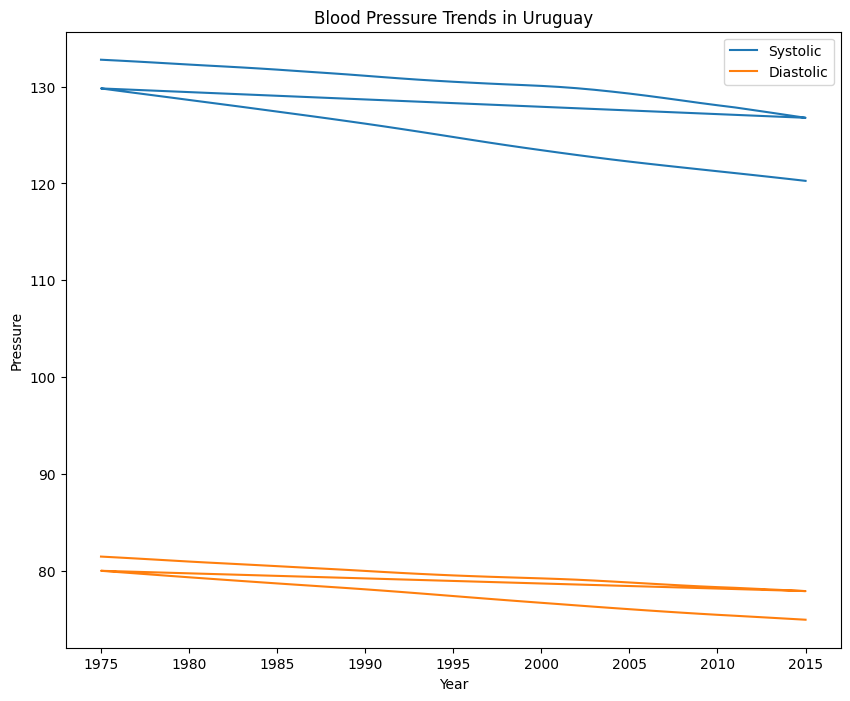

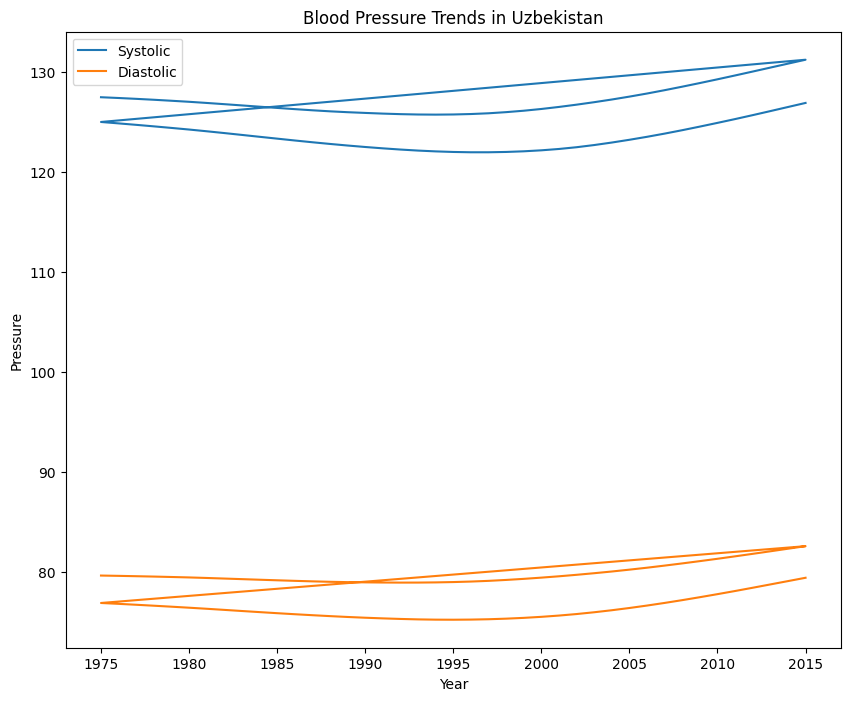

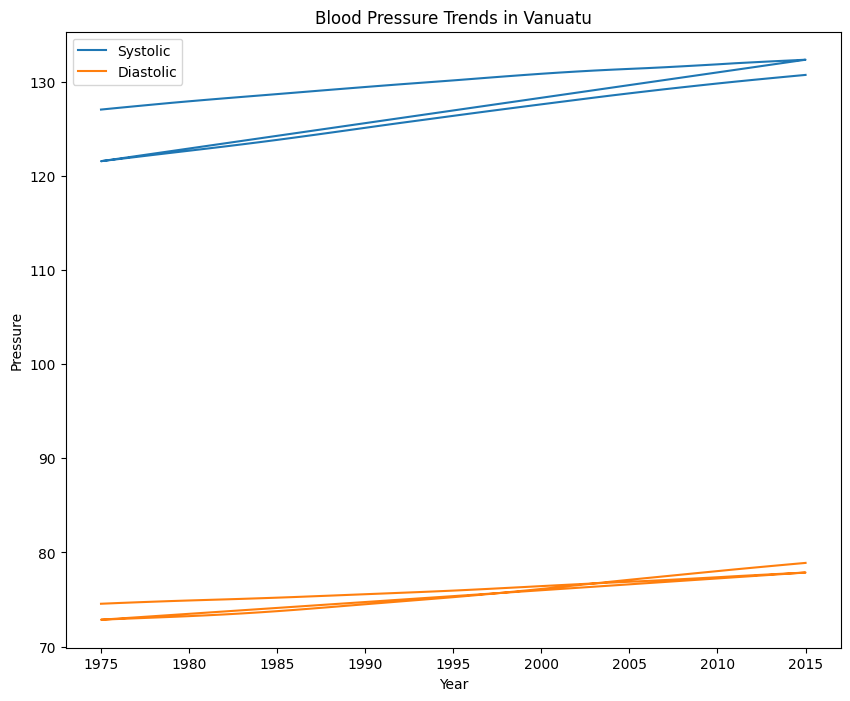

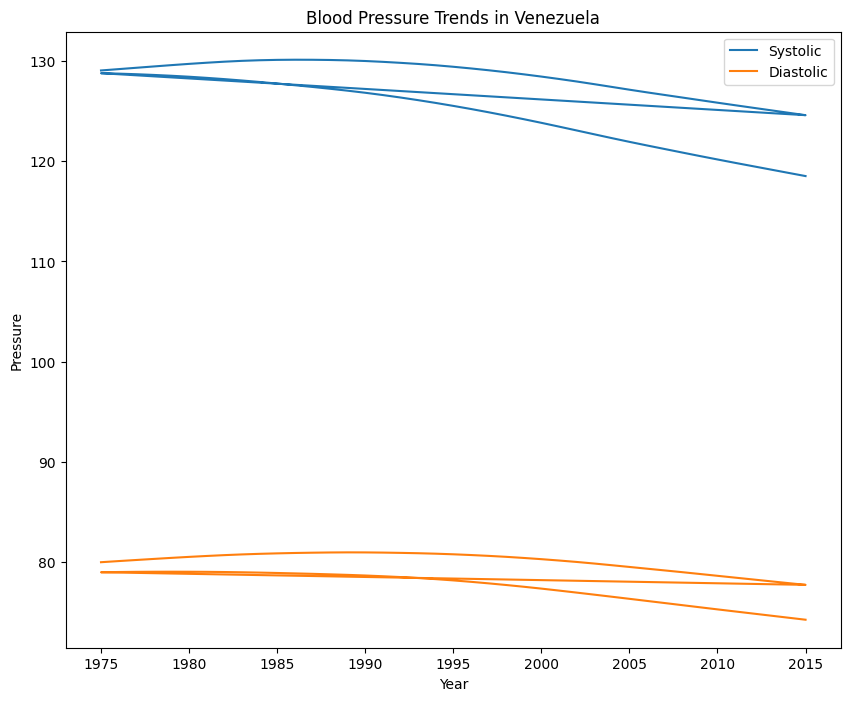

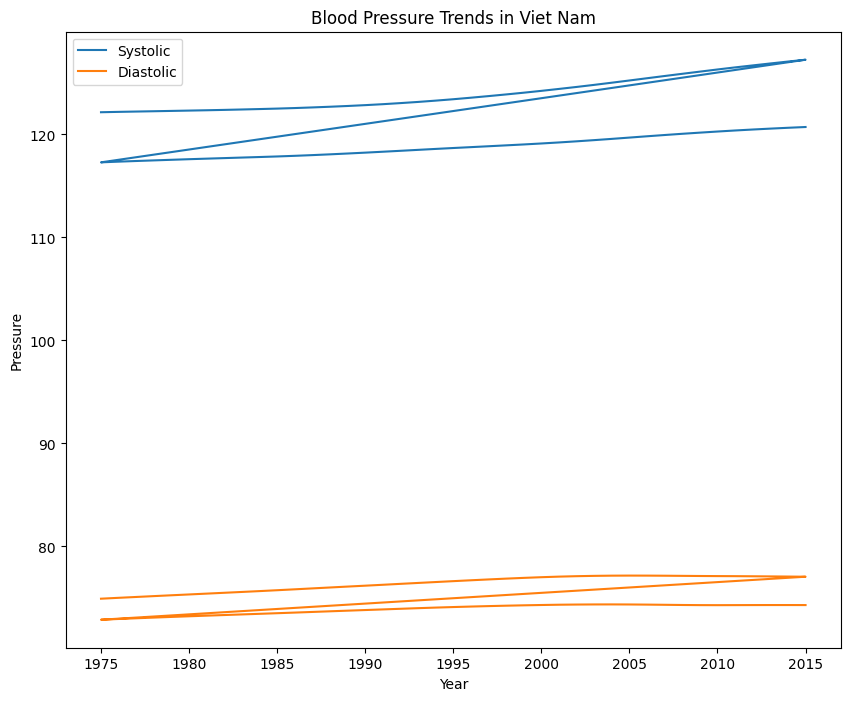

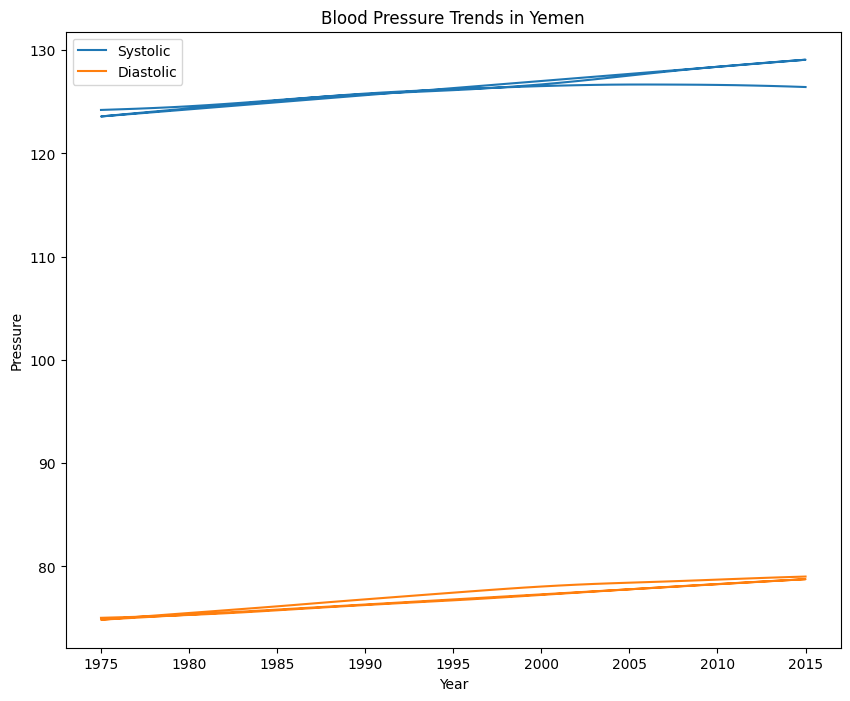

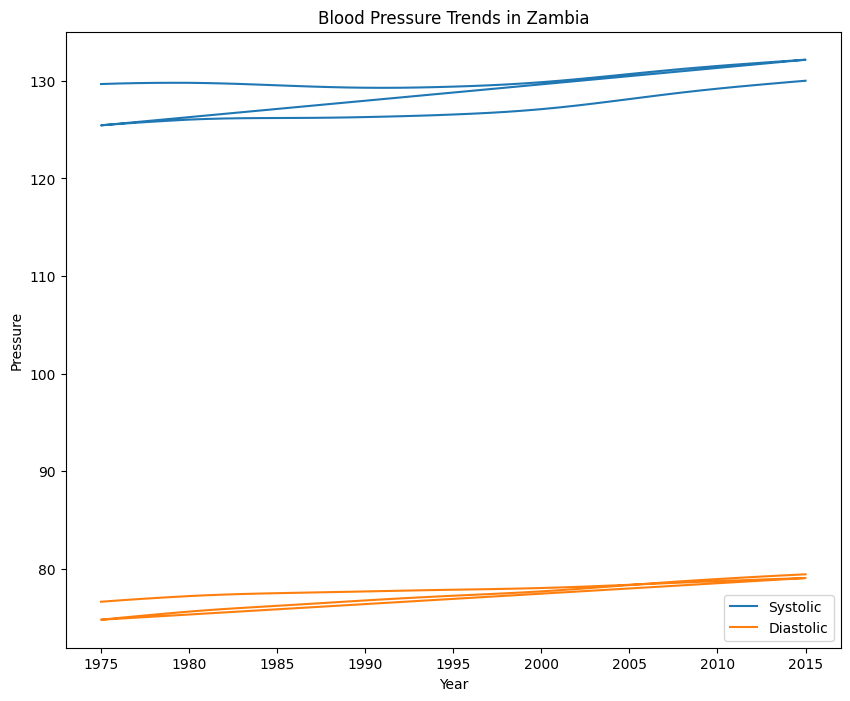

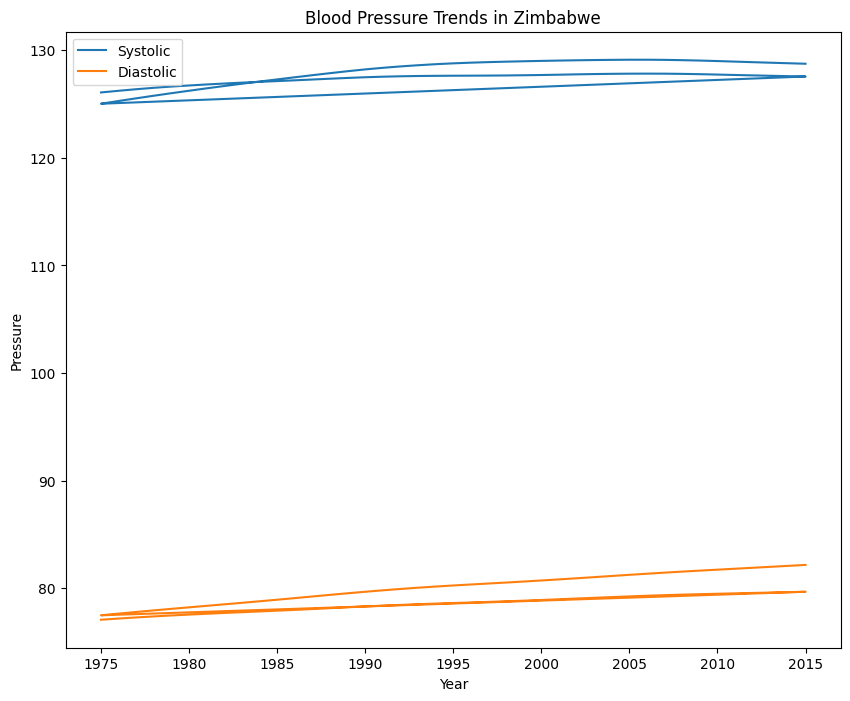

In [29]:
countries = df['Country/Region/World'].unique()

for country in countries:
    country_data = df[df['Country/Region/World'] == country]

    # Plot the systolic and diastolic averages over the years
    plt.figure(figsize=(10,8))
    plt.plot(country_data['Year'], country_data['systolic'], label='Systolic')
    plt.plot(country_data['Year'], country_data['diastolic'], label='Diastolic')

    # Add labels and title
    plt.xlabel('Year')
    plt.ylabel('Pressure')
    plt.title(f'Blood Pressure Trends in {country}')
    plt.legend()

    plt.show()